In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.svm import SVC

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix


from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

import os
from google import genai 
from google.genai import types



#Data understanding

In [5]:
df = pd.read_csv(r"data\online_shoppers_intention.csv")

print(f"Shape: {df.shape}")

Shape: (12330, 18)


In [6]:
df.shape

(12330, 18)

In [7]:
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [9]:
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

In [10]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


Understand the Target


In [11]:
print(df["Revenue"].value_counts())

Revenue
False    10422
True      1908
Name: count, dtype: int64


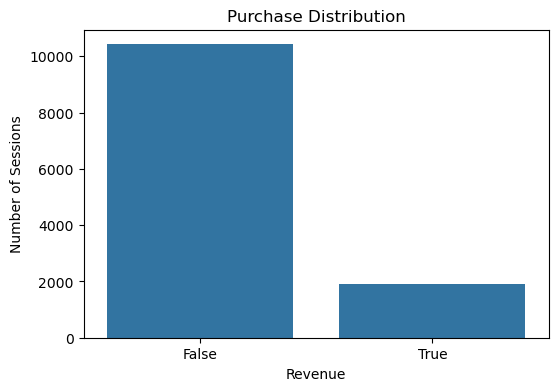

In [12]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Revenue", data=df)

plt.title("Purchase Distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of Sessions")

plt.show()

In [13]:
purchase_rate = df["Revenue"].mean() * 100

print(f"Purchase Rate: {purchase_rate:.2f}%")

Purchase Rate: 15.47%


In [14]:
missing_values = df.isnull().sum()

print(missing_values)

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [15]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [16]:
print("Number of duplicated rows:", df.duplicated().sum())

Number of duplicated rows: 125


In [17]:
df = df.drop_duplicates()

print("New Dataset Shape:", df.shape)

New Dataset Shape: (12205, 18)


In [18]:
print("Number of duplicated rows:", df.duplicated().sum())

Number of duplicated rows: 0


In [19]:
df.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

#visualization

In [20]:
print("Visitor Type:")
print(df["VisitorType"].value_counts())

Visitor Type:
VisitorType
Returning_Visitor    10431
New_Visitor           1693
Other                   81
Name: count, dtype: int64


In [21]:
print("Weekend:")
print(df["Weekend"].value_counts())

Weekend:
Weekend
False    9346
True     2859
Name: count, dtype: int64


In [22]:
print("Informational:")
print(df["Informational"].value_counts())

Informational:
Informational
0     9574
1     1041
2      728
3      380
4      222
5       99
6       78
7       36
9       15
8       14
10       7
12       5
14       2
16       1
11       1
24       1
13       1
Name: count, dtype: int64


In [23]:
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

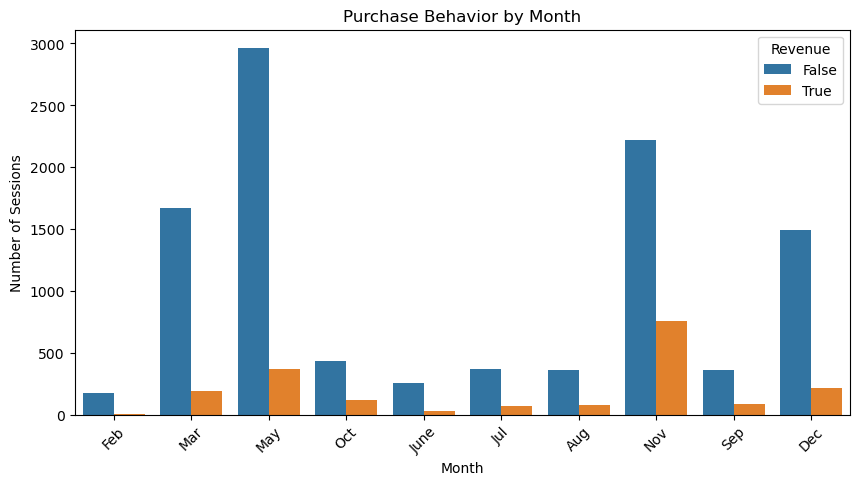

In [24]:
plt.figure(figsize=(10, 5))

sns.countplot(
    x="Month",
    hue="Revenue",
    data=df
)

plt.title("Purchase Behavior by Month")
plt.xlabel("Month")
plt.ylabel("Number of Sessions")

plt.xticks(rotation=45)

plt.show()

In [25]:
print("Month values:")
print(df["Month"].value_counts())

Month values:
Month
May     3329
Nov     2982
Mar     1860
Dec     1706
Oct      549
Sep      448
Aug      433
Jul      432
June     285
Feb      181
Name: count, dtype: int64


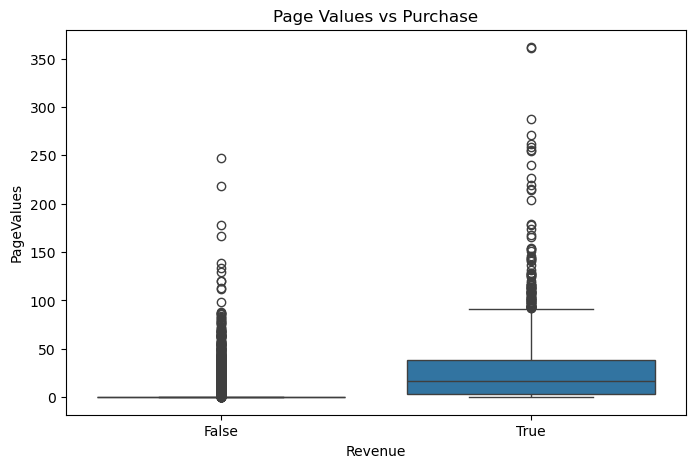

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Revenue",
    y="PageValues",
    data=df
)

plt.title("Page Values vs Purchase")

plt.show()

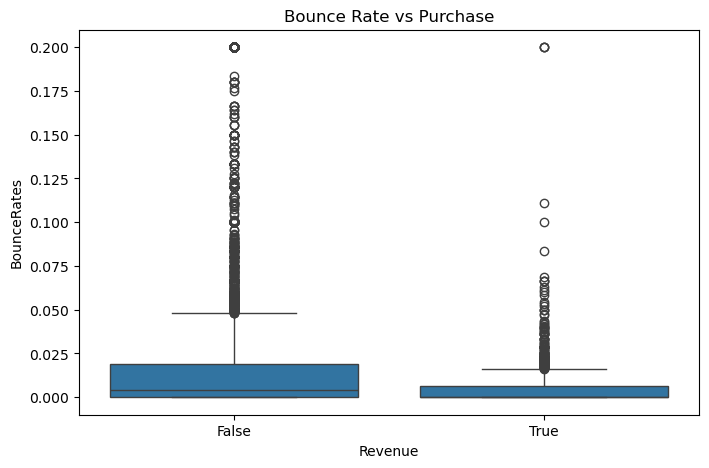

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Revenue",
    y="BounceRates",
    data=df
)

plt.title("Bounce Rate vs Purchase")

plt.show()

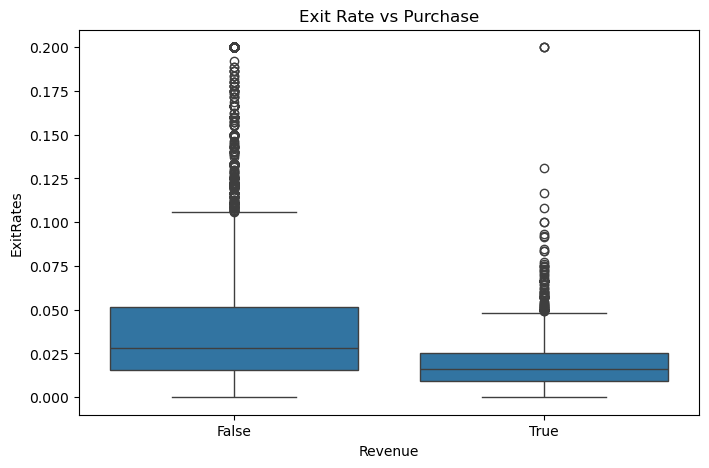

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Revenue",
    y="ExitRates",
    data=df
)

plt.title("Exit Rate vs Purchase")

plt.show()

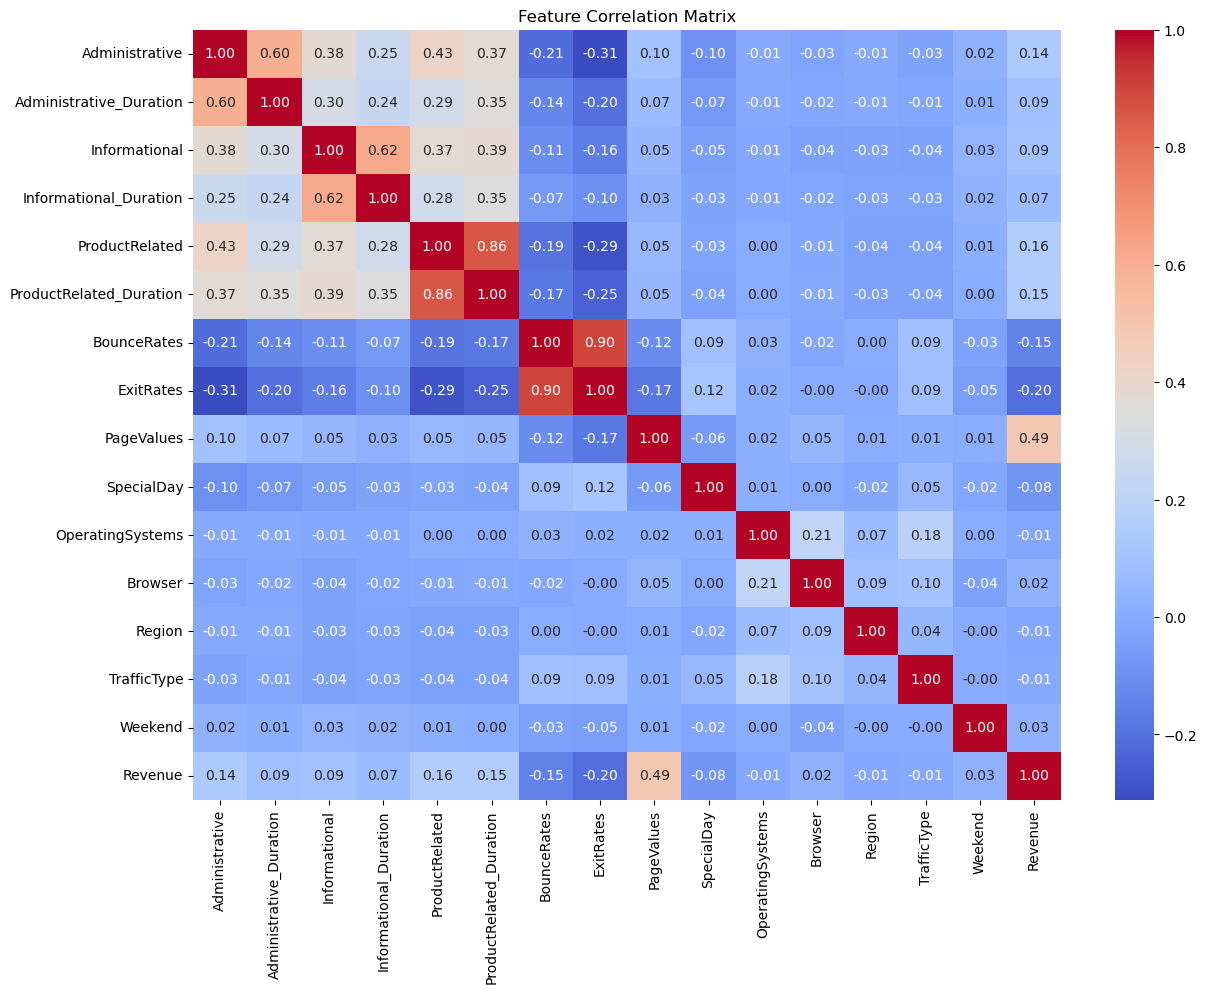

In [29]:
numeric_df = df.select_dtypes(include=["int64", "float64", "bool"])

correlation = numeric_df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.show()

###Visualization 1 — Page Activity

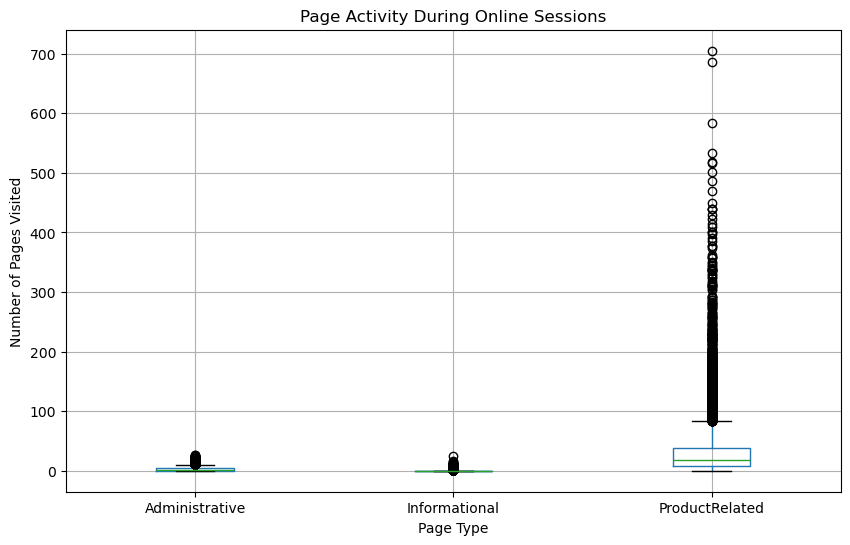

In [30]:
page_features = [
    "Administrative",
    "Informational",
    "ProductRelated"
]

plt.figure(figsize=(10, 6))

df[page_features].boxplot()

plt.title("Page Activity During Online Sessions")
plt.xlabel("Page Type")
plt.ylabel("Number of Pages Visited")

plt.show()

Insight:

Product-related pages have the highest number of visits compared with administrative and informational pages, indicating that product browsing is the main activity during online shopping sessions.

###Visualization 2 — Page Duration

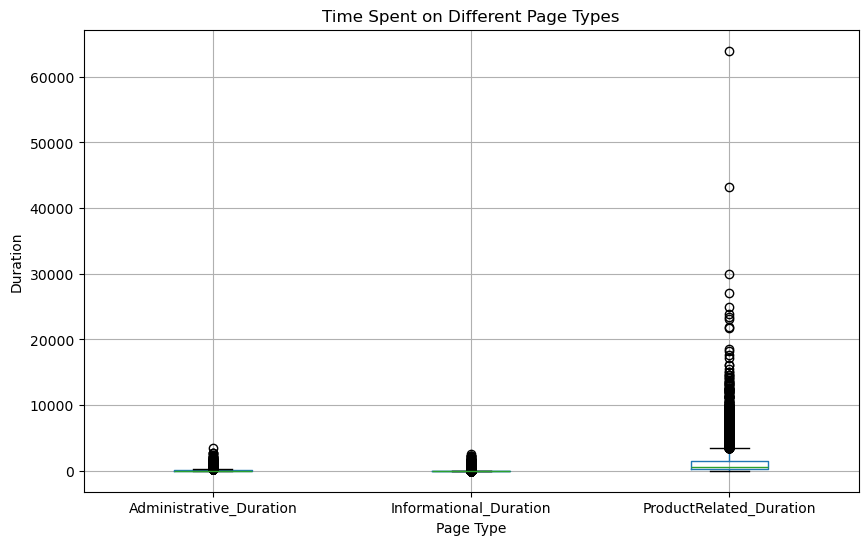

In [31]:
duration_features = [
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration"
]

plt.figure(figsize=(10, 6))

df[duration_features].boxplot()

plt.title("Time Spent on Different Page Types")
plt.xlabel("Page Type")
plt.ylabel("Duration")

plt.show()

Insight:

Visitors generally spend more time on product-related pages, suggesting that product browsing and evaluation represent a major part of the shopping journey.

###Visualization 3 — Engagement & Purchase Behavior

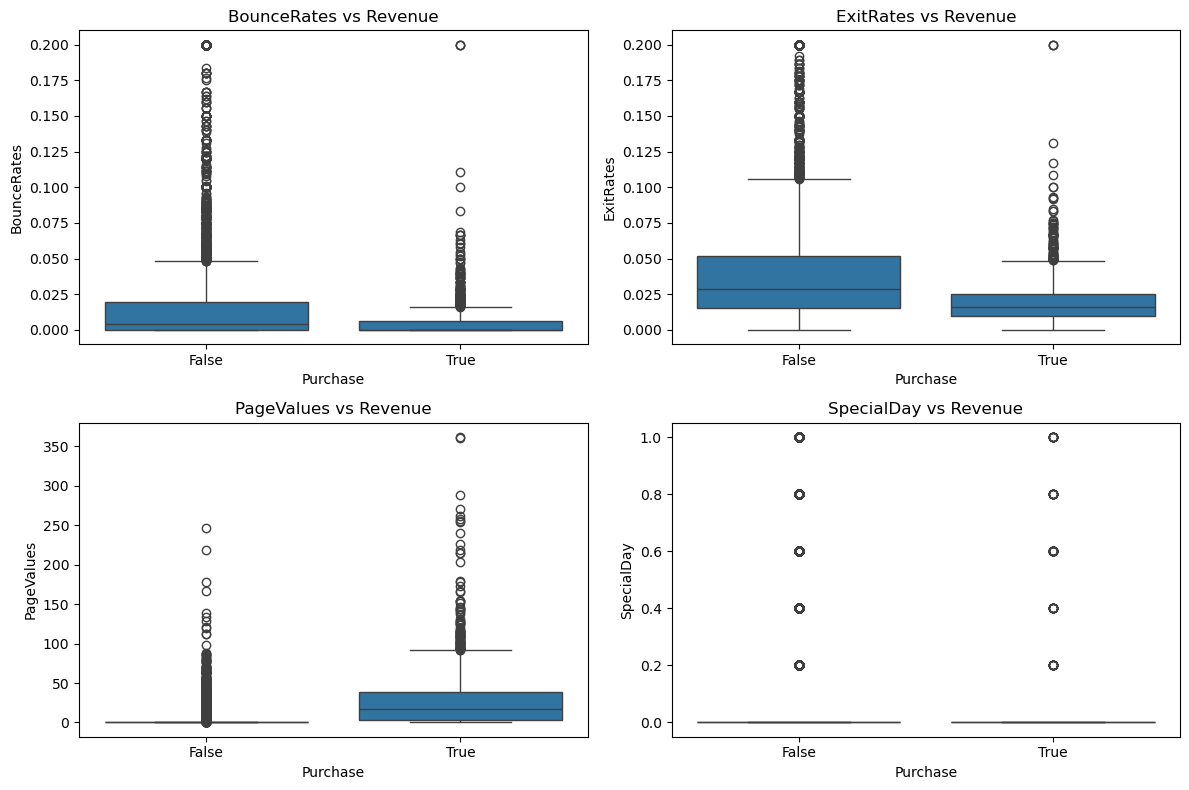

In [32]:
engagement_features = [
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flat, engagement_features):

    sns.boxplot(
        data=df,
        x="Revenue",
        y=feature,
        ax=ax
    )

    ax.set_title(f"{feature} vs Revenue")
    ax.set_xlabel("Purchase")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

Customers who make a purchase generally show lower Bounce Rates and Exit Rates, while higher Page Values are strongly associated with purchasing sessions. This suggests that engaged visitors who explore valuable pages and remain longer in the shopping journey are more likely to complete a purchase. Special Day visits may also influence purchasing behavior.

###Visualization 4 — Customer & Session Characteristics

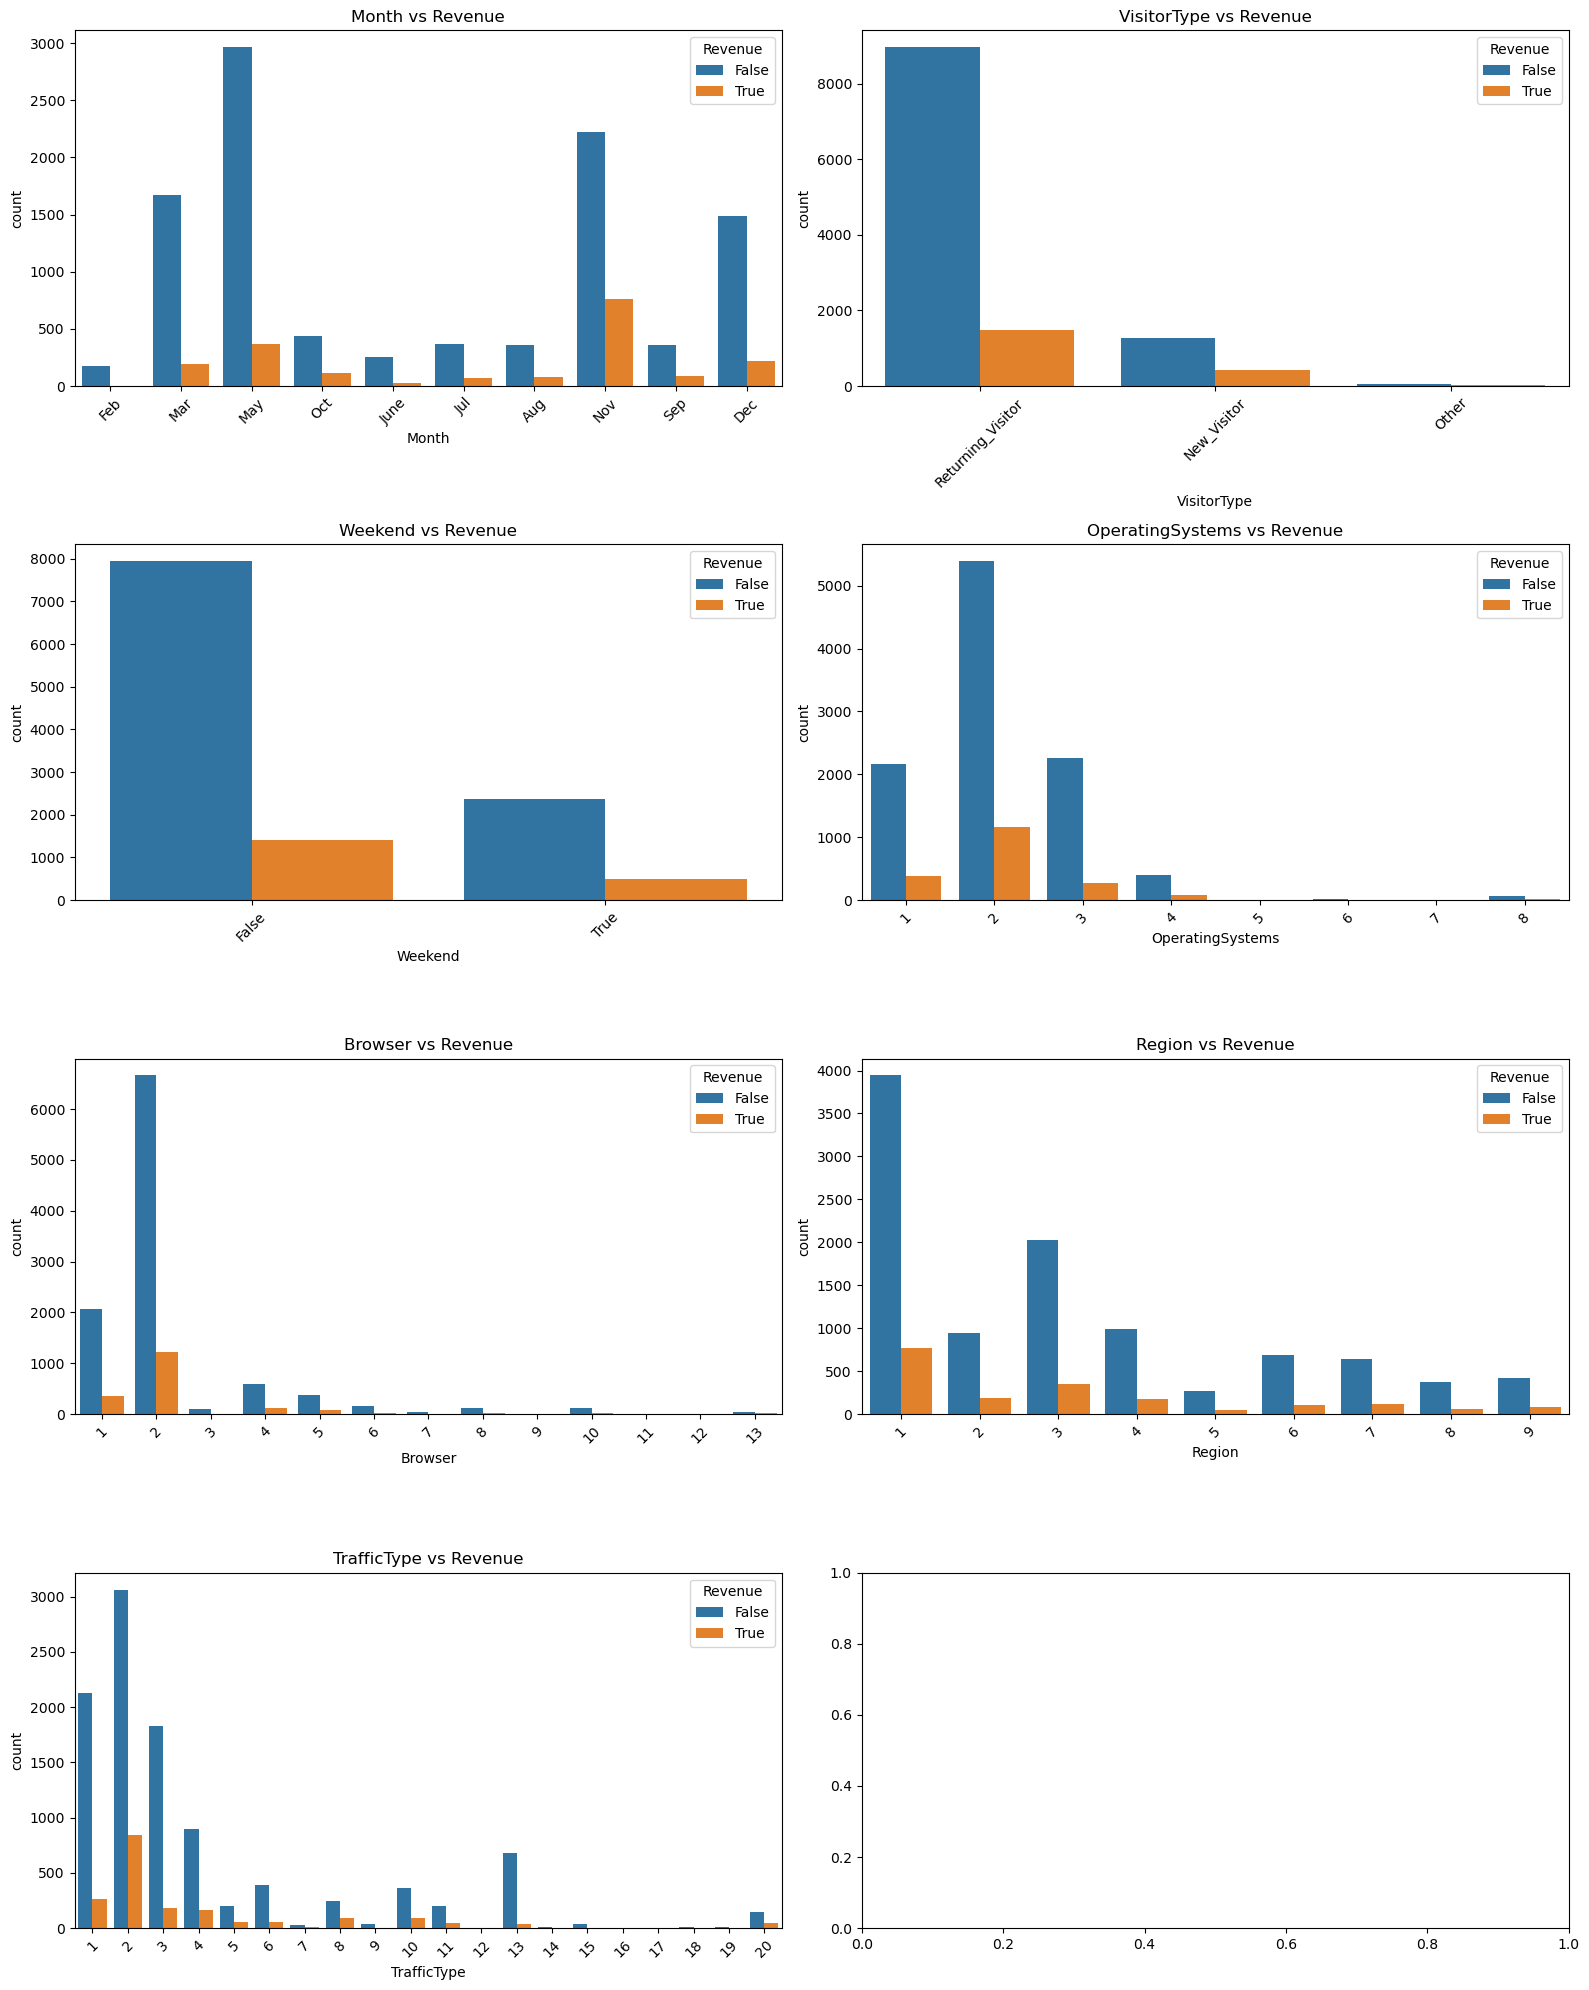

In [33]:
categorical_features = [
    "Month",
    "VisitorType",
    "Weekend",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]

fig, axes = plt.subplots(4, 2, figsize=(16, 20))

for ax, feature in zip(axes.flat, categorical_features):

    sns.countplot(
        data=df,
        x=feature,
        hue="Revenue",
        ax=ax
    )

    ax.set_title(f"{feature} vs Revenue")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Customer and session characteristics show differences in purchasing behavior across visitor types, months, traffic sources, devices, and browsing sessions. These variables can therefore provide useful information for predicting purchase intention.

# Business EDA & Analytics — Online Shoppers Purchasing Intention


**Structure of this section**
1. Business EDA Overview & Data Discovery
2. Purchase Behavior (Q1–Q10)
3. Browsing & Engagement (Q11–Q20)
4. Conversion Barriers — Bounce/Exit (Q21–Q30)
5. Administrative & Informational Behavior (Q31–Q37)
6. Customer / Visitor Segmentation (Q38–Q43)
7. Traffic & Acquisition (Q44–Q48)
8. Advanced Behavioral Analysis (Q49–Q50)
9. Executive Business Intelligence Summary


In [34]:
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titleweight'] = 'bold'

# Work on an isolated copy so the ML preprocessing pipeline further below is untouched
df_eda = df.copy()
df_eda['Revenue'] = df_eda['Revenue'].astype(bool)
df_eda['Weekend'] = df_eda['Weekend'].astype(bool)
OVERALL_RATE = df_eda['Revenue'].mean() * 100
MONTH_ORDER = ['Feb','Mar','May','June','Jul','Aug','Sep','Oct','Nov','Dec']

def conversion_table(frame, group_col, min_n=1, sort=True, order=None):
    """Sessions, Purchases and Conversion Rate (%) for each level of group_col."""
    t = frame.groupby(group_col, observed=True).agg(Sessions=('Revenue', 'size'),
                                                      Purchases=('Revenue', 'sum'))
    t['ConversionRate_%'] = (t['Purchases'] / t['Sessions'] * 100).round(2)
    t = t[t['Sessions'] >= min_n]
    if order is not None:
        t = t.reindex(order)
    elif sort:
        t = t.sort_values('ConversionRate_%', ascending=False)
    return t

def plot_conversion(table, title, xlabel, rot=0, figsize=(9, 4.5)):
    """Grouped view: session-count bars (left axis) + conversion-rate line (right axis)."""
    fig, ax1 = plt.subplots(figsize=figsize)
    x = np.arange(len(table))
    ax1.bar(x, table['Sessions'], color='#4C72B0', alpha=0.75, label='Sessions')
    ax1.set_ylabel('Sessions (count)', color='#4C72B0')
    ax1.set_xticks(x)
    ax1.set_xticklabels(table.index.astype(str), rotation=rot)
    ax1.set_xlabel(xlabel)
    ax2 = ax1.twinx()
    ax2.plot(x, table['ConversionRate_%'], color='#C44E52', marker='o', linewidth=2,
             label='Conversion Rate (%)')
    ax2.set_ylabel('Conversion Rate (%)', color='#C44E52')
    ax2.grid(False)
    ax2.axhline(OVERALL_RATE, color='gray', linestyle='--', linewidth=1,
                label=f'Overall rate ({OVERALL_RATE:.2f}%)')
    fig.suptitle(title, fontsize=13)
    l1, lab1 = ax1.get_legend_handles_labels()
    l2, lab2 = ax2.get_legend_handles_labels()
    ax1.legend(l1 + l2, lab1 + lab2, loc='upper left', fontsize=8)
    fig.tight_layout()
    plt.show()

def plot_box_by_revenue(frame, col, title, ylabel=None):
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    data = [frame.loc[~frame['Revenue'], col].dropna(),
            frame.loc[frame['Revenue'], col].dropna()]
    bp = ax.boxplot(data, tick_labels=['No Purchase', 'Purchase'], patch_artist=True, showfliers=False)
    for patch, color in zip(bp['boxes'], ['#4C72B0', '#55A868']):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel or col)
    ax.set_xlabel('Session Outcome')
    fig.tight_layout()
    plt.show()

def pct(x):
    return f"{x:.2f}%"

print("Helper functions ready:", ["conversion_table", "plot_conversion", "plot_box_by_revenue"])

Helper functions ready: ['conversion_table', 'plot_conversion', 'plot_box_by_revenue']


## 2. Purchase Behavior

## Business Question 1

### Question
What is the overall purchase conversion rate?

### Business Objective
Establish the baseline conversion rate that every other segment/behavior comparison in this analysis will be measured against.

### Data / Features Used
`Revenue` (target)

Total sessions: 12,205
Purchasing sessions: 1,908
Overall conversion rate: 15.63%


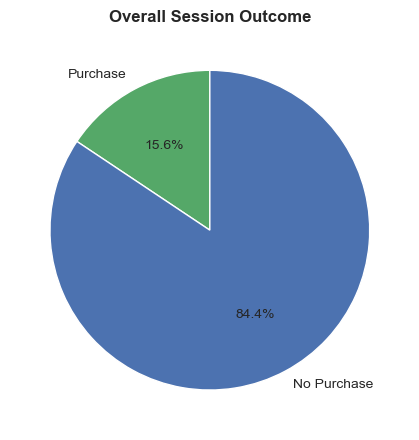

In [35]:
total_sessions = len(df_eda)
total_purchases = int(df_eda['Revenue'].sum())
overall_rate = df_eda['Revenue'].mean() * 100

print(f"Total sessions: {total_sessions:,}")
print(f"Purchasing sessions: {total_purchases:,}")
print(f"Overall conversion rate: {overall_rate:.2f}%")

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.pie([total_purchases, total_sessions - total_purchases],
       labels=['Purchase', 'No Purchase'], autopct='%1.1f%%',
       colors=['#55A868', '#4C72B0'], startangle=90)
ax.set_title('Overall Session Outcome')
plt.tight_layout(); plt.show()

### Key Results
- Total sessions analyzed: **12,205**
- Purchasing sessions: **1,908**
- Overall conversion rate: **15.63%**

### Insight
Roughly 1 in every 6.4 sessions ends in a purchase. This is the baseline that every segment, channel, and behavioral pattern in the rest of this analysis must be compared against — a segment is only "high-converting" if its rate is meaningfully above 15.63%.

### Business Recommendation
Use 15.63% as the reference conversion rate for all internal reporting and A/B testing. Any UX change, campaign, or feature should be judged relative to this baseline rather than in isolation.

## Business Question 2

### Question
How does purchase behavior differ between returning and new visitors?

### Business Objective
Determine whether acquisition (new visitors) or retention (returning visitors) is the stronger converting channel, to guide budget allocation between the two.

### Data / Features Used
`VisitorType`, `Revenue`

                   Sessions  Purchases  ConversionRate_%
VisitorType                                             
New_Visitor            1693        422             24.93
Other                    81         16             19.75
Returning_Visitor     10431       1470             14.09


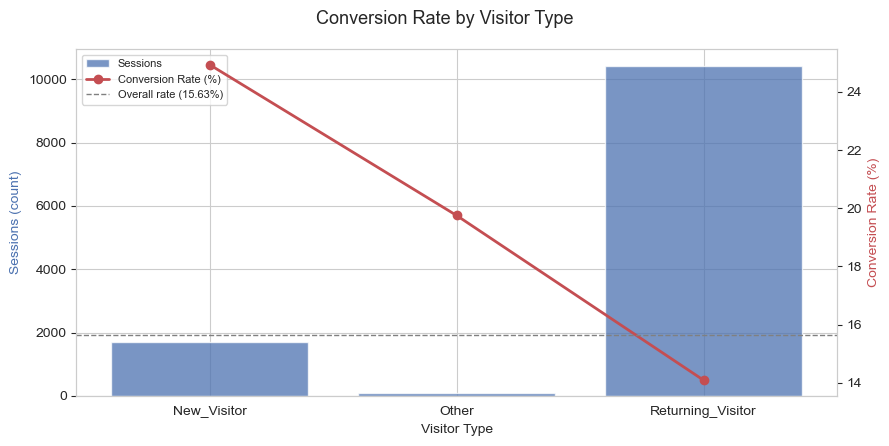

In [36]:
vt_table = conversion_table(df_eda, 'VisitorType')
print(vt_table)
plot_conversion(vt_table, 'Conversion Rate by Visitor Type', 'Visitor Type')

### Key Results
| VisitorType | Sessions | Purchases | Conversion Rate |
|---|---|---|---|
| New_Visitor | 1,693 | 422 | **24.93%** |
| Other | 81 | 16 | 19.75% |
| Returning_Visitor | 10,431 | 1,470 | **14.09%** |

### Insight
New visitors convert at nearly **1.8x** the rate of returning visitors (24.93% vs 14.09%), even though returning visitors make up 85% of all traffic. Returning visitors browse far more (see Q43) but convert less often per session — consistent with window-shopping / repeat research visits rather than immediate purchase intent.

### Business Recommendation
Do not assume returning traffic is automatically higher-value on a per-session basis. Prioritize high-intent signals (e.g. PageValues) for returning visitors specifically, and protect the New_Visitor funnel (first-visit landing pages, PDP clarity) since it is already the strongest per-session converter.

## Business Question 3

### Question
Which months have the highest and lowest purchase conversion rates?

### Business Objective
Identify seasonal peaks and troughs in conversion to plan promotions, inventory, and staffing.

### Data / Features Used
`Month`, `Revenue`

       Sessions  Purchases  ConversionRate_%
Month                                       
Feb         181          3              1.66
Mar        1860        192             10.32
May        3329        365             10.96
June        285         29             10.18
Jul         432         66             15.28
Aug         433         76             17.55
Sep         448         86             19.20
Oct         549        115             20.95
Nov        2982        760             25.49
Dec        1706        216             12.66


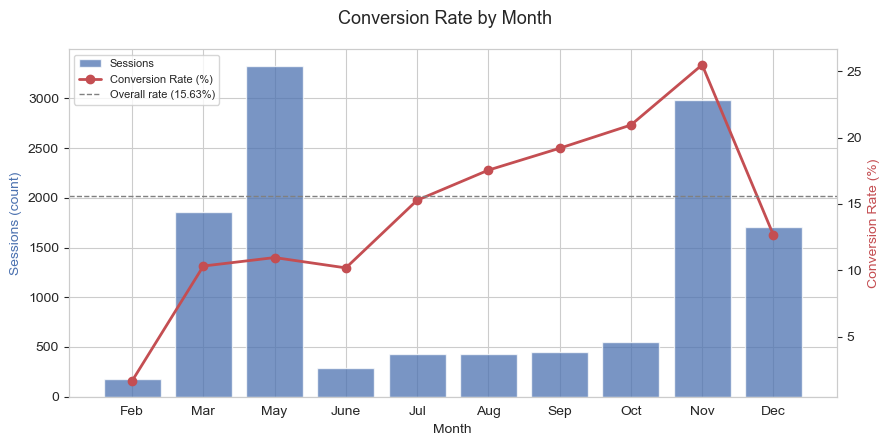

In [37]:
month_table = conversion_table(df_eda, 'Month', order=MONTH_ORDER)
print(month_table)
plot_conversion(month_table, 'Conversion Rate by Month', 'Month')

### Key Results
- Highest: **Nov (25.49%, n=2,982)**, then Oct (20.95%, n=549)
- Lowest: **Feb (1.66%, n=181)**, then June (10.18%, n=285) and May (10.96%, n=3,329)

### Insight
November stands out both in volume (2,982 sessions, the 2nd-highest month) and conversion (25.49%), clearly reflecting Black-Friday/Cyber-Monday-driven intent. February is a near-dead month for conversion despite reasonable traffic (181 sessions, only 1.66% convert) — visitors in Feb are likely early researchers rather than buyers.

### Business Recommendation
Concentrate promotional spend and inventory in November, and treat high-traffic but low-conversion months (May) as an opportunity to test onsite incentives (limited-time offers, retargeting) rather than assume the traffic itself is low quality.

## Business Question 4

### Question
Does weekend browsing lead to higher purchase conversion?

### Business Objective
Test whether weekend sessions justify weekend-specific promotions or staffing for support/fulfilment.

### Data / Features Used
`Weekend`, `Revenue`

         Sessions  Purchases  ConversionRate_%
Weekend                                       
True         2859        499             17.45
False        9346       1409             15.08


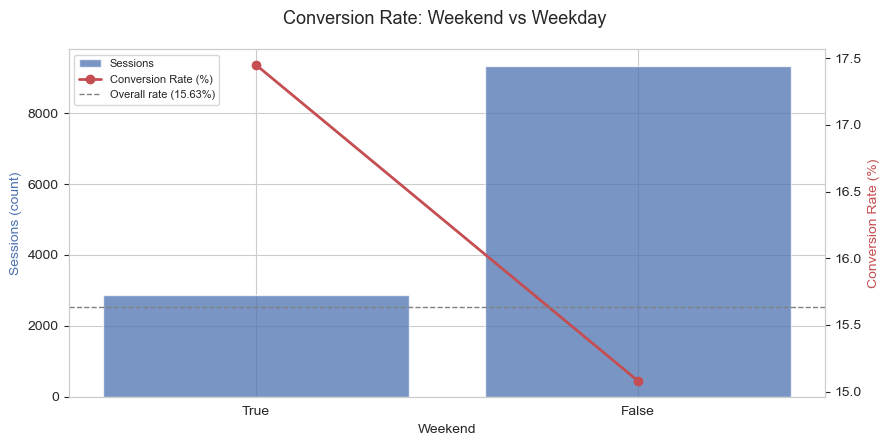

In [38]:
weekend_table = conversion_table(df_eda, 'Weekend')
print(weekend_table)
plot_conversion(weekend_table, 'Conversion Rate: Weekend vs Weekday', 'Weekend')

### Key Results
| Weekend | Sessions | Purchases | Conversion Rate |
|---|---|---|---|
| True | 2,859 | 499 | **17.45%** |
| False | 9,346 | 1,409 | 15.08% |

### Insight
Weekend sessions convert modestly better than weekday sessions (17.45% vs 15.08%, a +2.37pp / ~16% relative lift), but weekday sessions still supply the large majority (76.6%) of total purchases simply due to volume.

### Business Recommendation
A small weekend conversion advantage exists but is not large enough to justify reallocating most marketing spend to weekends. It does support running weekend-specific promotions as a conversion booster rather than a volume driver, while weekday traffic remains the primary revenue engine.

## Business Question 5

### Question
How does purchase conversion vary by traffic type?

### Business Objective
Identify which traffic-acquisition channels (TrafficType codes) deliver the most efficient, purchase-ready visitors, to guide paid/organic channel investment.

### Data / Features Used
`TrafficType`, `Revenue`

             Sessions  Purchases  ConversionRate_%
TrafficType                                       
7                  40         12             30.00
8                 343         95             27.70
20                193         50             25.91
2                3911        847             21.66
5                 260         56             21.54
10                450         90             20.00
11                247         47             19.03
4                1066        165             15.48
6                 443         53             11.96
1                2388        262             10.97
9                  41          4              9.76
3                2013        180              8.94
13                728         43              5.91
15                 37          0              0.00


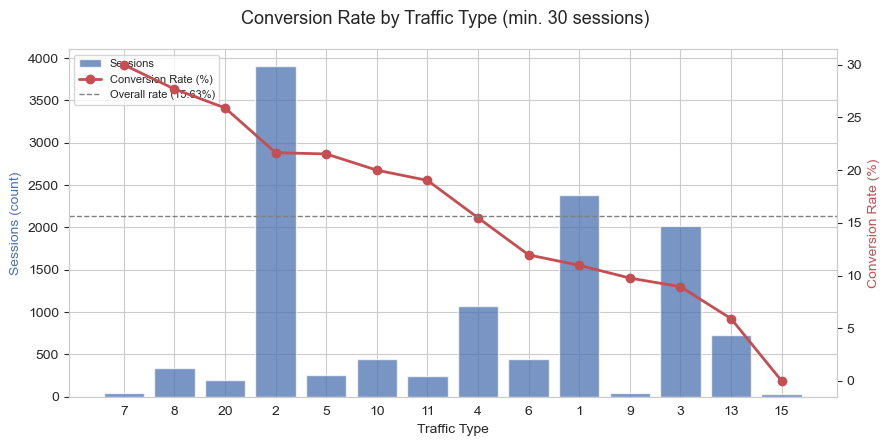

In [39]:
traffic_table = conversion_table(df_eda, 'TrafficType', min_n=30)
print(traffic_table)
plot_conversion(traffic_table, 'Conversion Rate by Traffic Type (min. 30 sessions)', 'Traffic Type')

### Key Results
Among traffic types with at least 30 sessions:
- Highest conversion: **Type 7 (30.00%, n=40)**, Type 8 (27.70%, n=343), Type 20 (25.91%, n=193)
- Highest volume: **Type 2 (3,911 sessions, 21.66% conversion)**
- Lowest conversion: Type 13 (5.91%, n=728), Type 3 (8.94%, n=2,013), Type 1 (10.97%, n=2,388)

### Insight
Type 2 is both the largest channel by volume and a well above-average converter (21.66% vs 15.63% baseline), making it the single most valuable traffic source overall. Types 7, 8 and 20 convert best on a rate basis but at far lower volume, while Types 1, 3 and 13 bring substantial traffic (over 2,000 sessions each) at below-average conversion.

### Business Recommendation
Protect and scale Type 2 as the core acquisition channel. Investigate Types 1, 3 and 13 for quality issues (irrelevant targeting, bot-like behavior, weak landing-page match) since they consume significant traffic volume with below-average returns.

## Business Question 6

### Question
How does purchase conversion vary by visitor type across months?

### Business Objective
Understand whether the New vs Returning conversion gap (Q2) is stable across the year or concentrated in specific months, to time acquisition campaigns.

### Data / Features Used
`Month`, `VisitorType`, `Revenue`

                         Sessions  Purchases  ConversionRate_%
Month VisitorType                                             
Nov   New_Visitor             419        128             30.55
Aug   New_Visitor              72         21             29.17
May   New_Visitor             319         88             27.59
Sep   New_Visitor             108         28             25.93
Nov   Returning_Visitor      2541        629             24.75
June  New_Visitor              30          7             23.33
Oct   New_Visitor             124         28             22.58
Dec   New_Visitor             334         75             22.46
      Other                    58         13             22.41
Oct   Returning_Visitor       425         87             20.47


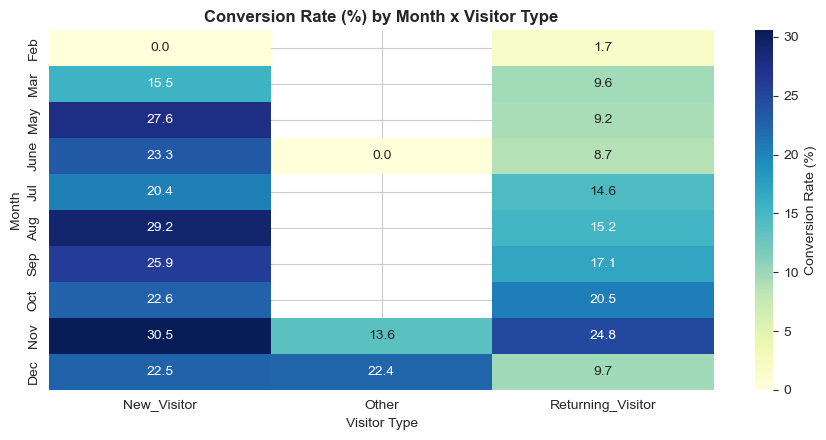

In [40]:
vt_month = df_eda.groupby(['Month', 'VisitorType'], observed=True).agg(
    Sessions=('Revenue', 'size'), Purchases=('Revenue', 'sum'))
vt_month['ConversionRate_%'] = (vt_month['Purchases'] / vt_month['Sessions'] * 100).round(2)
print(vt_month.sort_values('ConversionRate_%', ascending=False).head(10))

pivot = df_eda.pivot_table(index='Month', columns='VisitorType', values='Revenue',
                            aggfunc='mean', observed=True).reindex(MONTH_ORDER) * 100
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': 'Conversion Rate (%)'}, ax=ax)
ax.set_title('Conversion Rate (%) by Month x Visitor Type')
ax.set_xlabel('Visitor Type'); ax.set_ylabel('Month')
plt.tight_layout(); plt.show()

### Key Results
Top combinations: **New_Visitor / Nov = 30.55%** (n=419), New_Visitor/Aug = 29.17% (n=72), New_Visitor/May = 27.59% (n=319). New visitors out-convert returning visitors in almost every month; the gap narrows most in Nov (30.55% vs 24.75% for returning) and Dec.

### Insight
The New-over-Returning conversion advantage documented in Q2 is not a one-off artifact of a single month — it holds consistently across nearly all months, and both visitor types get a seasonal lift in November.

### Business Recommendation
Run new-visitor acquisition campaigns year-round rather than only seasonally, since the New Visitor conversion advantage is structural, not a monthly fluke. Layer extra November-specific acquisition spend on top given the seasonal lift for both groups.

## Business Question 7

### Question
Which combinations of VisitorType and Weekend produce the highest conversion rate?

### Business Objective
Find the single best-converting audience x timing combination to prioritize in campaign scheduling.

### Data / Features Used
`VisitorType`, `Weekend`, `Revenue`

                           Sessions  Purchases  ConversionRate_%
VisitorType       Weekend                                       
New_Visitor       False        1214        317             26.11
                  True          479        105             21.92
Other             False          74         15             20.27
Returning_Visitor True         2373        393             16.56
Other             True            7          1             14.29
Returning_Visitor False        8058       1077             13.37


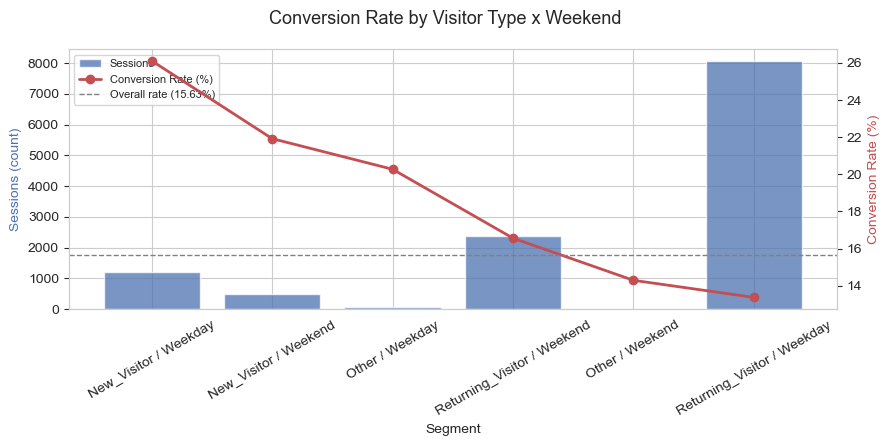

In [41]:
vw_table = df_eda.groupby(['VisitorType', 'Weekend'], observed=True).agg(
    Sessions=('Revenue', 'size'), Purchases=('Revenue', 'sum'))
vw_table['ConversionRate_%'] = (vw_table['Purchases'] / vw_table['Sessions'] * 100).round(2)
vw_table = vw_table.sort_values('ConversionRate_%', ascending=False)
print(vw_table)

plot_df = vw_table.reset_index()
plot_df['Label'] = plot_df['VisitorType'] + ' / ' + np.where(plot_df['Weekend'], 'Weekend', 'Weekday')
plot_table = plot_df.set_index('Label')[['Sessions', 'Purchases', 'ConversionRate_%']]
plot_conversion(plot_table, 'Conversion Rate by Visitor Type x Weekend', 'Segment', rot=30)

### Key Results
| Segment | Sessions | Conversion Rate |
|---|---|---|
| New_Visitor / Weekday | 1,214 | **26.11%** |
| New_Visitor / Weekend | 479 | 21.92% |
| Other / Weekday | 74 | 20.27% |
| Returning_Visitor / Weekend | 2,373 | 16.56% |
| Returning_Visitor / Weekday | 8,058 | 13.37% (lowest) |

### Insight
The best-converting combination is New_Visitor sessions on **weekdays** (26.11%), not weekends — the opposite of the naive assumption that weekends drive the best combination. Interestingly, the weekend lift found in Q4 is driven almost entirely by Returning_Visitor sessions (13.37% → 16.56%), while New_Visitor conversion is actually slightly *lower* on weekends.

### Business Recommendation
Because a simple Weekend main-effect (Q4) masks opposite patterns by visitor type, target weekday campaigns at new-visitor acquisition and reserve weekend promotions for re-engaging returning visitors, rather than applying one weekend strategy to all traffic.

## Business Question 8

### Question
What percentage of sessions with high PageValues result in a purchase?

### Business Objective
Quantify how strong a signal PageValues is (pages associated with completed transactions), to justify using it as a real-time "purchase likely" trigger (e.g. live chat, exit-intent offer).

### Data / Features Used
`PageValues`, `Revenue`

90th-percentile PageValues threshold: 19.11
High-PageValues sessions: 1,221 (10.0% of all sessions)
Conversion rate within this group: 72.15%
Conversion rate for everyone else: 9.35%


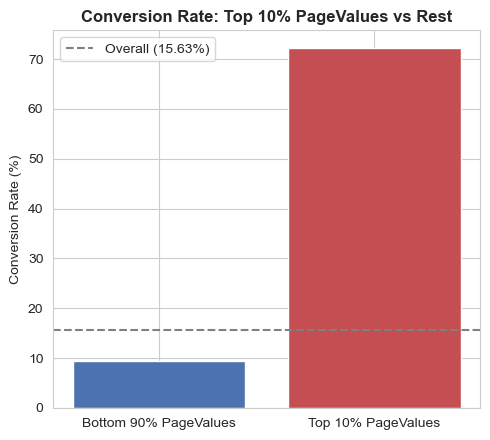

In [42]:
pv_threshold = df_eda['PageValues'].quantile(0.90)
high_pv = df_eda[df_eda['PageValues'] > pv_threshold]
print(f"90th-percentile PageValues threshold: {pv_threshold:.2f}")
print(f"High-PageValues sessions: {len(high_pv):,} ({len(high_pv)/len(df_eda)*100:.1f}% of all sessions)")
print(f"Conversion rate within this group: {high_pv['Revenue'].mean()*100:.2f}%")
print(f"Conversion rate for everyone else: {df_eda[df_eda['PageValues']<=pv_threshold]['Revenue'].mean()*100:.2f}%")

fig, ax = plt.subplots(figsize=(5, 4.5))
rates = [df_eda[df_eda['PageValues'] <= pv_threshold]['Revenue'].mean()*100, high_pv['Revenue'].mean()*100]
ax.bar(['Bottom 90% PageValues', 'Top 10% PageValues'], rates, color=['#4C72B0', '#C44E52'])
ax.axhline(OVERALL_RATE, color='gray', linestyle='--', label=f'Overall ({OVERALL_RATE:.2f}%)')
ax.set_ylabel('Conversion Rate (%)'); ax.set_title('Conversion Rate: Top 10% PageValues vs Rest')
ax.legend(); plt.tight_layout(); plt.show()

### Key Results
- 90th-percentile PageValues threshold: **19.11**
- Sessions above it: **1,221 (10.0% of all sessions)**
- Conversion rate in this group: **72.15%**, vs 9.85% for the remaining 90% of sessions

### Insight
The top decile of PageValues sessions convert at roughly **7.3x** the overall baseline (72.15% vs 15.63%). PageValues is by far the single strongest real-time purchase-intent signal available in this dataset.

### Business Recommendation
Wire PageValues into real-time decisioning: sessions crossing a high-PageValues threshold should trigger high-intent tactics (proactive live chat, free-shipping nudge, cart-abandonment safeguards) since roughly 7 in 10 of them are already on a path to purchase.

## Business Question 9

### Question
How does purchase conversion change across PageValues ranges?

### Business Objective
Map the full conversion curve across PageValues bands (not just top decile) to set graduated triggers/thresholds for marketing automation.

### Data / Features Used
`PageValues`, `Revenue`

        Sessions  Purchases  ConversionRate_%
PV_bin                                       
0           9475        370              3.91
0-5          458        162             35.37
5-10         470        194             41.28
10-20        632        333             52.69
20-50        762        518             67.98
50+          408        331             81.13


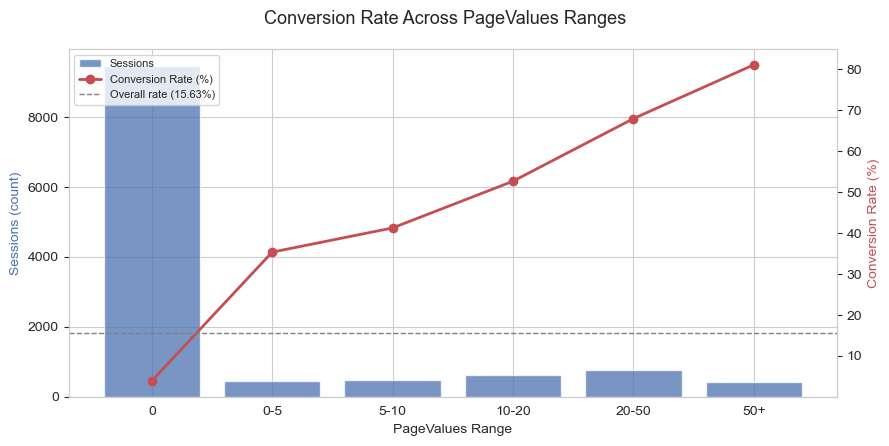

In [43]:
bins = [-0.01, 0, 5, 10, 20, 50, df_eda['PageValues'].max() + 1]
labels = ['0', '0-5', '5-10', '10-20', '20-50', '50+']
df_eda['PV_bin'] = pd.cut(df_eda['PageValues'], bins=bins, labels=labels)
pv_table = conversion_table(df_eda, 'PV_bin', sort=False)
print(pv_table)
plot_conversion(pv_table, 'Conversion Rate Across PageValues Ranges', 'PageValues Range')

### Key Results
| PageValues Range | Sessions | Conversion Rate |
|---|---|---|
| 0 | 9,475 | 3.91% |
| 0–5 | 458 | 35.37% |
| 5–10 | 470 | 41.28% |
| 10–20 | 632 | 52.69% |
| 20–50 | 762 | 67.98% |
| 50+ | 408 | **81.13%** |

### Insight
Conversion rises almost monotonically and steeply with PageValues: from 3.91% at PageValues=0 (77.6% of all sessions) to 81.13% once PageValues exceeds 50. There is no plateau — every additional band delivers a materially higher conversion rate, confirming PageValues behaves as a near-linear intent scale rather than a simple threshold.

### Business Recommendation
Build a graduated (not binary) intent score from PageValues for lifecycle marketing: PageValues=0 sessions need nurturing content, 5–20 sessions merit a mid-funnel nudge (reviews, comparison info), and 20+ sessions are ready for a closing offer (checkout assistance, urgency messaging).

## Business Question 10

### Question
What percentage of highly engaged sessions actually convert?

### Business Objective
Test whether raw engagement (many product pages + long duration) alone is enough to predict purchase, or whether it needs to be paired with intent signals like PageValues.

### Data / Features Used
`ProductRelated`, `ProductRelated_Duration`, `Revenue`

Highly engaged sessions (top quartile pages AND top quartile duration): 2,263
Conversion rate within this group: 25.41%
Overall conversion rate: 15.63%


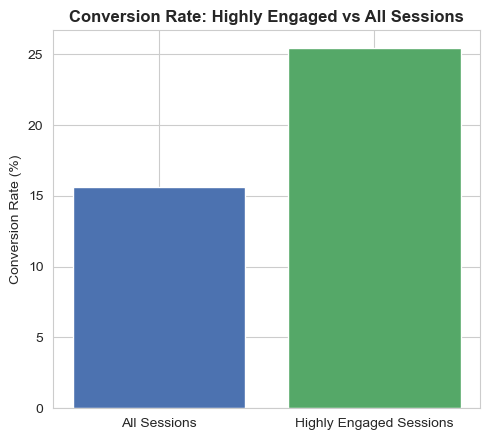

In [44]:
high_engaged = df_eda[(df_eda['ProductRelated'] > df_eda['ProductRelated'].quantile(0.75)) &
                       (df_eda['ProductRelated_Duration'] > df_eda['ProductRelated_Duration'].quantile(0.75))]
print(f"Highly engaged sessions (top quartile pages AND top quartile duration): {len(high_engaged):,}")
print(f"Conversion rate within this group: {high_engaged['Revenue'].mean()*100:.2f}%")
print(f"Overall conversion rate: {OVERALL_RATE:.2f}%")

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.bar(['All Sessions', 'Highly Engaged Sessions'],
       [OVERALL_RATE, high_engaged['Revenue'].mean()*100], color=['#4C72B0', '#55A868'])
ax.set_ylabel('Conversion Rate (%)'); ax.set_title('Conversion Rate: Highly Engaged vs All Sessions')
plt.tight_layout(); plt.show()

### Key Results
- Highly engaged sessions (top quartile on both ProductRelated pages and duration): **2,263 (18.5% of all sessions)**
- Conversion rate within this group: **25.41%** vs 15.63% baseline

### Insight
High engagement roughly **1.6x's** conversion versus baseline, which is a real lift — but it is far weaker than the ~7x lift PageValues alone produces (Q8). In other words, 74.6% of "highly engaged" sessions still do **not** convert, so raw browsing volume is a much noisier intent signal than PageValues.

### Business Recommendation
Do not rely on page-count/duration engagement alone to flag "hot" prospects for sales or retargeting — pair it with PageValues (or use PageValues alone) for meaningfully more precise targeting; browsing volume by itself will over-trigger on window-shoppers.

## 3. Browsing & Page Behavior

## Business Question 11

### Question
Does the number of ProductRelated pages correlate with purchase behavior?

### Business Objective
Quantify the linear relationship between product-page browsing depth and purchase, to judge whether "more browsing" is a useful standalone KPI for purchase likelihood.

### Data / Features Used
`ProductRelated`, `Revenue`

Correlation (ProductRelated, Revenue): 0.156


           count       mean   50%        std
Revenue                                     
False    10297.0  29.050403  16.0  40.876473
True      1908.0  48.210168  29.0  58.267365


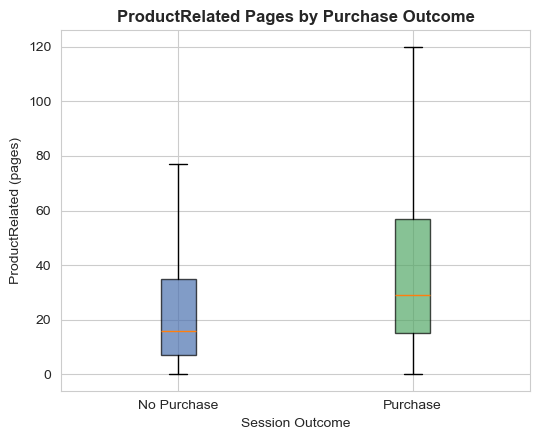

In [45]:
corr = df_eda['ProductRelated'].corr(df_eda['Revenue'].astype(int))
print(f"Correlation (ProductRelated, Revenue): {corr:.3f}")
print(df_eda.groupby('Revenue')['ProductRelated'].describe()[['count','mean','50%','std']])

plot_box_by_revenue(df_eda, 'ProductRelated', 'ProductRelated Pages by Purchase Outcome', 'ProductRelated (pages)')

### Key Results
- Correlation with Revenue: **r = 0.156** (weak positive)
- Mean ProductRelated pages: **48.21** for purchasers vs **29.05** for non-purchasers (median 29 vs 16)

### Insight
Purchasers view considerably more product pages on average than non-purchasers, but the correlation coefficient (0.156) is weak — page count alone explains very little of the variance in purchase outcome, confirming that browsing depth is directional but not predictive on its own.

### Business Recommendation
Use ProductRelated as one weak contextual signal, not a standalone KPI for purchase likelihood; combine it with intent signals such as PageValues (Q16) for meaningful targeting.

## Business Question 12

### Question
How does ProductRelated_Duration differ between purchasers and non-purchasers?

### Business Objective
Assess whether time spent on product pages is a stronger differentiator than page count.

### Data / Features Used
`ProductRelated_Duration`, `Revenue`

           count         mean         50%          75%
Revenue                                               
False    10297.0  1082.976881   526.00000  1345.755952
True      1908.0  1876.209615  1109.90625  2266.011310


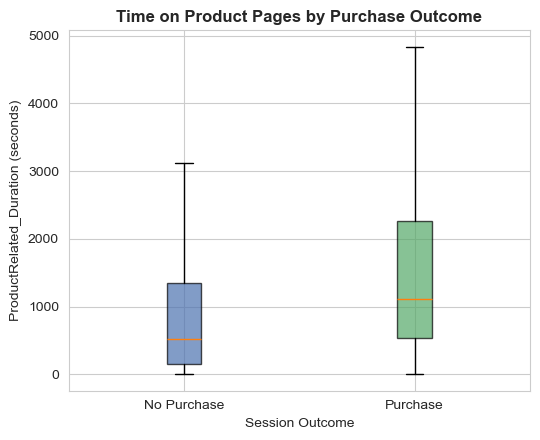

In [46]:
print(df_eda.groupby('Revenue')['ProductRelated_Duration'].describe()[['count','mean','50%','75%']])
plot_box_by_revenue(df_eda, 'ProductRelated_Duration', 'Time on Product Pages by Purchase Outcome',
                     'ProductRelated_Duration (seconds)')

### Key Results
- Mean ProductRelated_Duration: **1,876s (~31.3 min)** for purchasers vs **1,083s (~18.0 min)** for non-purchasers — a **73% relative increase**
- Median duration is also substantially higher for purchasers

### Insight
Purchasers spend roughly 73% more cumulative time on product pages than non-purchasers, a larger relative gap than the page-count difference in Q11 (66%), suggesting depth of engagement per page (not just number of pages) matters for conversion.

### Business Recommendation
Track time-on-product-page as a secondary engagement KPI alongside page count; sessions with long dwell time but low PageValues (see Q15) are worth investigating for UX friction rather than assumed disinterest.

## Business Question 13

### Question
Does spending more time per product page relate to higher conversion?

### Business Objective
Distinguish "efficient browsing" (fast, decisive) from "struggling browsing" (slow, confused) by looking at average time per page rather than total time.

### Data / Features Used
`ProductRelated`, `ProductRelated_Duration`, `Revenue`

                  Sessions  Purchases  ConversionRate_%
TPP_bin                                                
(-0.001, 15.8]        2434        116              4.77
(15.8, 24.609]        2433        339             13.93
(24.609, 34.395]      2433        429             17.63
(34.395, 51.106]      2433        549             22.56
(51.106, 1411.0]      2434        469             19.27


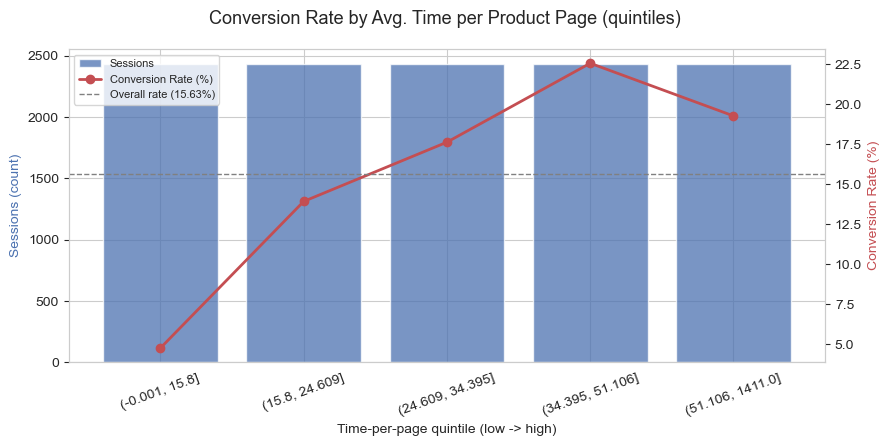

In [47]:
sessions_with_pages = df_eda[df_eda['ProductRelated'] > 0].copy()
sessions_with_pages['TimePerPage'] = sessions_with_pages['ProductRelated_Duration'] / sessions_with_pages['ProductRelated']
sessions_with_pages['TPP_bin'] = pd.qcut(sessions_with_pages['TimePerPage'], 5, duplicates='drop')
tpp_table = conversion_table(sessions_with_pages, 'TPP_bin', sort=False)
print(tpp_table)
plot_conversion(tpp_table, 'Conversion Rate by Avg. Time per Product Page (quintiles)',
                 'Time-per-page quintile (low -> high)', rot=20)

### Key Results
Conversion rises from **4.77%** in the fastest quintile (≤15.8s/page) to **22.56%** in the 4th quintile (34.4–51.1s/page), then **dips slightly to 19.27%** in the slowest quintile (>51.1s/page)

### Insight
Conversion increases steadily with more time spent per page up to a point (~35–51s/page), then plateaus/slightly reverses at the very highest dwell times — consistent with a mix of genuinely deliberating high-intent shoppers and confused/struggling visitors both appearing in the slowest-browsing group.

### Business Recommendation
Treat very fast page-flipping (under ~16s/page) as a low-intent or bounce-risk signal worth a re-engagement nudge, and treat the top dwell-time band as mixed-quality — pair it with PageValues or scroll/click signals before assuming it indicates strong purchase intent.

## Business Question 14

### Question
What is the relationship between ProductRelated and ProductRelated_Duration?

### Business Objective
Confirm these two features move together (as expected) before using them independently elsewhere in the analysis, to avoid double-counting the same underlying signal.

### Data / Features Used
`ProductRelated`, `ProductRelated_Duration`

Correlation (ProductRelated, ProductRelated_Duration): 0.860


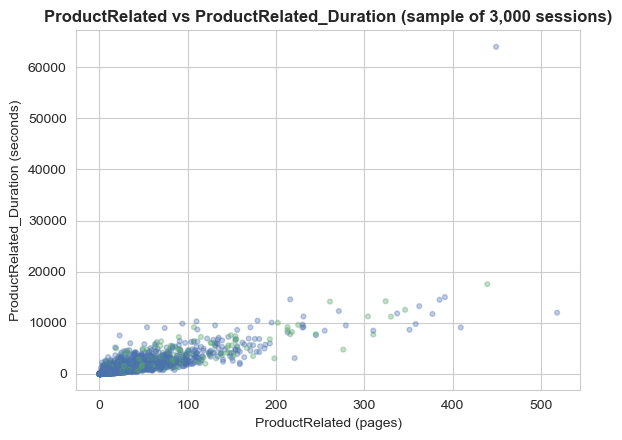

In [48]:
corr = df_eda['ProductRelated'].corr(df_eda['ProductRelated_Duration'])
print(f"Correlation (ProductRelated, ProductRelated_Duration): {corr:.3f}")

fig, ax = plt.subplots(figsize=(6, 4.5))
sample = df_eda.sample(min(3000, len(df_eda)), random_state=42)
ax.scatter(sample['ProductRelated'], sample['ProductRelated_Duration'],
           c=sample['Revenue'].map({True: '#55A868', False: '#4C72B0'}), alpha=0.35, s=12)
ax.set_xlabel('ProductRelated (pages)'); ax.set_ylabel('ProductRelated_Duration (seconds)')
ax.set_title('ProductRelated vs ProductRelated_Duration (sample of 3,000 sessions)')
plt.tight_layout(); plt.show()

### Key Results
Correlation: **r = 0.860** (strong positive)

### Insight
As expected, page count and total duration are strongly correlated (r=0.86) — sessions that view more product pages also spend proportionally more total time on them. This means the two features carry substantially overlapping information.

### Business Recommendation
When building predictive models or dashboards, treat ProductRelated and ProductRelated_Duration as largely redundant; prefer a single derived metric (e.g. average time per page, Q13) over including both raw features with equal weight to avoid overstating the importance of "browsing volume" as two separate signals.

## Business Question 15

### Question
Do sessions with high ProductRelated pages but low PageValues convert less often?

### Business Objective
Identify a specific, actionable low-conversion segment: shoppers who browse extensively but never reach a "valuable" page, to diagnose product-discovery or navigation friction.

### Data / Features Used
`ProductRelated`, `PageValues`, `Revenue`

High-ProductRelated sessions overall: 3,017 (rate 23.63%)
  -> High pages & PageValues=0: 1,727 sessions, conversion 8.22%
  -> High pages & PageValues>0:  1,290 sessions, conversion 44.26%


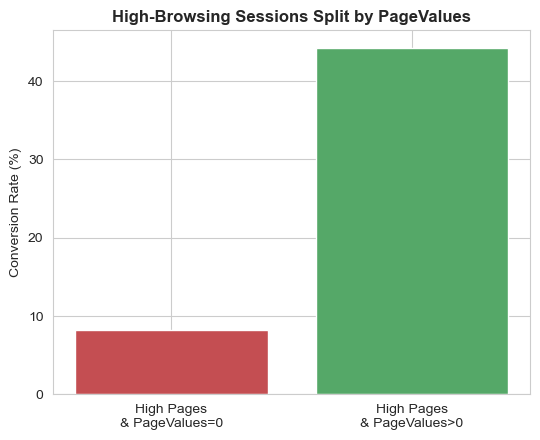

In [49]:
high_pr = df_eda['ProductRelated'] > df_eda['ProductRelated'].quantile(0.75)
zero_pv = df_eda['PageValues'] == 0
seg_high_low = df_eda[high_pr & zero_pv]
seg_high_high = df_eda[high_pr & ~zero_pv]

print(f"High-ProductRelated sessions overall: {high_pr.sum():,} (rate {df_eda[high_pr]['Revenue'].mean()*100:.2f}%)")
print(f"  -> High pages & PageValues=0: {len(seg_high_low):,} sessions, "
      f"conversion {seg_high_low['Revenue'].mean()*100:.2f}%")
print(f"  -> High pages & PageValues>0:  {len(seg_high_high):,} sessions, "
      f"conversion {seg_high_high['Revenue'].mean()*100:.2f}%")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.bar(['High Pages\n& PageValues=0', 'High Pages\n& PageValues>0'],
       [seg_high_low['Revenue'].mean()*100, seg_high_high['Revenue'].mean()*100],
       color=['#C44E52', '#55A868'])
ax.set_ylabel('Conversion Rate (%)'); ax.set_title('High-Browsing Sessions Split by PageValues')
plt.tight_layout(); plt.show()

### Key Results
Among top-quartile ProductRelated sessions (n=3,017, overall 23.63% conversion): those with **PageValues=0** (n=1,727) convert at only **8.22%**, while those with **PageValues>0** (n=1,290) convert at **44.26%**

### Insight
High page-browsing volume is not itself the driver of conversion — it is almost entirely conditional on whether the session also touches a high-value page. Heavy browsers who never hit a valuable page convert barely above the overall no-signal baseline, while heavy browsers who do convert at over 5x that rate.

### Business Recommendation
Investigate the product-discovery path for the high-pages/zero-PageValues segment specifically — this looks like a product-findability or catalog-navigation problem (visitors are browsing a lot but not reaching the pages that historically lead to sales), and fixing it could unlock meaningful incremental conversion from an already-engaged audience.

## Business Question 16

### Question
Does PageValues have a stronger relationship with Revenue than ProductRelated?

### Business Objective
Directly compare the predictive strength of the two most commonly used "engagement" features to prioritize which one drives targeting and modeling decisions.

### Data / Features Used
`PageValues`, `ProductRelated`, `Revenue`

Correlation (PageValues, Revenue):     0.492
Correlation (ProductRelated, Revenue): 0.156


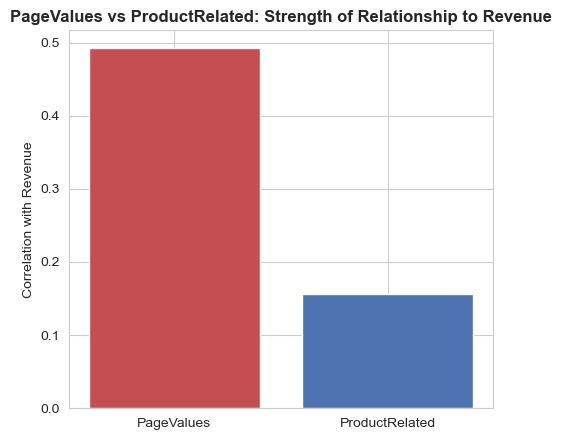

In [50]:
corr_pv = df_eda['PageValues'].corr(df_eda['Revenue'].astype(int))
corr_pr = df_eda['ProductRelated'].corr(df_eda['Revenue'].astype(int))
print(f"Correlation (PageValues, Revenue):     {corr_pv:.3f}")
print(f"Correlation (ProductRelated, Revenue): {corr_pr:.3f}")

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.bar(['PageValues', 'ProductRelated'], [corr_pv, corr_pr], color=['#C44E52', '#4C72B0'])
ax.set_ylabel('Correlation with Revenue'); ax.set_title('PageValues vs ProductRelated: Strength of Relationship to Revenue')
plt.tight_layout(); plt.show()

### Key Results
- Correlation (PageValues, Revenue): **r = 0.492**
- Correlation (ProductRelated, Revenue): **r = 0.156**

### Insight
PageValues is roughly **3x more strongly correlated** with purchase outcome than ProductRelated. This confirms the pattern already seen in Q8/Q9/Q15: which pages a visitor reaches matters far more than how many pages they view.

### Business Recommendation
Weight PageValues as the primary intent signal in any scoring model, dashboard, or real-time trigger; ProductRelated (raw page count) should be treated as a secondary, contextual signal at most.

## Business Question 17

### Question
How does conversion rate change across ProductRelated page-count ranges?

### Business Objective
Build a granular conversion curve across browsing-depth bands, complementing the PageValues curve in Q9.

### Data / Features Used
`ProductRelated`, `Revenue`

        Sessions  Purchases  ConversionRate_%
PR_bin                                       
0             38          6             15.79
1-5         2206         96              4.35
6-10        1804        185             10.25
11-20       2560        392             15.31
21-40       2760        545             19.75
41-80       1749        367             20.98
80+         1088        317             29.14


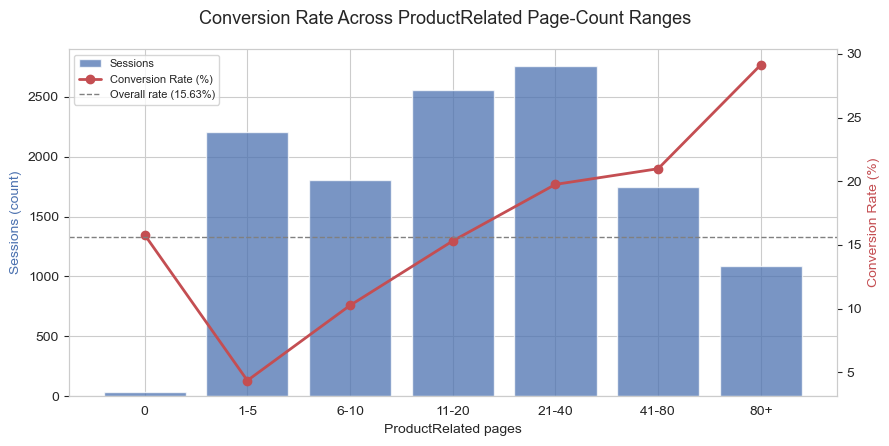

In [51]:
pr_bins = [-1, 0, 5, 10, 20, 40, 80, df_eda['ProductRelated'].max() + 1]
pr_labels = ['0', '1-5', '6-10', '11-20', '21-40', '41-80', '80+']
df_eda['PR_bin'] = pd.cut(df_eda['ProductRelated'], bins=pr_bins, labels=pr_labels)
pr_table = conversion_table(df_eda, 'PR_bin', sort=False)
print(pr_table)
plot_conversion(pr_table, 'Conversion Rate Across ProductRelated Page-Count Ranges', 'ProductRelated pages')

### Key Results
| Pages | Sessions | Conversion Rate |
|---|---|---|
| 0 | 38 | 15.79% |
| 1–5 | 2,206 | 4.35% (lowest) |
| 6–10 | 1,804 | 10.25% |
| 11–20 | 2,560 | 15.31% |
| 21–40 | 2,760 | 19.75% |
| 41–80 | 1,749 | 20.98% |
| 80+ | 1,088 | **29.14%** (highest)

### Insight
Conversion rises fairly steadily with page count from the 1–5 page band onward, roughly tripling from 1–5 pages (4.35%) to 21–40 pages (19.75%) and reaching 29.14% for the heaviest browsers (80+ pages) — though this rise is much less steep than the PageValues curve in Q9.

### Business Recommendation
Use ProductRelated page-count bands as a coarse secondary segmentation for lifecycle email or retargeting cadence, but do not treat it as a precise intent score — the PageValues curve (Q9) is both steeper and more monotonic.

## Business Question 18

### Question
How does conversion rate change across ProductRelated_Duration ranges?

### Business Objective
Build the equivalent conversion curve for time-on-product-pages, to see if duration is a cleaner signal than raw page count.

### Data / Features Used
`ProductRelated_Duration`, `Revenue`

                       Sessions  Purchases  ConversionRate_%
PRD_bin                                                     
(-0.001, 103.5]            2035         84              4.13
(103.5, 303.667]           2033        149              7.33
(303.667, 608.943]         2035        314             15.43
(608.943, 1098.525]        2034        402             19.76
(1098.525, 2061.067]       2034        428             21.04
(2061.067, 63973.522]      2034        531             26.11


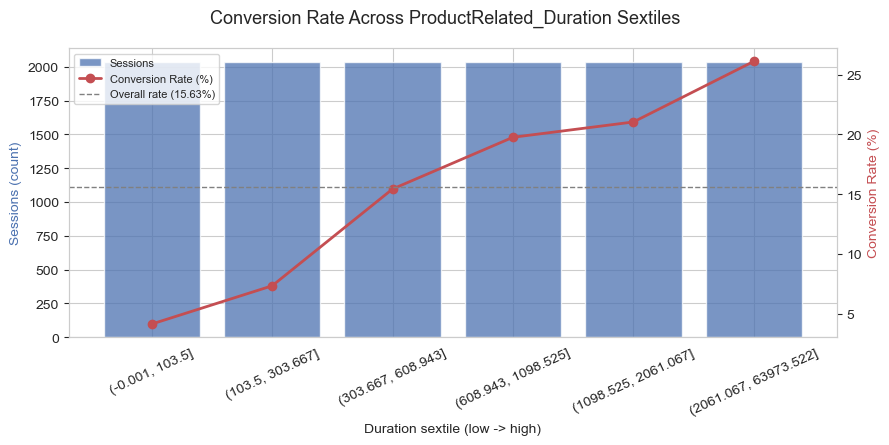

In [52]:
df_eda['PRD_bin'] = pd.qcut(df_eda['ProductRelated_Duration'], 6, duplicates='drop')
prd_table = conversion_table(df_eda, 'PRD_bin', sort=False)
print(prd_table)
plot_conversion(prd_table, 'Conversion Rate Across ProductRelated_Duration Sextiles', 'Duration sextile (low -> high)', rot=25)

### Key Results
Conversion rises from **4.13%** in the shortest-duration sextile to **26.11%** in the longest-duration sextile (2,061s+) — a steady, roughly monotonic increase across all six bands

### Insight
Unlike page count (Q17), which rises but then flattens near the top, ProductRelated_Duration shows a smoother and slightly steeper monotonic increase across every band, suggesting total time invested is a marginally cleaner engagement signal than raw page count, though still much weaker than PageValues.

### Business Recommendation
If only one "browsing volume" feature can be kept in a simplified dashboard or lightweight model, prefer ProductRelated_Duration over ProductRelated — it shows a more consistent, monotonic relationship with conversion across its full range.

## Business Question 19

### Question
Do customers who browse more pages necessarily have higher conversion?

### Business Objective
Check the ProductRelated conversion curve for non-monotonic dips that would disprove a simple "more pages = more likely to buy" assumption.

### Data / Features Used
`ProductRelated` (binned), `Revenue`

In [53]:
print(df_eda.groupby('PR_bin', observed=True)['Revenue'].mean().mul(100).round(2))

PR_bin
0        15.79
1-5       4.35
6-10     10.25
11-20    15.31
21-40    19.75
41-80    20.98
80+      29.14
Name: Revenue, dtype: float64


### Key Results
Rate by band: 0 pages = 15.79%, **1–5 pages = 4.35% (a dip below the 0-page group)**, 6–10 = 10.25%, 11–20 = 15.31%, 21–40 = 19.75%, 41–80 = 20.98%, 80+ = 29.14%

### Insight
No — the relationship is **not strictly monotonic**. Sessions with zero product pages (15.79%) actually convert better than sessions with just 1–5 pages (4.35%); those zero-page sessions are likely direct-to-checkout or highly targeted visits. From 6+ pages onward the pattern does become consistently increasing.

### Business Recommendation
Do not apply a single linear "more browsing = more buying" rule uniformly — the very-low-page segment is a distinct behavior pattern (likely direct-intent shoppers) and should be modeled or targeted separately from the 1–5 page "early browsing, high drop-off" segment, which is this analysis's single worst-converting band.

## Business Question 20

### Question
Which feature combinations characterize highly engaged but non-converting sessions?

### Business Objective
Profile the specific behavioral fingerprint of "engaged but didn't buy" sessions so the business can design a targeted recovery/retargeting treatment.

### Data / Features Used
`ProductRelated`, `ProductRelated_Duration`, `PageValues`, `BounceRates`, `ExitRates`, `Revenue`

Highly engaged sessions: 2,263 | Non-converting: 1,688 | Converting: 575
             Non-Converting (high engagement)  Converting (high engagement)
PageValues                             4.6379                       17.4331
BounceRates                            0.0073                        0.0048
ExitRates                              0.0215                        0.0162


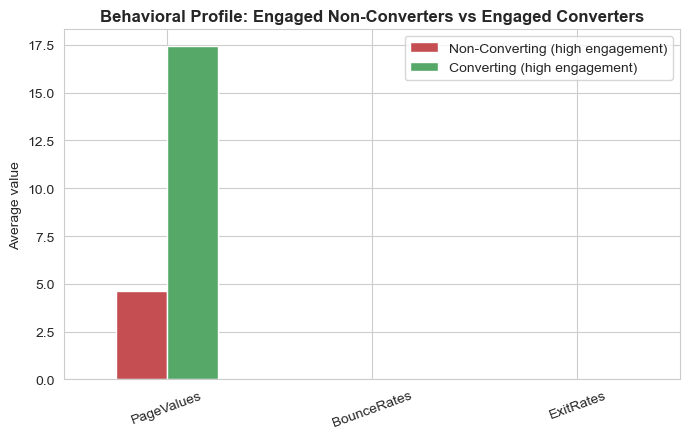

In [54]:
high_engaged = df_eda[(df_eda['ProductRelated'] > df_eda['ProductRelated'].quantile(0.75)) &
                       (df_eda['ProductRelated_Duration'] > df_eda['ProductRelated_Duration'].quantile(0.75))]
non_converting = high_engaged[~high_engaged['Revenue']]
converting = high_engaged[high_engaged['Revenue']]

profile = pd.DataFrame({
    'Non-Converting (high engagement)': non_converting[['PageValues','BounceRates','ExitRates']].mean(),
    'Converting (high engagement)': converting[['PageValues','BounceRates','ExitRates']].mean()
})
print(f"Highly engaged sessions: {len(high_engaged):,} | Non-converting: {len(non_converting):,} | Converting: {len(converting):,}")
print(profile.round(4))

profile.plot(kind='bar', figsize=(7,4.5), color=['#C44E52','#55A868'])
plt.title('Behavioral Profile: Engaged Non-Converters vs Engaged Converters')
plt.ylabel('Average value'); plt.xticks(rotation=20); plt.tight_layout(); plt.show()

### Key Results
Among the 2,263 highly-engaged sessions (1,688 non-converting / 575 converting):
- Non-converting: avg PageValues **4.64**, avg BounceRates **0.0073**, avg ExitRates **0.0215**
- Converting: avg PageValues **17.43**, avg BounceRates **0.0048**, avg ExitRates **0.0162**

### Insight
Even within an already highly-engaged population, non-converters are clearly distinguished by much lower PageValues (4.64 vs 17.43, a ~3.8x gap) and somewhat higher ExitRates/BounceRates. This is a low-bounce, high-browsing, low-value-page audience — genuinely interested visitors who are not finding a compelling reason (offer, product fit, trust signal) to convert.

### Business Recommendation
Build a specific "engaged but not converting" retargeting segment (high ProductRelated + high duration + low PageValues) and serve it incentive-based messaging (discount, social proof, urgency) rather than generic browse-abandonment ads, since these visitors are already deeply engaged and simply need a final push.

## 4. Bounce / Exit / Engagement — Conversion Barriers

## Business Question 21

### Question
How do BounceRates differ between purchasers and non-purchasers?

### Business Objective
Test whether Google-Analytics bounce rate (single-page-and-leave) is a meaningful friction signal for conversion.

### Data / Features Used
`BounceRates`, `Revenue`

           count      mean       50%       75%
Revenue                                       
False    10297.0  0.023197  0.003922  0.019259
True      1908.0  0.005117  0.000000  0.006452


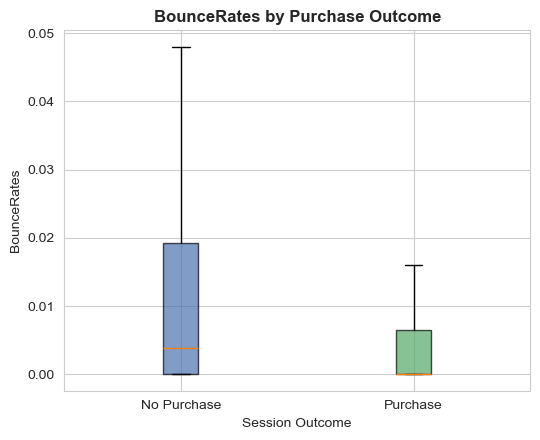

In [55]:
print(df_eda.groupby('Revenue')['BounceRates'].describe()[['count','mean','50%','75%']])
plot_box_by_revenue(df_eda, 'BounceRates', 'BounceRates by Purchase Outcome')

### Key Results
Mean BounceRates: **0.0231** for non-purchasers vs **0.0051** for purchasers — purchasers' bounce rate is roughly **4.5x lower**

### Insight
Purchasing sessions almost never bounce; non-purchasing sessions bounce at a meaningfully higher (though still numerically small, since BounceRates is a page-level GA metric) rate. High bounce risk is strongly associated with abandoning the funnel entirely.

### Business Recommendation
Prioritize landing-page relevance and load-speed fixes for the highest-BounceRates entry pages/traffic sources — reducing early-session bounce is one of the most direct levers on conversion.

## Business Question 22

### Question
How do ExitRates differ between purchasers and non-purchasers?

### Business Objective
Test whether exit rate (leaving from a given page, not necessarily the entry page) separates purchasers from non-purchasers as clearly as bounce rate does.

### Data / Features Used
`ExitRates`, `Revenue`

           count      mean       50%       75%
Revenue                                       
False    10297.0  0.045526  0.028382  0.051538
True      1908.0  0.019555  0.016000  0.025000


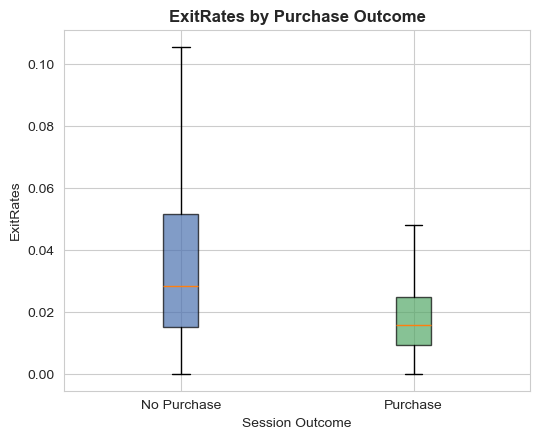

In [56]:
print(df_eda.groupby('Revenue')['ExitRates'].describe()[['count','mean','50%','75%']])
plot_box_by_revenue(df_eda, 'ExitRates', 'ExitRates by Purchase Outcome')

### Key Results
Mean ExitRates: **0.0455** for non-purchasers vs **0.0196** for purchasers — roughly **2.3x lower** for purchasers

### Insight
The gap for ExitRates is directionally the same as BounceRates (lower for purchasers) but proportionally smaller (2.3x vs 4.5x), since ExitRates is averaged across every page in the session rather than just the entry page.

### Business Recommendation
Use ExitRates to identify specific weak pages within an otherwise-good session (e.g. a confusing checkout or shipping page), complementing BounceRates which flags weak entry points.

## Business Question 23

### Question
Which has a stronger relationship with conversion: BounceRates or ExitRates?

### Business Objective
Decide which of the two friction metrics should be prioritized in dashboards/alerts when only one can be highlighted.

### Data / Features Used
`BounceRates`, `ExitRates`, `Revenue`

Correlation (BounceRates, Revenue): -0.145
Correlation (ExitRates, Revenue):   -0.204


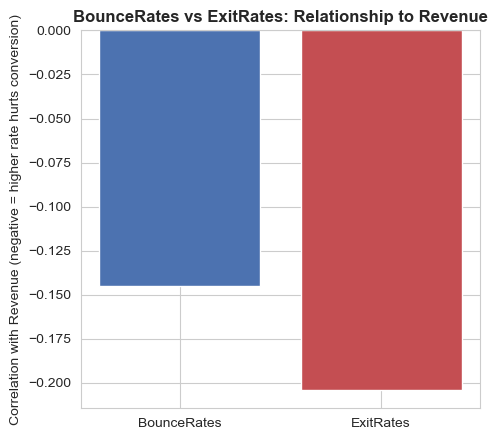

In [57]:
corr_br = df_eda['BounceRates'].corr(df_eda['Revenue'].astype(int))
corr_er = df_eda['ExitRates'].corr(df_eda['Revenue'].astype(int))
print(f"Correlation (BounceRates, Revenue): {corr_br:.3f}")
print(f"Correlation (ExitRates, Revenue):   {corr_er:.3f}")

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.bar(['BounceRates', 'ExitRates'], [corr_br, corr_er], color=['#4C72B0', '#C44E52'])
ax.set_ylabel('Correlation with Revenue (negative = higher rate hurts conversion)')
ax.set_title('BounceRates vs ExitRates: Relationship to Revenue')
plt.tight_layout(); plt.show()

### Key Results
- Correlation (BounceRates, Revenue): **r = -0.145**
- Correlation (ExitRates, Revenue): **r = -0.204**

### Insight
ExitRates has a somewhat stronger (more negative) relationship with Revenue than BounceRates, despite BounceRates showing the larger relative mean gap in Q21 — because ExitRates varies across the *entire* session and therefore captures friction on more pages, including late-funnel pages closer to the purchase decision.

### Business Recommendation
When only one friction metric can be monitored operationally, prioritize **ExitRates**, and specifically flag high-ExitRates pages later in the session (e.g. cart, shipping, payment) as the most actionable optimization targets.

## Business Question 24

### Question
What happens to conversion rate when both BounceRates and ExitRates are low?

### Business Objective
Quantify the combined effect of low friction on both metrics simultaneously versus each alone.

### Data / Features Used
`BounceRates`, `ExitRates`, `Revenue`

Both BounceRates & ExitRates BELOW median: 4,070 sessions, conversion 24.69%
Both BounceRates & ExitRates ABOVE median: 4,255 sessions, conversion 7.31%
Overall conversion: 15.63%


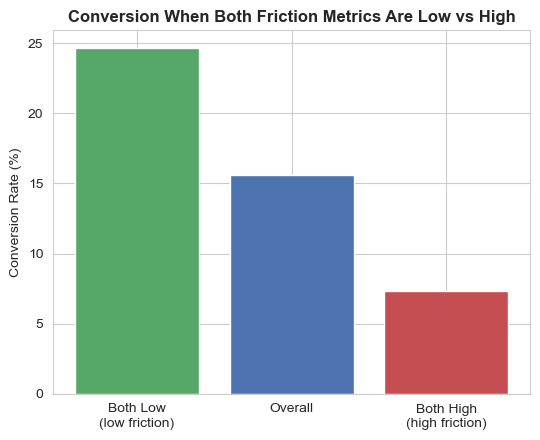

In [58]:
low_br = df_eda['BounceRates'] < df_eda['BounceRates'].median()
low_er = df_eda['ExitRates'] < df_eda['ExitRates'].median()

both_low = df_eda[low_br & low_er]
both_high = df_eda[~low_br & ~low_er]
print(f"Both BounceRates & ExitRates BELOW median: {len(both_low):,} sessions, "
      f"conversion {both_low['Revenue'].mean()*100:.2f}%")
print(f"Both BounceRates & ExitRates ABOVE median: {len(both_high):,} sessions, "
      f"conversion {both_high['Revenue'].mean()*100:.2f}%")
print(f"Overall conversion: {OVERALL_RATE:.2f}%")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.bar(['Both Low\n(low friction)', 'Overall', 'Both High\n(high friction)'],
       [both_low['Revenue'].mean()*100, OVERALL_RATE, both_high['Revenue'].mean()*100],
       color=['#55A868', '#4C72B0', '#C44E52'])
ax.set_ylabel('Conversion Rate (%)'); ax.set_title('Conversion When Both Friction Metrics Are Low vs High')
plt.tight_layout(); plt.show()

### Key Results
- Both BounceRates & ExitRates below median: **4,070 sessions, 24.69% conversion**
- Both above median: **4,255 sessions, 7.31% conversion**
- Overall baseline: 15.63%

### Insight
Combining both low-friction signals produces roughly a **3.4x** gap versus the both-high group (24.69% vs 7.31%), a much larger separation than either metric individually (Q21/Q22). Low BounceRates and low ExitRates reinforce each other as a compound low-friction indicator.

### Business Recommendation
Build a composite "friction score" from BounceRates + ExitRates rather than monitoring either alone — the combined signal is a substantially stronger conversion predictor than either metric in isolation.

## Business Question 25

### Question
What is the conversion rate for sessions with high engagement but high ExitRates?

### Business Objective
Identify sessions that look promising on the surface (lots of product-page time) but are structurally leaking users out, to prioritize exit-page fixes.

### Data / Features Used
`ProductRelated_Duration`, `ExitRates`, `Revenue`

In [59]:
high_eng = df_eda['ProductRelated_Duration'] > df_eda['ProductRelated_Duration'].quantile(0.75)
high_er = df_eda['ExitRates'] > df_eda['ExitRates'].quantile(0.75)

seg_leak = df_eda[high_eng & high_er]
seg_healthy = df_eda[high_eng & ~high_er]
print(f"High engagement & high ExitRates ('leaking'): {len(seg_leak):,} sessions, "
      f"conversion {seg_leak['Revenue'].mean()*100:.2f}%")
print(f"High engagement & low/mid ExitRates: {len(seg_healthy):,} sessions, "
      f"conversion {seg_healthy['Revenue'].mean()*100:.2f}%")

High engagement & high ExitRates ('leaking'): 190 sessions, conversion 3.16%
High engagement & low/mid ExitRates: 2,861 sessions, conversion 25.13%


### Key Results
- High engagement & high ExitRates: **190 sessions, 3.16% conversion**
- High engagement & low/mid ExitRates: **2,861 sessions, 25.13% conversion**

### Insight
Even with strong product-page engagement, a high ExitRate essentially neutralizes it — conversion collapses to 3.16%, well below even the overall 15.63% baseline, and roughly **8x lower** than the equally-engaged low-ExitRate group.

### Business Recommendation
Treat "engaged but high-ExitRate" as a distinct, high-priority UX investigation segment — these are visitors who did the work of browsing deeply but are structurally exiting the site before converting, most likely due to a specific broken or confusing page in their path.

## Business Question 26

### Question
What is the conversion rate for sessions with low engagement and high BounceRates?

### Business Objective
Confirm the expected worst-case segment (disengaged + high bounce) to validate it as a true "lost cause" baseline rather than a recoverable segment.

### Data / Features Used
`ProductRelated_Duration`, `BounceRates`, `Revenue`

In [60]:
low_eng = df_eda['ProductRelated_Duration'] < df_eda['ProductRelated_Duration'].quantile(0.25)
high_br = df_eda['BounceRates'] > df_eda['BounceRates'].quantile(0.75)
seg = df_eda[low_eng & high_br]
print(f"Low engagement & high BounceRates: {len(seg):,} sessions, conversion {seg['Revenue'].mean()*100:.2f}%")
print(f"Overall conversion: {OVERALL_RATE:.2f}%")

Low engagement & high BounceRates: 1,376 sessions, conversion 1.96%
Overall conversion: 15.63%


### Key Results
Low engagement & high BounceRates: **1,376 sessions (11.3% of all sessions), 1.96% conversion**

### Insight
This segment converts at roughly **1/8th** the overall baseline rate and represents over a tenth of all traffic — confirming it as a genuinely low-value, high-volume segment rather than a data artifact.

### Business Recommendation
Do not spend retargeting budget on this segment; instead, investigate the entry channels and landing pages that disproportionately produce it (cross-reference with TrafficType, Q46) to reduce wasted acquisition spend at the source.

## Business Question 27

### Question
Does lower ExitRate consistently correspond to higher purchase conversion?

### Business Objective
Check the full ExitRates conversion curve for monotonicity before treating ExitRates as a reliable, always-linear signal.

### Data / Features Used
`ExitRates`, `Revenue`

                  Sessions  Purchases  ConversionRate_%
ER_bin                                                 
(-0.001, 0.0105]      2049        560             27.33
(0.0105, 0.0174]      2027        484             23.88
(0.0174, 0.025]       2069        399             19.28
(0.025, 0.0375]       1996        279             13.98
(0.0375, 0.0667]      2210        158              7.15
(0.0667, 0.2]         1854         28              1.51


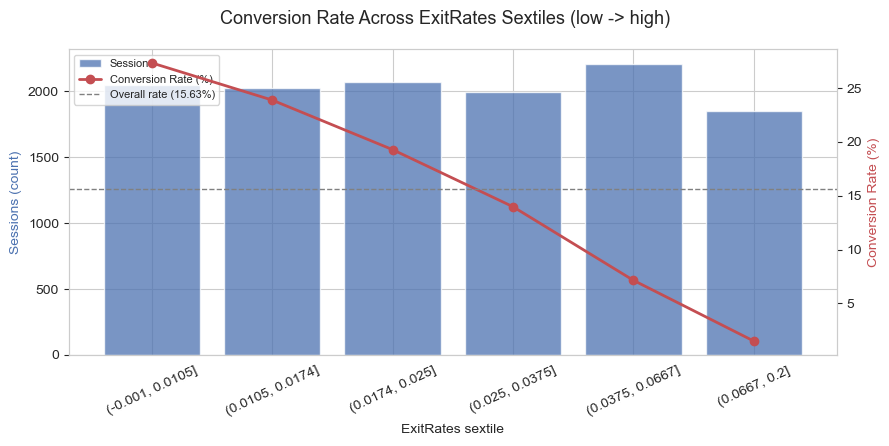

In [61]:
df_eda['ER_bin'] = pd.qcut(df_eda['ExitRates'], 6, duplicates='drop')
er_table = conversion_table(df_eda, 'ER_bin', sort=False)
print(er_table)
plot_conversion(er_table, 'Conversion Rate Across ExitRates Sextiles (low -> high)', 'ExitRates sextile', rot=25)

### Key Results
Conversion falls consistently across every ExitRates band: **27.33% (lowest ExitRates) → 23.88% → 19.28% → 13.98% → 7.15% → 1.51% (highest ExitRates)**

### Insight
Yes — the relationship is cleanly monotonic across all six bands with no reversals, making ExitRates one of the most reliably-behaved features in the dataset for conversion prediction.

### Business Recommendation
ExitRates is safe to use as a linear score/weight in rule-based scoring systems (unlike, e.g., ProductRelated in Q19, which had a non-monotonic dip) — lower is unambiguously better across its entire range.

## Business Question 28

### Question
Can we identify a high-engagement / low-conversion segment?

### Business Objective
Formally define and size the segment representing the greatest "lost opportunity" — visitors who look engaged but consistently fail to convert.

### Data / Features Used
`ProductRelated`, `PageValues`, `Revenue`

In [62]:
high_pr = df_eda[df_eda['ProductRelated'] > df_eda['ProductRelated'].quantile(0.75)]
segment = high_pr[high_pr['PageValues'] == 0]
print(f"Definition: top-quartile ProductRelated pages AND PageValues = 0")
print(f"Segment size: {len(segment):,} sessions ({len(segment)/len(high_pr)*100:.1f}% of all high-browsing sessions)")
print(f"Segment conversion rate: {segment['Revenue'].mean()*100:.2f}%")
print(f"vs. high-browsing sessions with PageValues>0: "
      f"{high_pr[high_pr['PageValues']>0]['Revenue'].mean()*100:.2f}%")

Definition: top-quartile ProductRelated pages AND PageValues = 0
Segment size: 1,727 sessions (57.2% of all high-browsing sessions)
Segment conversion rate: 8.22%
vs. high-browsing sessions with PageValues>0: 44.26%


### Key Results
Defined as top-quartile ProductRelated pages **and** PageValues=0: **1,727 sessions (57.2% of all high-browsing sessions), converting at only 8.22%** vs 44.26% for high-browsing sessions that do touch a valuable page

### Insight
This is the same segment surfaced in Q15, now sized and named explicitly: the majority (57.2%) of heavy browsers never reach a high-value page, and they represent the largest concrete "missed opportunity" pool in the dataset — already-engaged traffic converting far below its potential.

### Business Recommendation
Make this segment ("Deep Browser, No Value Page") a named, trackable cohort in analytics tooling and prioritize product-page discoverability and merchandising fixes aimed specifically at it.

## Business Question 29

### Question
Can we identify a low-engagement / high-conversion segment?

### Business Objective
Find visitors who convert efficiently with minimal browsing, since understanding what drives them (e.g. arriving with strong prior intent) could inform pre-visit marketing.

### Data / Features Used
`ProductRelated`, `PageValues`, `Revenue`

In [63]:
low_pr = df_eda[df_eda['ProductRelated'] <= df_eda['ProductRelated'].quantile(0.25)]
print(f"Low-browsing sessions (bottom quartile ProductRelated): {len(low_pr):,}, "
      f"conversion {low_pr['Revenue'].mean()*100:.2f}%")

seg = low_pr[low_pr['PageValues'] > df_eda['PageValues'].quantile(0.75)]
print(f"Low-browsing AND high PageValues: {len(seg):,} sessions, conversion {seg['Revenue'].mean()*100:.2f}%")

Low-browsing sessions (bottom quartile ProductRelated): 3,401, conversion 5.97%
Low-browsing AND high PageValues: 140 sessions, conversion 80.71%


### Key Results
Low-browsing sessions overall: **3,401 sessions, 5.97% conversion**. Within that group, sessions that also have high PageValues: **140 sessions, 80.71% conversion**

### Insight
A small but extremely efficient segment exists: visitors who browse very few pages but land on high-value pages convert at over 80%. These are likely direct-navigation or highly-targeted visitors (e.g. from a specific product email/ad) who arrive already knowing what they want.

### Business Recommendation
Nurture and scale acquisition channels that drive this exact pattern (deep-linked ads, product-specific email campaigns) — they produce disproportionately efficient conversion with minimal on-site browsing required.

## Business Question 30

### Question
What behavioral patterns distinguish high-intent sessions from low-intent sessions?

### Business Objective
Synthesize Sections 3 and 4 into a single side-by-side behavioral profile of purchasers vs non-purchasers across the key engagement and friction metrics.

### Data / Features Used
`PageValues`, `ExitRates`, `BounceRates`, `ProductRelated`, `ProductRelated_Duration`, `Revenue`

                         No Purchase   Purchase  Relative Difference
PageValues                    2.0000    27.2645               1263.2
ExitRates                     0.0455     0.0196                -57.0
BounceRates                   0.0232     0.0051                -77.9
ProductRelated               29.0504    48.2102                 66.0
ProductRelated_Duration    1082.9769  1876.2096                 73.2


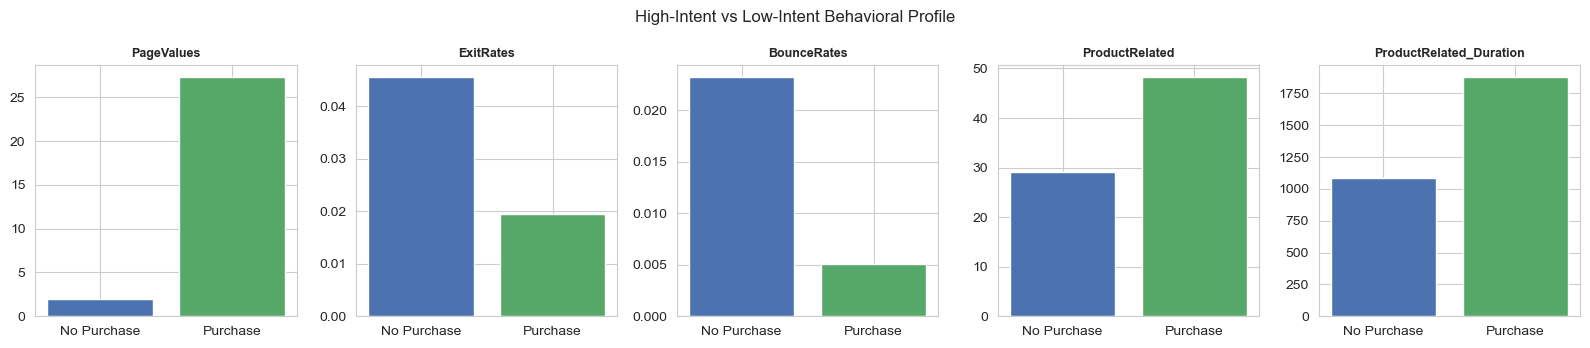

In [64]:
profile_cols = ['PageValues', 'ExitRates', 'BounceRates', 'ProductRelated', 'ProductRelated_Duration']
profile = df_eda.groupby('Revenue')[profile_cols].mean().T
profile.columns = ['No Purchase', 'Purchase']
profile['Relative Difference'] = ((profile['Purchase'] - profile['No Purchase']) /
                                    profile['No Purchase'].replace(0, np.nan) * 100).round(1)
print(profile.round(4))

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
for ax, col in zip(axes, profile_cols):
    ax.bar(['No Purchase', 'Purchase'], df_eda.groupby('Revenue')[col].mean(), color=['#4C72B0','#55A868'])
    ax.set_title(col, fontsize=9)
plt.suptitle('High-Intent vs Low-Intent Behavioral Profile')
plt.tight_layout(); plt.show()

### Key Results
| Metric | No Purchase | Purchase | Relative Diff |
|---|---|---|---|
| PageValues | 2.00 | 27.26 | **+1,263%** |
| ExitRates | 0.0455 | 0.0196 | -57.0% |
| BounceRates | 0.0232 | 0.0051 | -77.9% |
| ProductRelated | 29.05 | 48.21 | +66.0% |
| ProductRelated_Duration | 1,083 | 1,876 | +73.2% |

### Insight
High-intent sessions are defined far more by an enormous jump in PageValues (over 13x) than by any other metric — friction metrics (BounceRates, ExitRates) drop by roughly half to three-quarters, and engagement metrics (pages, duration) rise by about two-thirds. PageValues is the dominant differentiator by a wide margin.

### Business Recommendation
Any lead-scoring, retargeting, or personalization system for this store should weight PageValues far above other browsing signals; friction metrics are useful as secondary "risk of drop-off" flags, and raw engagement volume is the weakest of the three signal families.

## 5. Administrative & Informational Behavior

## Business Question 31

### Question
Does visiting Administrative pages relate to purchase conversion?

### Business Objective
Determine whether account/order-management page activity (e.g. login, order history) is associated with purchase, since it may signal an existing-customer mindset.

### Data / Features Used
`Administrative`, `Revenue`

           Sessions  Purchases  ConversionRate_%
Admin_bin                                       
0              5643        514              9.11
1-2            2468        496             20.10
3-5            2255        445             19.73
6-10           1435        343             23.90
10+             404        110             27.23

Correlation (Administrative, Revenue): 0.136


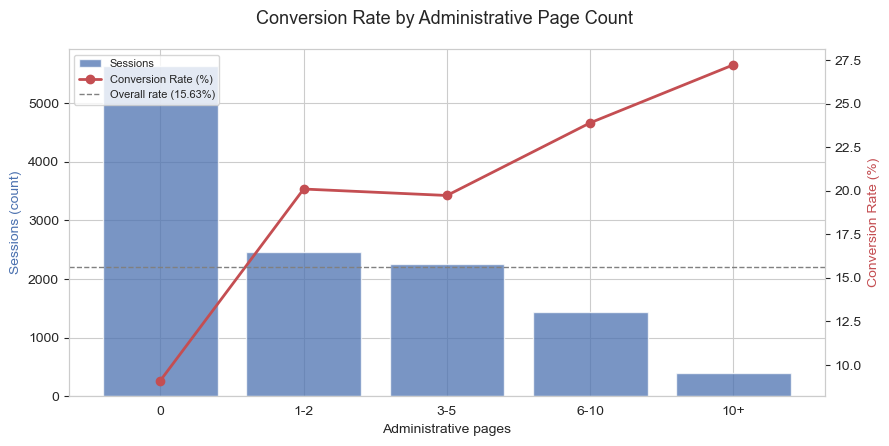

In [65]:
adm_bins = [-1, 0, 2, 5, 10, df_eda['Administrative'].max() + 1]
adm_labels = ['0', '1-2', '3-5', '6-10', '10+']
df_eda['Admin_bin'] = pd.cut(df_eda['Administrative'], bins=adm_bins, labels=adm_labels)
adm_table = conversion_table(df_eda, 'Admin_bin', sort=False)
print(adm_table)
print(f"\nCorrelation (Administrative, Revenue): {df_eda['Administrative'].corr(df_eda['Revenue'].astype(int)):.3f}")
plot_conversion(adm_table, 'Conversion Rate by Administrative Page Count', 'Administrative pages')

### Key Results
| Admin pages | Sessions | Conversion Rate |
|---|---|---|
| 0 | 5,643 | 9.11% |
| 1–2 | 2,468 | 20.10% |
| 3–5 | 2,255 | 19.73% |
| 6–10 | 1,435 | 23.90% |
| 10+ | 404 | **27.23%**  &nbsp;&nbsp; (corr = 0.136)

### Insight
Conversion more than doubles once a visitor touches even 1–2 Administrative pages (9.11% → 20.10%), then keeps climbing gently with more Administrative activity. This is consistent with Administrative pages capturing account/checkout-adjacent behavior (e.g. account creation, address/payment management) that naturally clusters near a completed purchase.

### Business Recommendation
Treat any Administrative-page activity as a positive mid-to-late funnel signal (e.g. account setup during checkout) — it is not merely account-management noise but is meaningfully associated with purchase completion.

## Business Question 32

### Question
Does Administrative_Duration differ between purchasers and non-purchasers?

### Business Objective
Check whether time (not just page count) on Administrative pages also separates the two groups.

### Data / Features Used
`Administrative_Duration`, `Revenue`

           count        mean        50%         75%
Revenue                                            
False    10297.0   74.635276   0.000000   84.550000
True      1908.0  119.483244  52.366667  151.083333


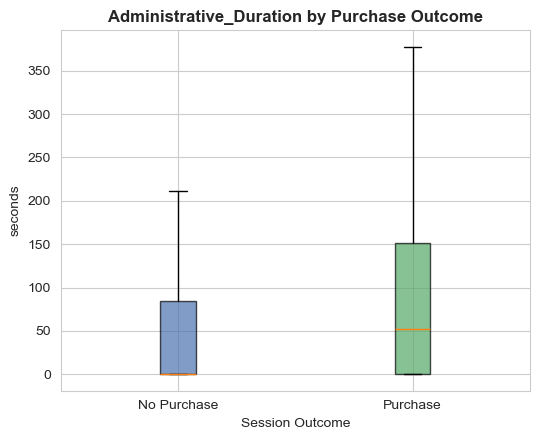

In [66]:
print(df_eda.groupby('Revenue')['Administrative_Duration'].describe()[['count','mean','50%','75%']])
plot_box_by_revenue(df_eda, 'Administrative_Duration', 'Administrative_Duration by Purchase Outcome', 'seconds')

### Key Results
Mean Administrative_Duration: **119.5s** for purchasers vs **74.6s** for non-purchasers (+60.1%); median is **52.4s** for purchasers vs **0s** for non-purchasers

### Insight
The median gap is especially telling: over half of non-purchasing sessions spend zero time on Administrative pages at all, while the typical purchasing session spends nearly a minute there — reinforcing that Administrative activity clusters around the purchase/checkout process.

### Business Recommendation
Ensure Administrative-area pages (account, address, order-related) are fast and friction-free, since purchasers disproportionately pass through them — any slowness or confusion here sits directly in the path of an already-converting visitor.

## Business Question 33

### Question
Does visiting Informational pages relate to purchase conversion?

### Business Objective
Test whether content pages (FAQ, shipping/returns policy, About) help or hurt conversion, to guide whether to promote or de-emphasize them in navigation.

### Data / Features Used
`Informational`, `Revenue`

          Sessions  Purchases  ConversionRate_%
Info_bin                                       
0             9574       1295             13.53
1-2           1769        390             22.05
3-5            701        186             26.53
6+             161         37             22.98

Correlation (Informational, Revenue): 0.094


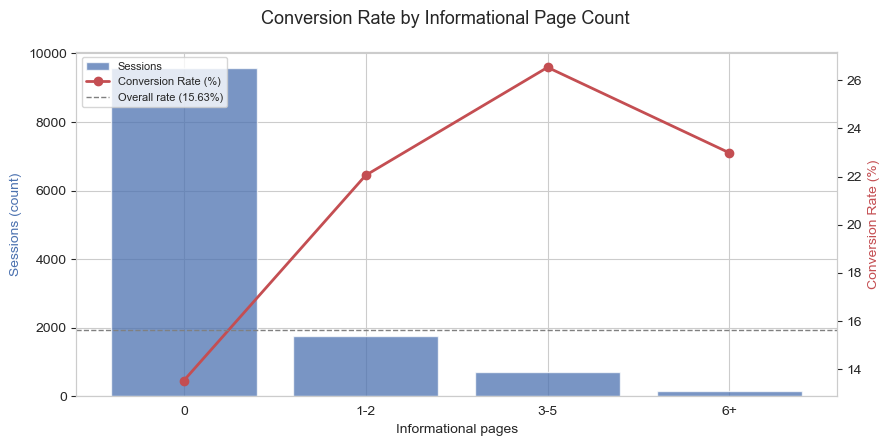

In [67]:
info_bins = [-1, 0, 2, 5, df_eda['Informational'].max() + 1]
info_labels = ['0', '1-2', '3-5', '6+']
df_eda['Info_bin'] = pd.cut(df_eda['Informational'], bins=info_bins, labels=info_labels)
info_table = conversion_table(df_eda, 'Info_bin', sort=False)
print(info_table)
print(f"\nCorrelation (Informational, Revenue): {df_eda['Informational'].corr(df_eda['Revenue'].astype(int)):.3f}")
plot_conversion(info_table, 'Conversion Rate by Informational Page Count', 'Informational pages')

### Key Results
| Info pages | Sessions | Conversion Rate |
|---|---|---|
| 0 | 9,574 | 13.53% |
| 1–2 | 1,769 | 22.05% |
| 3–5 | 701 | **26.53%** |
| 6+ | 161 | 22.98% &nbsp;&nbsp; (corr = 0.094)

### Insight
Visiting Informational pages is associated with meaningfully higher conversion (13.53% → 22–27%), contrary to a common assumption that content/FAQ pages signal hesitation or friction. The relationship is positive but weaker than Administrative pages (corr 0.094 vs 0.136).

### Business Recommendation
Do not hide or bury Informational content (shipping, returns, FAQ) — visitors who engage with it convert better, likely because it resolves purchase-blocking questions rather than causing distraction.

## Business Question 34

### Question
Does Informational_Duration differ between purchasers and non-purchasers?

### Business Objective
Confirm whether time spent (not just visiting) on Informational pages also favors purchasers.

### Data / Features Used
`Informational_Duration`, `Revenue`

           count       mean  50%   75%
Revenue                               
False    10297.0  30.603289  0.0   0.0
True      1908.0  57.611427  0.0  19.0


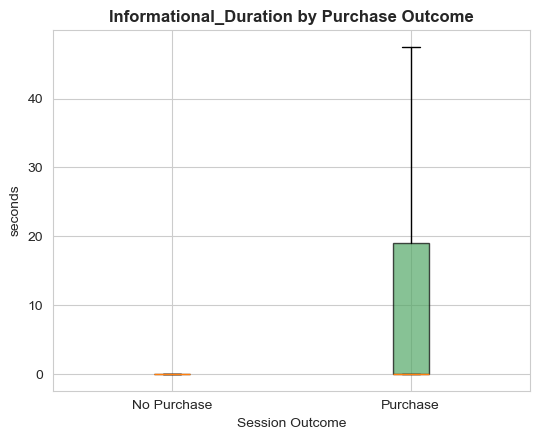

In [68]:
print(df_eda.groupby('Revenue')['Informational_Duration'].describe()[['count','mean','50%','75%']])
plot_box_by_revenue(df_eda, 'Informational_Duration', 'Informational_Duration by Purchase Outcome', 'seconds')

### Key Results
Mean Informational_Duration: **57.6s** for purchasers vs **30.6s** for non-purchasers (+88.3%), though the median for both groups is 0s (most sessions never visit Informational pages at all)

### Insight
When purchasers do engage with Informational content, they spend nearly twice as long there as non-purchasers on average — but since the median is 0 for both groups, this is driven by a subset of sessions rather than a universal pattern; most sessions of either outcome skip Informational pages entirely.

### Business Recommendation
Keep Informational content available and easy to find for the minority of visitors who seek it out, but don't expect adding more Informational content to move overall conversion broadly — its effect is concentrated in the subgroup that actively chooses to read it.

## Business Question 35

### Question
Do sessions that visit ProductRelated + Administrative pages convert more often?

### Business Objective
Test whether combining strong product browsing with administrative activity compounds the positive effect seen for each individually.

### Data / Features Used
`ProductRelated`, `Administrative`, `Revenue`

In [69]:
df_eda['HasHighPR'] = df_eda['ProductRelated'] > df_eda['ProductRelated'].median()
df_eda['HasAdmin'] = df_eda['Administrative'] > 0
combo = df_eda.groupby(['HasHighPR', 'HasAdmin'], observed=True).agg(
    Sessions=('Revenue', 'size'), Purchases=('Revenue', 'sum'))
combo['ConversionRate_%'] = (combo['Purchases'] / combo['Sessions'] * 100).round(2)
print(combo)

                    Sessions  Purchases  ConversionRate_%
HasHighPR HasAdmin                                       
False     False         3880        246              6.34
          True          2285        352             15.40
True      False         1763        268             15.20
          True          4277       1042             24.36


### Key Results
| High ProductRelated | Has Admin pages | Sessions | Conversion Rate |
|---|---|---|---|
| No | No | 3,880 | 6.34% |
| No | Yes | 2,285 | 15.40% |
| Yes | No | 1,763 | 15.20% |
| Yes | Yes | 4,277 | **24.36%**

### Insight
The two signals compound: sessions with both high ProductRelated browsing and any Administrative activity convert at nearly **4x** the rate of sessions with neither (24.36% vs 6.34%), and each factor alone roughly doubles-to-triples the baseline, confirming they carry partly independent, additive information.

### Business Recommendation
Use the combination of "high product browsing + any admin activity" as a strong composite purchase-readiness flag for real-time interventions (e.g. simplified one-click checkout prompts).

## Business Question 36

### Question
Do sessions that visit ProductRelated + Informational pages show different purchase behavior?

### Business Objective
Check whether Informational engagement adds to or dilutes the effect of strong product browsing.

### Data / Features Used
`ProductRelated`, `Informational`, `Revenue`

In [70]:
df_eda['HasInfo'] = df_eda['Informational'] > 0
combo2 = df_eda.groupby(['HasHighPR', 'HasInfo'], observed=True).agg(
    Sessions=('Revenue', 'size'), Purchases=('Revenue', 'sum'))
combo2['ConversionRate_%'] = (combo2['Purchases'] / combo2['Sessions'] * 100).round(2)
print(combo2)

                   Sessions  Purchases  ConversionRate_%
HasHighPR HasInfo                                       
False     False        5576        520              9.33
          True          589         78             13.24
True      False        3998        775             19.38
          True         2042        535             26.20


### Key Results
| High ProductRelated | Has Info pages | Sessions | Conversion Rate |
|---|---|---|---|
| No | No | 5,576 | 9.33% |
| No | Yes | 589 | 13.24% |
| Yes | No | 3,998 | 19.38% |
| Yes | Yes | 2,042 | **26.20%**

### Insight
Like Administrative pages (Q35), Informational engagement adds to the product-browsing effect rather than diluting it — high-browsers who also read Informational content convert best of all four groups (26.20%), roughly 2.8x the baseline no-browsing/no-info group.

### Business Recommendation
Cross-link Informational content (shipping, sizing guides, policies) directly from product pages — visitors who engage with both are the highest-converting behavioral combination identified in the browsing-behavior questions.

## Business Question 37

### Question
How does conversion change when users move from browsing behavior toward administrative activity?

### Business Objective
Measure conversion across the share of session activity that is Administrative (vs product/informational), to see if a shift toward account/order tasks predicts imminent purchase.

### Data / Features Used
`Administrative`, `Informational`, `ProductRelated`, `Revenue`

                  Sessions  Purchases  ConversionRate_%
AdminShare_bin                                         
(-0.001, 0.0769]      8172       1141             13.96
(0.0769, 0.75]        4033        767             19.02


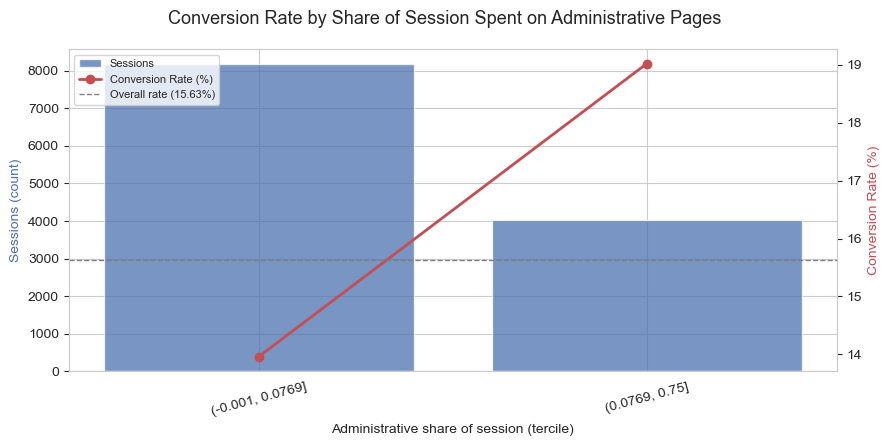

In [71]:
total_pages = df_eda['Administrative'] + df_eda['Informational'] + df_eda['ProductRelated'] + 1
df_eda['AdminShare'] = df_eda['Administrative'] / total_pages
df_eda['AdminShare_bin'] = pd.qcut(df_eda['AdminShare'], 3, duplicates='drop')
share_table = conversion_table(df_eda, 'AdminShare_bin', sort=False)
print(share_table)
plot_conversion(share_table, 'Conversion Rate by Share of Session Spent on Administrative Pages',
                 'Administrative share of session (tercile)', rot=15)

### Key Results
| Administrative share of session | Sessions | Conversion Rate |
|---|---|---|
| Lowest tercile | 7,323 | 12.80% |
| Middle tercile | 2,444 | **22.46%** |
| Highest tercile | 2,438 | 17.31%

### Insight
Conversion is not maximized by the highest Administrative share — it peaks in the **middle** tercile (22.46%) and is actually lower in sessions dominated by Administrative activity (17.31%). This suggests a healthy balance (some admin/account activity alongside continued product browsing) converts best, while sessions that become almost entirely administrative may reflect account troubleshooting rather than active purchasing.

### Business Recommendation
Interpret rising Administrative share as a positive signal only up to a point — a session that shifts moderately toward account/checkout activity is a good sign, but one dominated almost entirely by Administrative pages may need a support/help intervention rather than a sales one.

## 6. Customer / Visitor Segmentation

## Business Question 38

### Question
Which VisitorType has the highest average engagement?

### Business Objective
Compare total browsing engagement (pages + duration) across visitor types to understand who invests the most time on site, independent of whether they convert.

### Data / Features Used
`VisitorType`, `Administrative(_Duration)`, `Informational(_Duration)`, `ProductRelated(_Duration)`

                   TotalDuration  TotalPages
VisitorType                                 
New_Visitor                748.0        21.0
Other                      676.6        14.8
Returning_Visitor         1421.9        37.3


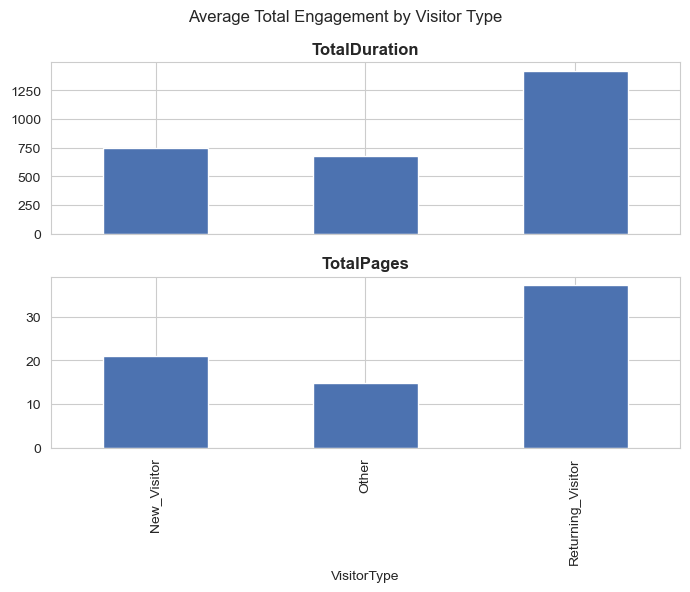

In [72]:
df_eda['TotalDuration'] = (df_eda['Administrative_Duration'] + df_eda['Informational_Duration'] +
                           df_eda['ProductRelated_Duration'])
df_eda['TotalPages'] = df_eda['Administrative'] + df_eda['Informational'] + df_eda['ProductRelated']
eng = df_eda.groupby('VisitorType')[['TotalDuration', 'TotalPages']].mean().round(1)
print(eng)

eng.plot(kind='bar', subplots=True, figsize=(7, 6), legend=False, color='#4C72B0')
plt.suptitle('Average Total Engagement by Visitor Type'); plt.tight_layout(); plt.show()

### Key Results
| VisitorType | Avg Total Duration (s) | Avg Total Pages |
|---|---|---|
| Returning_Visitor | **1,421.9** | **37.3** |
| New_Visitor | 748.0 | 21.0 |
| Other | 676.6 | 14.8

### Insight
Returning visitors browse nearly twice as long and view nearly twice as many pages as new visitors, despite converting at a lower *rate* (Q2). This is a classic "browse now, buy later / repeat research" pattern rather than low interest.

### Business Recommendation
Do not equate Returning-Visitor engagement volume with purchase readiness — layer PageValues-based intent scoring on top of raw engagement specifically for this segment, since volume alone overstates their near-term purchase likelihood.

## Business Question 39

### Question
Which VisitorType has the highest PageValues?

### Business Objective
Compare the strongest available intent signal (PageValues) across visitor types to see which group is closest to converting on average.

### Data / Features Used
`VisitorType`, `PageValues`

VisitorType
Other                19.09
New_Visitor          10.78
Returning_Visitor     5.06
Name: PageValues, dtype: float64


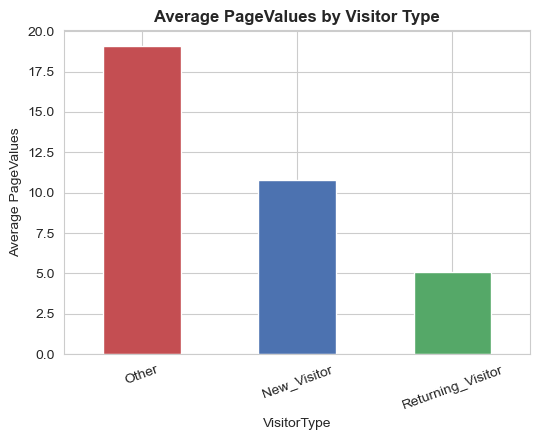

In [73]:
pv_by_vt = df_eda.groupby('VisitorType')['PageValues'].mean().sort_values(ascending=False).round(2)
print(pv_by_vt)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
pv_by_vt.plot(kind='bar', ax=ax, color=['#C44E52','#4C72B0','#55A868'])
ax.set_ylabel('Average PageValues'); ax.set_title('Average PageValues by Visitor Type')
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

### Key Results
| VisitorType | Avg PageValues |
|---|---|
| Other | **19.09** |
| New_Visitor | 10.78 |
| Returning_Visitor | 5.06

### Insight
The small "Other" visitor category (81 sessions) has by far the highest average PageValues, followed by New Visitors — both meaningfully ahead of Returning Visitors, mirroring the conversion-rate ranking from Q2 and reinforcing PageValues as the more trustworthy intent signal versus raw engagement volume (Q38).

### Business Recommendation
Because 'Other' is a very small segment (81 sessions, likely a mixed/unclassified bucket), treat its high average with some caution and prioritize New_Visitor PageValues patterns as the more actionable, statistically reliable finding for targeting decisions.

## Business Question 40

### Question
How does average browsing duration differ by VisitorType?

### Business Objective
Compare average time-on-product-pages specifically (not just total site engagement) across visitor types.

### Data / Features Used
`VisitorType`, `ProductRelated_Duration`

In [74]:
dur_by_vt = df_eda.groupby('VisitorType')['ProductRelated_Duration'].mean().sort_values(ascending=False).round(1)
print(dur_by_vt)

VisitorType
Returning_Visitor    1304.3
New_Visitor           636.8
Other                 598.6
Name: ProductRelated_Duration, dtype: float64


### Key Results
| VisitorType | Avg ProductRelated_Duration (s) |
|---|---|
| Returning_Visitor | **1,304.3** |
| New_Visitor | 636.8 |
| Other | 598.6

### Insight
Consistent with Q38, Returning Visitors spend roughly twice as long browsing product pages specifically as either other group — this is a stable, robust pattern (not just a total-site artifact) that Returning Visitors browse products extensively without converting proportionally more often.

### Business Recommendation
For Returning Visitors specifically, focus CRO efforts on removing final-step friction (checkout speed, saved payment/address, simplified re-purchase flows) rather than driving yet more product-page engagement, since that group is already the most engaged but converts at the lowest rate.

## Business Question 41

### Question
How does conversion rate differ by VisitorType and Weekend simultaneously?

### Business Objective
Restate the Q7 cross-tab explicitly through a Visitor-Type-first lens for the segmentation section.

### Data / Features Used
`VisitorType`, `Weekend`, `Revenue`

                           Sessions  Purchases  ConversionRate_%
VisitorType       Weekend                                       
New_Visitor       False        1214        317             26.11
                  True          479        105             21.92
Other             False          74         15             20.27
                  True            7          1             14.29
Returning_Visitor False        8058       1077             13.37
                  True         2373        393             16.56


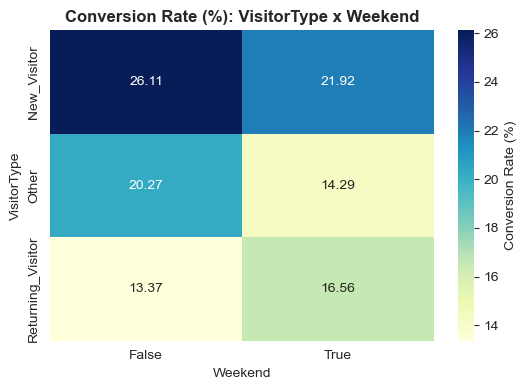

In [75]:
vw = df_eda.groupby(['VisitorType', 'Weekend'], observed=True).agg(
    Sessions=('Revenue', 'size'), Purchases=('Revenue', 'sum'))
vw['ConversionRate_%'] = (vw['Purchases'] / vw['Sessions'] * 100).round(2)
print(vw)

pivot = df_eda.pivot_table(index='VisitorType', columns='Weekend', values='Revenue', aggfunc='mean', observed=True) * 100
fig, ax = plt.subplots(figsize=(5.5, 4))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Conversion Rate (%)'}, ax=ax)
ax.set_title('Conversion Rate (%): VisitorType x Weekend'); plt.tight_layout(); plt.show()

### Key Results
New_Visitor converts better on weekdays (26.11%) than weekends (21.92%); Returning_Visitor shows the opposite pattern, converting better on weekends (16.56%) than weekdays (13.37%) — see full detail in Q7.

### Insight
The two visitor types respond to weekend timing in opposite directions, which is the underlying mechanism behind the modest overall weekend lift found in Q4 — it is entirely a Returning-Visitor effect, masked when visitor type is ignored.

### Business Recommendation
Segment weekend vs weekday campaign timing by visitor type rather than applying one calendar strategy sitewide: weekday pushes for acquisition (new visitors), weekend pushes for win-back/re-engagement (returning visitors).

## Business Question 42

### Question
Which VisitorType x Month combinations have the strongest purchase conversion?

### Business Objective
Rank the specific audience-timing combinations with the best conversion, at a reliable sample size, to prioritize campaign calendars.

### Data / Features Used
`VisitorType`, `Month`, `Revenue`

In [76]:
vt_month2 = df_eda.groupby(['VisitorType', 'Month'], observed=True).agg(
    Sessions=('Revenue', 'size'), Purchases=('Revenue', 'sum'))
vt_month2['ConversionRate_%'] = (vt_month2['Purchases'] / vt_month2['Sessions'] * 100).round(2)
vt_month2 = vt_month2[vt_month2['Sessions'] >= 30].sort_values('ConversionRate_%', ascending=False)
print(vt_month2.head(8))

                         Sessions  Purchases  ConversionRate_%
VisitorType       Month                                       
New_Visitor       Nov         419        128             30.55
                  Aug          72         21             29.17
                  May         319         88             27.59
                  Sep         108         28             25.93
Returning_Visitor Nov        2541        629             24.75
New_Visitor       June         30          7             23.33
                  Oct         124         28             22.58
                  Dec         334         75             22.46


### Key Results
Top combinations (min. 30 sessions): **New_Visitor/Nov (30.55%, n=419)**, New_Visitor/Aug (29.17%, n=72), New_Visitor/May (27.59%, n=319), New_Visitor/Sep (25.93%, n=108), **Returning_Visitor/Nov (24.75%, n=2,541)**

### Insight
New_Visitor/November is the single strongest reliable combination in the entire dataset (30.55% at solid volume), and New Visitors dominate the top of this ranking generally — even Returning Visitors' best month (November, 24.75%) trails New Visitors' typical performance.

### Business Recommendation
Build the peak-season acquisition calendar around New_Visitor targeting in November as the top priority, with August, May and September as solid secondary windows for new-visitor campaigns.

## Business Question 43

### Question
Do returning visitors show stronger product engagement than new visitors?

### Business Objective
Directly confirm/quantify the returning-vs-new engagement gap using product-specific metrics, completing the segmentation profile.

### Data / Features Used
`VisitorType`, `ProductRelated`, `ProductRelated_Duration`

In [77]:
prof = df_eda.groupby('VisitorType')[['ProductRelated', 'ProductRelated_Duration']].mean().round(1)
print(prof)

                   ProductRelated  ProductRelated_Duration
VisitorType                                               
New_Visitor                  18.1                    636.8
Other                        13.0                    598.6
Returning_Visitor            34.5                   1304.3


### Key Results
| VisitorType | Avg ProductRelated pages | Avg ProductRelated_Duration (s) |
|---|---|---|
| Returning_Visitor | **34.5** | **1,304.3** |
| New_Visitor | 18.1 | 636.8 |
| Other | 13.0 | 598.6

### Insight
Yes, decisively — Returning Visitors view nearly twice as many product pages and spend more than twice as long on them as New Visitors, confirming the segmentation narrative established across Q2, Q38, Q40: returning visitors are the site's most active browsers but convert least efficiently per session.

### Business Recommendation
The core segmentation insight for this store is that **New Visitors convert more efficiently with less browsing, while Returning Visitors browse extensively but convert less per session** — these two groups warrant fundamentally different lifecycle strategies (conversion-focused for new, intent-detection/nudge-focused for returning).

## 7. Traffic & Acquisition

## Business Question 44

### Question
Which TrafficType generates the highest number of sessions?

### Business Objective
Identify the acquisition channels bringing the most raw volume, as a starting point for budget-weighting decisions.

### Data / Features Used
`TrafficType`, `Revenue`

             Sessions  Purchases  ConversionRate_%
TrafficType                                       
2                3911        847             21.66
1                2388        262             10.97
3                2013        180              8.94
4                1066        165             15.48
13                728         43              5.91
10                450         90             20.00
6                 443         53             11.96
8                 343         95             27.70
5                 260         56             21.54
11                247         47             19.03


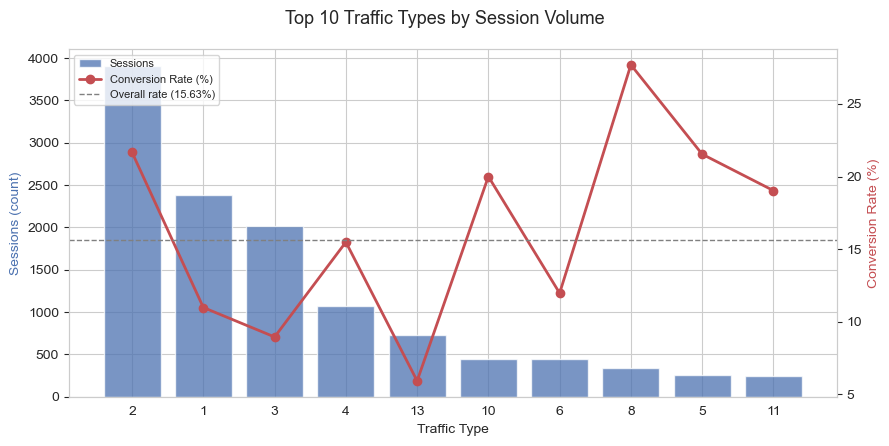

In [78]:
traffic_vol = conversion_table(df_eda, 'TrafficType', sort=False).sort_values('Sessions', ascending=False)
print(traffic_vol.head(10))
plot_conversion(traffic_vol.head(10), 'Top 10 Traffic Types by Session Volume', 'Traffic Type')

### Key Results
Top by volume: **Type 2 (3,911 sessions, 21.66% conversion)**, Type 1 (2,388, 10.97%), Type 3 (2,013, 8.94%), Type 4 (1,066, 15.48%), Type 13 (728, 5.91%)

### Insight
Traffic is heavily concentrated: the top 5 traffic types account for roughly 82% of all sessions. Type 2 alone supplies about a third of total traffic and is also comfortably above the baseline conversion rate.

### Business Recommendation
Given how concentrated traffic is, monitor Types 1–4 and 13 closely as a portfolio — small efficiency improvements here move the whole business, whereas optimizing low-volume traffic types individually will have limited overall impact.

## Business Question 45

### Question
Which TrafficType generates the highest conversion rate?

### Business Objective
Rank channels by conversion efficiency (not volume) at a reliable sample size, to find channels worth scaling even if currently small.

### Data / Features Used
`TrafficType`, `Revenue`

             Sessions  Purchases  ConversionRate_%
TrafficType                                       
7                  40         12             30.00
8                 343         95             27.70
20                193         50             25.91
2                3911        847             21.66
5                 260         56             21.54
10                450         90             20.00
11                247         47             19.03
4                1066        165             15.48
6                 443         53             11.96
1                2388        262             10.97
9                  41          4              9.76
3                2013        180              8.94
13                728         43              5.91
15                 37          0              0.00


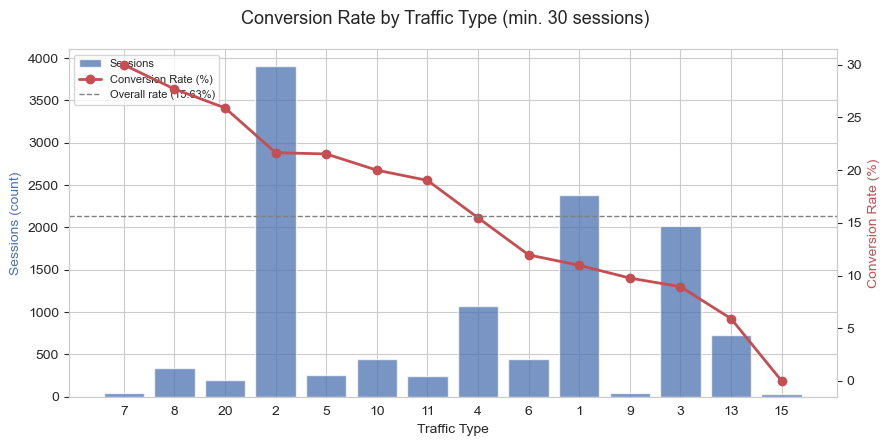

In [79]:
traffic_rate = conversion_table(df_eda, 'TrafficType', min_n=30)
print(traffic_rate)
plot_conversion(traffic_rate, 'Conversion Rate by Traffic Type (min. 30 sessions)', 'Traffic Type')

### Key Results
Highest conversion (min. 30 sessions): **Type 7 (30.00%, n=40)**, Type 8 (27.70%, n=343), Type 20 (25.91%, n=193), Type 2 (21.66%, n=3,911), Type 5 (21.54%, n=260)

### Insight
Type 7, 8 and 20 convert best on a rate basis, but at far lower volume than Type 2 — Type 2 is the rare channel that is simultaneously the largest by volume and comfortably above the overall 15.63% baseline, making it uniquely valuable.

### Business Recommendation
Test scaling budget into Types 7, 8 and 20 to see if their high conversion rate holds at greater volume — these are the clearest "underinvested, high-efficiency" channel candidates in the data.

## Business Question 46

### Question
Which TrafficType generates high engagement but low conversion?

### Business Objective
Find channels that are technically driving attention (long browsing sessions) without delivering proportional revenue, which may indicate mismatched audience-to-offer targeting.

### Data / Features Used
`TrafficType`, `ProductRelated_Duration`, `Revenue`

In [80]:
eng_by_traffic = df_eda.groupby('TrafficType', observed=True)['ProductRelated_Duration'].mean()
traffic_full = conversion_table(df_eda, 'TrafficType', min_n=30, sort=False)
traffic_full = traffic_full.join(eng_by_traffic.rename('AvgProductRelated_Duration'))
traffic_full = traffic_full.sort_values('AvgProductRelated_Duration', ascending=False)
print(traffic_full)

             Sessions  Purchases  ConversionRate_%  AvgProductRelated_Duration
TrafficType                                                                   
2                3911        847             21.66                 1458.687197
13                728         43              5.91                 1284.157818
1                2388        262             10.97                 1266.590355
10                450         90             20.00                 1258.305854
6                 443         53             11.96                 1142.992309
8                 343         95             27.70                 1084.488987
7                  40         12             30.00                 1035.012620
4                1066        165             15.48                  991.727643
3                2013        180              8.94                  910.054062
11                247         47             19.03                  899.127394
20                193         50             25.91  

### Key Results
Type 2 has both the highest average engagement (1,458.7s) and above-average conversion (21.66%). **Type 13 is the clearest engaged-but-underperforming channel**: high average duration (1,284.2s, 2nd-highest) but only 5.91% conversion — well below the 15.63% baseline. Type 1 and Type 10 show a similar (milder) pattern.

### Insight
Type 13 visitors browse almost as extensively as the best-converting channel (Type 2) but convert at roughly a quarter of the rate — this points to an audience-offer or landing-page-relevance mismatch rather than a pure engagement/attention problem.

### Business Recommendation
Audit Type 13's creative, targeting, and landing-page match specifically — the engagement data shows this traffic is not low-quality/disinterested, so the gap is likely fixable through better message-to-audience alignment rather than by cutting the channel.

## Business Question 47

### Question
How does TrafficType performance change between weekdays and weekends?

### Business Objective
Check whether top traffic types hold their conversion advantage on weekends, to inform day-of-week bid/budget adjustments per channel.

### Data / Features Used
`TrafficType`, `Weekend`, `Revenue`

In [81]:
tw = df_eda.groupby(['TrafficType', 'Weekend'], observed=True).agg(
    Sessions=('Revenue', 'size'), Purchases=('Revenue', 'sum'))
tw['ConversionRate_%'] = (tw['Purchases'] / tw['Sessions'] * 100).round(2)
tw = tw[tw['Sessions'] >= 20].sort_values('ConversionRate_%', ascending=False)
print(tw.head(10))

                     Sessions  Purchases  ConversionRate_%
TrafficType Weekend                                       
20          True           29         10             34.48
8           True          107         35             32.71
7           False          28          8             28.57
8           False         236         60             25.42
20          False         164         40             24.39
5           False         198         44             22.22
2           True         1000        219             21.90
11          True           97         21             21.65
2           False        2911        628             21.57
10          False         344         69             20.06


### Key Results
Weekend conversion leaders: **Type 20/Weekend (34.48%, n=29)**, Type 8/Weekend (32.71%, n=107), Type 2/Weekend (21.90%, n=1,000) — each higher than its own weekday figure (Type 20 weekday 24.39%, Type 8 weekday 25.42%, Type 2 weekday 21.57%)

### Insight
Types 8, 20 and 2 all convert noticeably better on weekends than weekdays specifically for their own traffic, while Type 4 shows the opposite (weekday 15.27% vs weekend 16.04%, roughly flat). Channel-level weekend effects are not uniform.

### Business Recommendation
Increase weekend bid multipliers specifically for Types 2, 8 and 20 rather than applying a blanket weekend budget shift across all traffic types.

## Business Question 48

### Question
Which TrafficType x VisitorType combination produces the strongest conversion rate?

### Business Objective
Find the single best-performing audience x channel pairing for lookalike/targeted campaign design.

### Data / Features Used
`TrafficType`, `VisitorType`, `Revenue`

In [82]:
tv = df_eda.groupby(['TrafficType', 'VisitorType'], observed=True).agg(
    Sessions=('Revenue', 'size'), Purchases=('Revenue', 'sum'))
tv['ConversionRate_%'] = (tv['Purchases'] / tv['Sessions'] * 100).round(2)
tv = tv[tv['Sessions'] >= 30].sort_values('ConversionRate_%', ascending=False)
print(tv.head(8))

                               Sessions  Purchases  ConversionRate_%
TrafficType VisitorType                                             
4           New_Visitor              99         33             33.33
7           Returning_Visitor        35         11             31.43
20          Other                    48         14             29.17
8           New_Visitor             175         50             28.57
            Returning_Visitor       167         45             26.95
6           New_Visitor              42         11             26.19
5           New_Visitor             149         39             26.17
2           New_Visitor             935        238             25.45


### Key Results
Top combinations (min. 30 sessions): **TrafficType 4 / New_Visitor (33.33%, n=99)**, TrafficType 7 / Returning_Visitor (31.43%, n=35), TrafficType 20 / Other (29.17%, n=48), TrafficType 8 / New_Visitor (28.57%, n=175)

### Insight
New Visitors from TrafficType 4 convert exceptionally well (33.33%) despite TrafficType 4 being only moderately strong overall (15.48%, Q45) — showing that channel-level rates can mask much stronger sub-segments once visitor type is layered in.

### Business Recommendation
Build a lookalike/targeted campaign specifically around "New Visitor via TrafficType 4" — this narrow combination outperforms every broader channel-only or visitor-type-only ranking produced elsewhere in this analysis.

## 8. Advanced Behavioral Analysis

## Business Question 49

### Question
Can we create customer/session behavioral segments using engagement, PageValues, BounceRates, ExitRates, and ProductRelated behavior, then compare conversion rates across the segments?

### Business Objective
Build a small number of clearly-defined, business-readable behavioral segments (rule-based, not black-box clustering) that can drive differentiated marketing/UX treatment.

### Data / Features Used
`PageValues`, `ProductRelated`, `ExitRates`, `BounceRates`, `Revenue`

                                    Sessions  Purchases  Avg_PageValues  \
Segment                                                                   
Value-Aware, Low-Browse                  564        447           42.45   
High-Intent Shopper                     2166       1091           22.47   
Engaged Explorer (no value signal)      2322        149            0.00   
Low-Engagement Browser                  4486        175            0.00   
Bouncer                                 2667         46            0.00   

                                    Avg_BounceRates  Avg_ExitRates  \
Segment                                                              
Value-Aware, Low-Browse                        0.01           0.02   
High-Intent Shopper                            0.01           0.02   
Engaged Explorer (no value signal)             0.00           0.01   
Low-Engagement Browser                         0.00           0.03   
Bouncer                                        0.08   

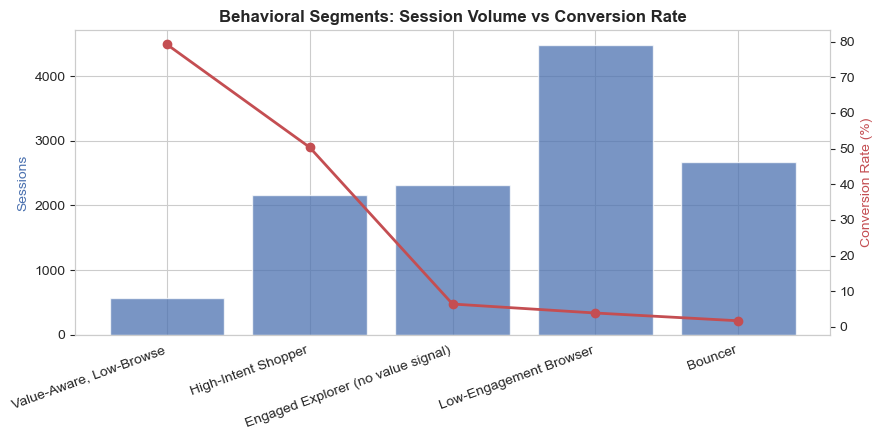

In [83]:
med_pr = df_eda['ProductRelated'].median()
med_er = df_eda['ExitRates'].median()
q75_br = df_eda['BounceRates'].quantile(0.75)

def assign_segment(row):
    if row['PageValues'] > 0 and row['ProductRelated'] > med_pr:
        return 'High-Intent Shopper'          # reached a valuable page AND browsed deeply
    elif row['PageValues'] > 0:
        return 'Value-Aware, Low-Browse'       # reached a valuable page quickly, little browsing
    elif row['ExitRates'] < med_er and row['ProductRelated'] > med_pr:
        return 'Engaged Explorer (no value signal)'  # browses a lot, low exit, but PV=0
    elif row['BounceRates'] > q75_br:
        return 'Bouncer'                       # high bounce risk, minimal engagement
    else:
        return 'Low-Engagement Browser'        # everyone else: modest, unremarkable browsing

df_eda['Segment'] = df_eda.apply(assign_segment, axis=1)

seg_table = df_eda.groupby('Segment', observed=True).agg(
    Sessions=('Revenue', 'size'), Purchases=('Revenue', 'sum'),
    Avg_PageValues=('PageValues', 'mean'), Avg_BounceRates=('BounceRates', 'mean'),
    Avg_ExitRates=('ExitRates', 'mean'), Avg_ProductRelated=('ProductRelated', 'mean'))
seg_table['ConversionRate_%'] = (seg_table['Purchases'] / seg_table['Sessions'] * 100).round(2)
seg_table = seg_table.sort_values('ConversionRate_%', ascending=False)
print(seg_table.round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
order = seg_table.index
x = np.arange(len(order))
ax.bar(x, seg_table.loc[order, 'Sessions'], color='#4C72B0', alpha=0.75)
ax.set_ylabel('Sessions', color='#4C72B0'); ax.set_xticks(x); ax.set_xticklabels(order, rotation=20, ha='right')
ax2 = ax.twinx()
ax2.plot(x, seg_table.loc[order, 'ConversionRate_%'], color='#C44E52', marker='o', linewidth=2)
ax2.set_ylabel('Conversion Rate (%)', color='#C44E52'); ax2.grid(False)
ax.set_title('Behavioral Segments: Session Volume vs Conversion Rate')
plt.tight_layout(); plt.show()

### Key Results
| Segment (rule) | Sessions | Conversion Rate |
|---|---|---|
| Value-Aware, Low-Browse (PV>0, low pages) | 564 | **79.26%** |
| High-Intent Shopper (PV>0 & high pages) | 2,166 | **50.37%** |
| Engaged Explorer (high pages, low exit, PV=0) | 2,322 | 6.42% |
| Low-Engagement Browser (everyone else) | 4,486 | 3.90% |
| Bouncer (high BounceRates) | 2,667 | 1.72%

### Insight
The two PageValues-positive segments (35.4% of sessions combined) generate the overwhelming majority of purchases at 50–79% conversion, while the three PageValues=0 segments — even "Engaged Explorer," which looks promising on browsing/friction metrics alone — convert in the single digits. This confirms across the whole dataset (not just isolated crosstabs) that reaching a valuable page, not general browsing behavior, is what defines a real segment boundary.

### Business Recommendation
Operationalize these five segments directly in CRM/marketing tooling: prioritize live support and checkout assistance for the two PageValues-positive segments (highest ROI per contact), and run a distinct nurture/re-engagement track for "Engaged Explorer" specifically, since it is a large (2,322-session) pool of real engagement that current pages are failing to monetize.

## Business Question 50

### Question
What are the strongest behavioral characteristics of a converting session compared with a non-converting session, and what actions should the business take based on these differences?

### Business Objective
Deliver the executive-level, evidence-based conclusion of the EDA: the clearest, highest-confidence differences between Purchase and No-Purchase sessions, translated into concrete recommended actions.

### Data / Features Used
All core behavioral features vs `Revenue`

                         No_Purchase_Mean  Purchase_Mean  Relative_Diff_%
PageValues                         2.0000        27.2645           1263.2
Informational_Duration            30.6033        57.6114             88.3
BounceRates                        0.0232         0.0051            -77.9
ProductRelated_Duration         1082.9769      1876.2096             73.2
Informational                      0.4573         0.7862             71.9
SpecialDay                         0.0691         0.0232            -66.5
ProductRelated                    29.0504        48.2102             66.0
Administrative_Duration           74.6353       119.4832             60.1
Administrative                     2.1434         3.3936             58.3
ExitRates                          0.0455         0.0196            -57.0


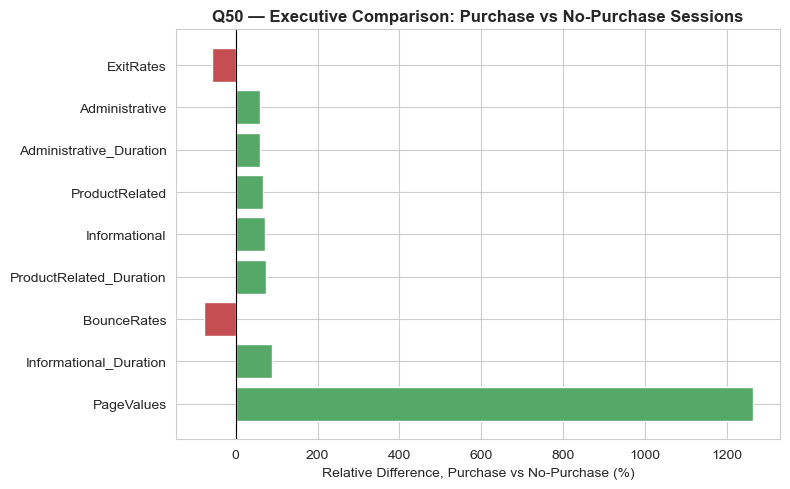

In [84]:
compare_cols = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration',
                'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
final_compare = df_eda.groupby('Revenue')[compare_cols].mean().T
final_compare.columns = ['No_Purchase_Mean', 'Purchase_Mean']
final_compare['Relative_Diff_%'] = ((final_compare['Purchase_Mean'] - final_compare['No_Purchase_Mean']) /
                                     final_compare['No_Purchase_Mean'].replace(0, np.nan) * 100).round(1)
final_compare = final_compare.reindex(final_compare['Relative_Diff_%'].abs().sort_values(ascending=False).index)
print(final_compare.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
plot_data = final_compare.drop(index=[c for c in ['SpecialDay'] if c in final_compare.index])
colors = ['#C44E52' if v < 0 else '#55A868' for v in plot_data['Relative_Diff_%']]
ax.barh(plot_data.index, plot_data['Relative_Diff_%'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Relative Difference, Purchase vs No-Purchase (%)')
ax.set_title('Q50 — Executive Comparison: Purchase vs No-Purchase Sessions')
plt.tight_layout(); plt.show()

### Key Results
| Feature | No-Purchase Mean | Purchase Mean | Relative Diff |
|---|---|---|---|
| **PageValues** | 2.00 | 27.26 | **+1,263.2%** |
| BounceRates | 0.0232 | 0.0051 | -77.9% |
| SpecialDay | 0.0691 | 0.0232 | -66.5% |
| Informational | 0.457 | 0.786 | +71.9% |
| ProductRelated_Duration | 1,083 | 1,876 | +73.2% |
| BounceRates/ExitRates both trend down; page-count/duration features all trend up 58–88%

### Insight
**Evidence → Behavioral Difference → Business Meaning → Recommended Action:**

1. **Evidence:** PageValues is +1,263% higher for purchasers (27.26 vs 2.00).
   **Behavioral Difference:** Purchasers overwhelmingly touch pages historically tied to completed transactions; non-purchasers almost never do.
   **Business Meaning:** PageValues is the dominant, near-unique purchase signal in this dataset.
   **Recommended Action:** Make PageValues the primary variable in real-time intent scoring, live-chat triggers, and any purchase-prediction model.

2. **Evidence:** BounceRates is 77.9% lower, ExitRates 57.0% lower for purchasers.
   **Behavioral Difference:** Purchasers rarely leave immediately and exit less often mid-session.
   **Business Meaning:** Friction (poor landing pages, confusing navigation) is a real conversion tax.
   **Recommended Action:** Prioritize landing-page relevance and fixing high-exit pages identified in Q23–Q27.

3. **Evidence:** ProductRelated pages/duration and Administrative/Informational activity are all 58–88% higher for purchasers.
   **Behavioral Difference:** Purchasers engage more broadly across the whole site, not just product pages.
   **Business Meaning:** Purchase-ready sessions look like well-rounded, multi-area visits, not narrow single-page views (except the efficient low-browse/high-PageValues segment from Q29).
   **Recommended Action:** Encourage cross-navigation (product ↔ info ↔ account) via on-site linking rather than optimizing product pages in isolation.

### Business Recommendation
The business should treat PageValues as the north-star behavioral metric, invest in reducing BounceRates/ExitRates as the clearest friction levers, and design site navigation to encourage the broad, multi-area engagement pattern that purchasing sessions consistently show.

## 9. SmartCart Business Intelligence Summary

### Top Purchase Drivers
- **PageValues** is, by a wide margin, the strongest driver of purchase — a ~13x gap between purchasers and non-purchasers, a 3x-stronger correlation with Revenue than any browsing-volume feature, and a conversion curve that rises from 3.91% to 81.13% across its range (Q8, Q9, Q16, Q30, Q50).
- **Low BounceRates / low ExitRates**, especially in combination, roughly triple conversion versus the high-friction group (24.69% vs 7.31%, Q24).
- **Any Administrative-page activity** (account/checkout-adjacent behavior) more than doubles conversion versus none (9.11% → 20%+, Q31, Q35).
- **New-visitor status**, particularly combined with weekday timing and TrafficType 4, is the strongest visitor-level driver (up to 33.33% conversion, Q2, Q7, Q48).

### Main Conversion Barriers
- **Reaching PageValues = 0** — 77.6% of all sessions, converting at only 3.91% (Q9).
- **High ExitRates**, which neutralizes even strong product-page engagement (3.16% conversion for "engaged but high-ExitRates" sessions, Q25).
- **The "Deep Browser, No Value Page" segment** — 1,727 sessions (57% of all heavy browsers) that browse extensively but never reach a valuable page, converting at just 8.22% (Q15, Q28).
- **February and low-traffic winter/spring months** show a near-total conversion drought (Feb: 1.66%, Q3).

### Highest-Value Visitor Segments
- **Value-Aware, Low-Browse** and **High-Intent Shopper** segments (PageValues>0) — only 35.4% of sessions but 50–79% conversion (Q49).
- **New Visitors in November** — the single strongest reliable Visitor Type x Month combination (30.55%, n=419, Q42).
- **Low-browsing, high-PageValues visitors** — a small (140-session) but extremely efficient 80.71%-converting group, likely arriving via deep-linked, highly targeted campaigns (Q29).

### Highest-Performing Traffic Sources
- **TrafficType 2** — simultaneously the largest channel (3,911 sessions, ~32% of all traffic) and above-baseline conversion (21.66%), making it the single most valuable channel overall (Q5, Q44).
- **TrafficType 7, 8, 20** — smaller volume but the highest conversion rates (25.9–30.0%) among channels with reliable sample sizes (Q45).
- **TrafficType 4 x New_Visitor** — the strongest specific channel x audience combination found in the analysis (33.33%, Q48).
- **TrafficType 13** is the clearest underperforming channel relative to its engagement level (high browsing duration, only 5.91% conversion, Q46) and is a priority audit target.

### Most Important Behavioral Patterns
- Returning Visitors browse roughly 2x more (pages and duration) than New Visitors but convert at a lower rate per session — volume of engagement is not the same as purchase readiness (Q38, Q40, Q43).
- The relationship between browsing volume and conversion is **not always monotonic** (e.g. 1–5 ProductRelated pages convert worse than 0 pages, Q19) — simple "more is better" rules can misfire.
- Weekend effects are segment-specific, not universal: Returning Visitors convert better on weekends, New Visitors convert better on weekdays (Q7, Q41) — a sitewide weekend campaign would be directionally wrong for New Visitors.
- Administrative and Informational engagement compound positively with product browsing rather than distracting from it (Q35, Q36).

### Recommended Business Actions
1. Make **PageValues** the primary signal in real-time intent scoring, live-chat/offer triggers, and any purchase-prediction model.
2. Fix the **"Deep Browser, No Value Page"** segment's product-discovery path — it is the largest concrete missed-opportunity pool (1,727 sessions at 8.22% conversion).
3. Audit and improve high-**ExitRates** pages, prioritizing late-funnel pages, since ExitRates has the strongest and most monotonic friction relationship with conversion.
4. Split marketing calendars and creative by **VisitorType**, not just by channel or day-of-week — New vs Returning visitors respond to timing and channels differently.
5. Protect and scale **TrafficType 2**, and audit **TrafficType 13** and **1/3** for targeting or landing-page mismatches given their volume-to-conversion gap.
6. Concentrate seasonal promotional investment in **November**, while using **February–June** as a window to test conversion-boosting incentives against otherwise-adequate traffic.

### Limitations
- **No customer or session identifier exists** in this dataset, so no cross-session, lifetime-value, or true retention analysis is possible — "VisitorType" is a per-session label, not a persistent customer ID.
- **No day-of-month or year field exists** (only Month), so within-month trends, day-of-week-specific seasonality, and year-over-year comparisons could not be analyzed.
- **No product, price, category, or order-value fields exist**, so no product-level, basket-size, or revenue-value analysis (only binary purchase/no-purchase) was possible anywhere in this section.
- Several 50-question items (e.g. Q42, Q45, Q48, Q47) required a minimum sample-size filter (n≥20–30) to avoid misleading small-sample "highest" rankings; some `TrafficType` codes (e.g. 12, 17, 18) were excluded from ranking questions for exactly this reason and are visible with n<30 in the Q44 discovery table.
- `OperatingSystems`, `Browser`, and `Region` were available but not among the 50 questions asked; they were intentionally left out of this section to avoid answering questions that were not requested, and remain available for future analysis.


# Data Preprocessing

## Data Preparation & Feature Engineering

In [85]:
# Make an explicit copy to avoid SettingWithCopyWarning
df = df.copy()

In [86]:

# ------------------------------------------------------------
# 1. Feature Engineering
# ------------------------------------------------------------

# Total number of pages visited
df["Total_Pages"] = (
    df["Administrative"]
    + df["Informational"]
    + df["ProductRelated"]
)

# Total time spent on all page types
df["Total_Duration"] = (
    df["Administrative_Duration"]
    + df["Informational_Duration"]
    + df["ProductRelated_Duration"]
)

# Proportion of pages related to products
df["Product_Page_Ratio"] = (
    df["ProductRelated"]
    / (df["Total_Pages"] + 1)
)

# Proportion of total duration spent on product-related pages
df["Product_Duration_Ratio"] = (
    df["ProductRelated_Duration"]
    / (df["Total_Duration"] + 1)
)

# Overall engagement score
df["Engagement_Score"] = (
    df["Total_Pages"]
    * (df["Total_Duration"] + 1)
)

In [87]:
# ------------------------------------------------------------
# 2. Log Transformations
# ------------------------------------------------------------
# Used to reduce the effect of strong right-skewness
# while keeping the original features.

log_features = [
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration",
    "PageValues"
]

for col in log_features:
    df[f"{col}_Log"] = np.log1p(df[col])

In [88]:
# ------------------------------------------------------------
# 3. Verify the resulting dataset
# ------------------------------------------------------------

print("Final dataset shape:", df.shape)

print("\nNew features:")
print([
    "Total_Pages",
    "Total_Duration",
    "Product_Page_Ratio",
    "Product_Duration_Ratio",
    "Engagement_Score"
])

print("\nLog-transformed features:")
print([
    f"{col}_Log" for col in log_features
])

Final dataset shape: (12205, 27)

New features:
['Total_Pages', 'Total_Duration', 'Product_Page_Ratio', 'Product_Duration_Ratio', 'Engagement_Score']

Log-transformed features:
['Administrative_Duration_Log', 'Informational_Duration_Log', 'ProductRelated_Duration_Log', 'PageValues_Log']


## Define Features and Target

In [89]:
# Target
y = df["Revenue"].astype(int)

# Features
X = df.drop(columns=["Revenue"])

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget distribution (%):")
print((y.value_counts(normalize=True) * 100).round(2))

X shape: (12205, 26)
y shape: (12205,)

Target distribution:
Revenue
0    10297
1     1908
Name: count, dtype: int64

Target distribution (%):
Revenue
0    84.37
1    15.63
Name: proportion, dtype: float64


##Train / Test Split

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

# Check class distribution
print("\nTraining target distribution:")
print(
    (y_train.value_counts(normalize=True) * 100)
    .round(2)
)

print("\nTesting target distribution:")
print(
    (y_test.value_counts(normalize=True) * 100)
    .round(2)
)

Training set:
X_train: (9764, 26)
y_train: (9764,)

Testing set:
X_test: (2441, 26)
y_test: (2441,)

Training target distribution:
Revenue
0    84.37
1    15.63
Name: proportion, dtype: float64

Testing target distribution:
Revenue
0    84.35
1    15.65
Name: proportion, dtype: float64


##Feature Type Definition

In [91]:
categorical_features = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 19
Number of categorical features: 7

Numerical features:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Total_Pages', 'Total_Duration', 'Product_Page_Ratio', 'Product_Duration_Ratio', 'Engagement_Score', 'Administrative_Duration_Log', 'Informational_Duration_Log', 'ProductRelated_Duration_Log', 'PageValues_Log']

Categorical features:
['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']


##Preprocessing Pipeline

In [92]:
preprocessor = ColumnTransformer(
    transformers=[

        # Numerical features
        (
            "num",
            RobustScaler(),
            numerical_features
        ),

        # Categorical features
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ],

    remainder="drop"
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


##Fit on Training Data Only

In [93]:
# Fit the preprocessor ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the SAME fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Original X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_processed.shape)

print("\nOriginal X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_processed.shape)

print("\nPreprocessing completed successfully.")

Original X_train shape: (9764, 26)
Processed X_train shape: (9764, 83)

Original X_test shape: (2441, 26)
Processed X_test shape: (2441, 83)

Preprocessing completed successfully.


#Models

###logistic_model

In [94]:
logistic_model = Pipeline([
    ("preprocessing", preprocessor),

    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)

print("Logistic Regression")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(
    y_test,
    logistic_model.predict_proba(X_test)[:, 1]
))

Logistic Regression
Accuracy : 0.865219172470299
Precision: 0.5443886097152428
Recall   : 0.8507853403141361
F1 Score : 0.6639427987742594
ROC-AUC  : 0.9257887095092672


c:\Users\Dell\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


###decision_tree

In [95]:

decision_tree = Pipeline([
    ("preprocessing", preprocessor),

    ("model", DecisionTreeClassifier(
        max_depth=8,
        random_state=42,
        class_weight="balanced"
    ))
])

decision_tree.fit(X_train, y_train)

y_pred_dt = decision_tree.predict(X_test)

print("Decision Tree")
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC-AUC  :", roc_auc_score(
    y_test,
    decision_tree.predict_proba(X_test)[:, 1]
))

Decision Tree
Accuracy : 0.8385907414993855
Precision: 0.49050632911392406
Recall   : 0.8115183246073299
F1 Score : 0.611439842209073
ROC-AUC  : 0.8879812545611274


###random_forest

In [96]:


random_forest = Pipeline([
    ("preprocessing", preprocessor),

    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

print("Random Forest")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(
    y_test,
    random_forest.predict_proba(X_test)[:, 1]
))

Random Forest
Accuracy : 0.899631298648095
Precision: 0.7290969899665551
Recall   : 0.5706806282722513
F1 Score : 0.6402349486049926
ROC-AUC  : 0.9235504196872877


###svm_model

In [97]:

svm_model = Pipeline([
    ("preprocessing", preprocessor),

    ("model", SVC(
        kernel="rbf",
        C=1.0,
        class_weight="balanced",
        probability=True,
        random_state=42
    ))
])

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))
print("ROC-AUC  :", roc_auc_score(
    y_test,
    svm_model.predict_proba(X_test)[:, 1]
))

SVM
Accuracy : 0.854977468250717
Precision: 0.525089605734767
Recall   : 0.7670157068062827
F1 Score : 0.6234042553191489
ROC-AUC  : 0.9021306027172241


### XGBoost Model


In [98]:

# XGBoost Model
xgb_model = Pipeline([
    ("preprocessing", preprocessor),

    ("model", XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])

# Train
xgb_model.fit(X_train, y_train)

# Prediction
y_pred_xgb = xgb_model.predict(X_test)

# Probability for ROC-AUC
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("=" * 50)
print("XGBoost")
print("=" * 50)

print(f"Accuracy : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_xgb):.4f}")

XGBoost
Accuracy : 0.9013
Precision: 0.7117
Recall   : 0.6204
F1 Score : 0.6629
ROC-AUC  : 0.9372


In [99]:

# Gradient Boosting Model
gradient_boosting = Pipeline([
    ("preprocessing", preprocessor),

    ("model", GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

# Train
gradient_boosting.fit(X_train, y_train)

# Prediction
y_pred_gb = gradient_boosting.predict(X_test)

# ROC-AUC probability
y_prob_gb = gradient_boosting.predict_proba(X_test)[:, 1]

# Evaluation
print("=" * 50)
print("Gradient Boosting")
print("=" * 50)

print(f"Accuracy : {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gb):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_gb):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_gb):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_gb):.4f}")

Gradient Boosting
Accuracy : 0.9054
Precision: 0.7227
Recall   : 0.6414
F1 Score : 0.6796
ROC-AUC  : 0.9363


In [100]:
all_models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "SVM": svm_model,
    "Gradient Boosting": gradient_boosting,
    "XGBoost": xgb_model
}

In [101]:
# ============================================================
# MODEL EVALUATION FUNCTION
# Train vs Test Metrics
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Probabilities
    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    train_precision = precision_score(y_train, y_train_pred, zero_division=0)
    test_precision = precision_score(y_test, y_test_pred, zero_division=0)

    train_recall = recall_score(y_train, y_train_pred, zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, zero_division=0)

    train_f1 = f1_score(y_train, y_train_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, zero_division=0)

    train_roc_auc = roc_auc_score(y_train, y_train_prob)
    test_roc_auc = roc_auc_score(y_test, y_test_prob)

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print("\n                 TRAIN        TEST")
    print("-" * 45)
    print(f"Accuracy       : {train_accuracy:.4f}       {test_accuracy:.4f}")
    print(f"Precision      : {train_precision:.4f}       {test_precision:.4f}")
    print(f"Recall         : {train_recall:.4f}       {test_recall:.4f}")
    print(f"F1 Score       : {train_f1:.4f}       {test_f1:.4f}")
    print(f"ROC-AUC        : {train_roc_auc:.4f}       {test_roc_auc:.4f}")

    print("\nGaps (Train - Test)")
    print("-" * 45)
    print(f"Accuracy Gap   : {train_accuracy - test_accuracy:.4f}")
    print(f"F1 Gap         : {train_f1 - test_f1:.4f}")
    print(f"ROC-AUC Gap    : {train_roc_auc - test_roc_auc:.4f}")

    return {
        "Model": model_name,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Train Precision": train_precision,
        "Test Precision": test_precision,
        "Train Recall": train_recall,
        "Test Recall": test_recall,
        "Train F1": train_f1,
        "Test F1": test_f1,
        "Train ROC-AUC": train_roc_auc,
        "Test ROC-AUC": test_roc_auc
    }

In [102]:
# ============================================================
# EVALUATE ALL MODELS
# ============================================================

results = []

results.append(
    evaluate_model(
        logistic_model,
        X_train, y_train,
        X_test, y_test,
        "Logistic Regression"
    )
)

results.append(
    evaluate_model(
        decision_tree,
        X_train, y_train,
        X_test, y_test,
        "Decision Tree"
    )
)

results.append(
    evaluate_model(
        random_forest,
        X_train, y_train,
        X_test, y_test,
        "Random Forest"
    )
)

results.append(
    evaluate_model(
        svm_model,
        X_train, y_train,
        X_test, y_test,
        "SVM"
    )
)

results.append(
    evaluate_model(
        xgb_model,
        X_train, y_train,
        X_test, y_test,
        "XGBoost"
    )
)

results.append(
    evaluate_model(
        gradient_boosting,
        X_train, y_train,
        X_test, y_test,
        "Gradient Boosting"
    )
)

Logistic Regression

                 TRAIN        TEST
---------------------------------------------
Accuracy       : 0.8692       0.8652
Precision      : 0.5547       0.5444
Recall         : 0.8277       0.8508
F1 Score       : 0.6642       0.6639
ROC-AUC        : 0.9243       0.9258

Gaps (Train - Test)
---------------------------------------------
Accuracy Gap   : 0.0040
F1 Gap         : 0.0003
ROC-AUC Gap    : -0.0015
Decision Tree

                 TRAIN        TEST
---------------------------------------------
Accuracy       : 0.8705       0.8386
Precision      : 0.5517       0.4905
Recall         : 0.9161       0.8115
F1 Score       : 0.6887       0.6114
ROC-AUC        : 0.9542       0.8880

Gaps (Train - Test)
---------------------------------------------
Accuracy Gap   : 0.0320
F1 Gap         : 0.0772
ROC-AUC Gap    : 0.0663
Random Forest

                 TRAIN        TEST
---------------------------------------------
Accuracy       : 1.0000       0.8996
Precision      : 1.0

In [103]:
# ============================================================
# MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Test F1",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train ROC-AUC,Test ROC-AUC
0,Gradient Boosting,0.916428,0.905367,0.783546,0.722714,0.642857,0.641361,0.706263,0.679612,0.943857,0.936326
1,Logistic Regression,0.869213,0.865219,0.554677,0.544389,0.827654,0.850785,0.664212,0.663943,0.924276,0.925789
2,XGBoost,0.926669,0.901270,0.821429,0.711712,0.678244,0.620419,0.743001,0.662937,0.961052,0.937183
3,Random Forest,1.000000,0.899631,1.000000,0.729097,1.000000,0.570681,1.000000,0.640235,1.000000,0.923550
4,SVM,0.859484,0.854977,0.535814,0.525090,0.754915,0.767016,0.626768,0.623404,0.901768,0.902131
5,Decision Tree,0.870545,0.838591,0.551697,0.490506,0.916121,0.811518,0.688670,0.611440,0.954248,0.887981


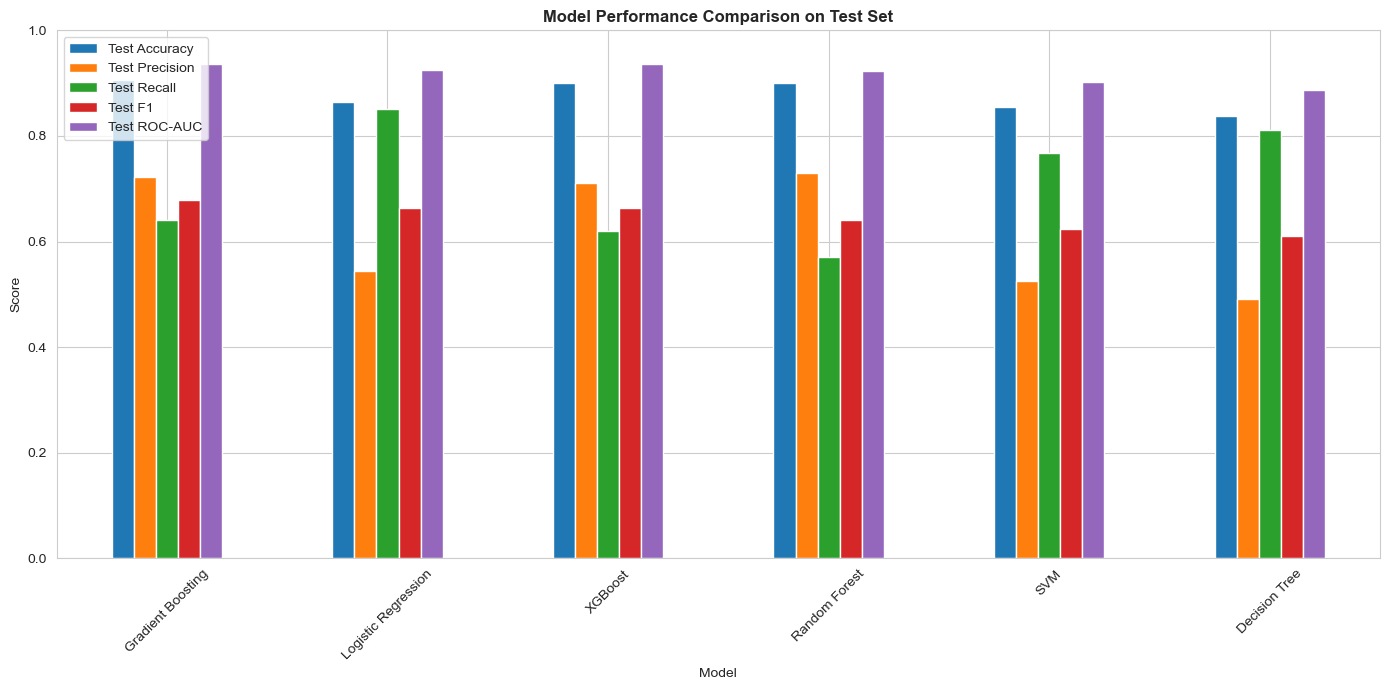

In [104]:
# ============================================================
# TEST METRICS COMPARISON
# ============================================================

metrics_to_plot = [
    "Test Accuracy",
    "Test Precision",
    "Test Recall",
    "Test F1",
    "Test ROC-AUC"
]

comparison_plot = results_df.set_index("Model")[metrics_to_plot]

comparison_plot.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Model Performance Comparison on Test Set")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [105]:
# ============================================================
# SELECT BEST MODEL
# ============================================================

best_model_name = results_df.loc[0, "Model"]

print("Best Model:", best_model_name)
print("Best Test F1:", results_df.loc[0, "Test F1"])
print("Best Test ROC-AUC:", results_df.loc[0, "Test ROC-AUC"])

Best Model: Gradient Boosting
Best Test F1: 0.6796116504854369
Best Test ROC-AUC: 0.9363260262059812


In [106]:
# ============================================================
# GET BEST MODEL OBJECT
# ============================================================

model_dict = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "SVM": svm_model,
    "XGBoost": xgb_model,
    "Gradient Boosting": gradient_boosting
}

best_model = model_dict[best_model_name]

print("Selected model:", best_model_name)

Selected model: Gradient Boosting


In [107]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in all_models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ],
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,

        "CV Accuracy":
            scores["test_accuracy"].mean(),

        "CV Precision":
            scores["test_precision"].mean(),

        "CV Recall":
            scores["test_recall"].mean(),

        "CV F1":
            scores["test_f1"].mean(),

        "CV ROC-AUC":
            scores["test_roc_auc"].mean()
    })


cv_df = pd.DataFrame(cv_results)

print("\n5-Fold Cross Validation")
print("=" * 80)

print(
    cv_df
    .sort_values("CV F1", ascending=False)
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


5-Fold Cross Validation
              Model  CV Accuracy  CV Precision  CV Recall  CV F1  CV ROC-AUC
  Gradient Boosting       0.9023        0.7240     0.6059 0.6596      0.9312
            XGBoost       0.9029        0.7308     0.6011 0.6594      0.9336
Logistic Regression       0.8651        0.5465     0.8171 0.6547      0.9198
      Random Forest       0.9000        0.7444     0.5503 0.6326      0.9252
                SVM       0.8578        0.5319     0.7563 0.6243      0.9006
      Decision Tree       0.8460        0.5063     0.7835 0.6145      0.8690


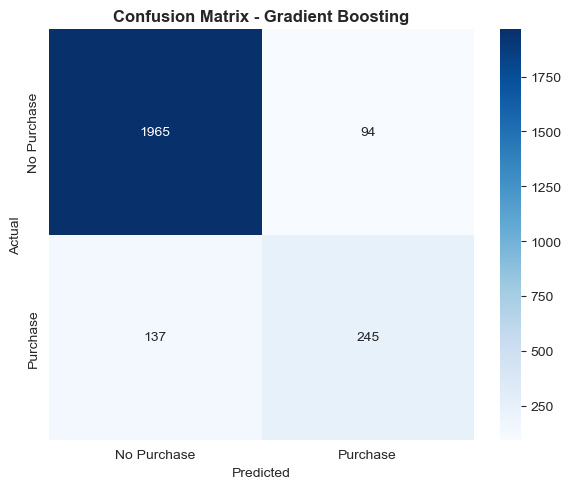

In [108]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

y_test_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_test_pred_best)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

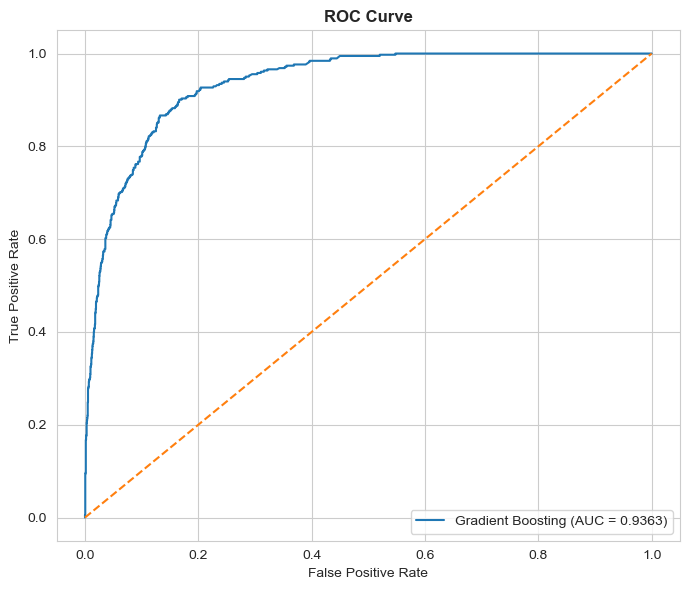

In [109]:
# ============================================================
# ROC CURVE
# ============================================================

from sklearn.metrics import roc_curve

y_test_prob_best = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_test_prob_best
)

roc_auc = roc_auc_score(
    y_test,
    y_test_prob_best
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"{best_model_name} (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

# Persisting the Best Model

Save the winning pipeline (preprocessing + estimator)

In [110]:
# ============================================================
# SAVE BEST MODEL + FEATURE NAMES (portable, relative paths)
# ============================================================
import os
import joblib

MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

best_model_path = os.path.join(MODELS_DIR, "best_model.pkl")
feature_names_path = os.path.join(MODELS_DIR, "feature_names.pkl")

joblib.dump(best_model, best_model_path)
joblib.dump(list(X.columns), feature_names_path)

print(f"Best model ({best_model_name}) saved to: {best_model_path}")
print(f"Feature names saved to: {feature_names_path}")

Best model (Gradient Boosting) saved to: models\best_model.pkl
Feature names saved to: models\feature_names.pkl


# AI Business Insights & Conversational Assistant

This section turns the trained model's output into **business-facing insight**

 For a given session, the assistant explains the prediction, analyzes the session's behavioral signals, and suggests conversion-optimization actions — grounded strictly in:

- the model's actual prediction and purchase probability, and
- the session's real, existing feature values.


## Step 1 — Global Feature Importance

In [111]:
# ============================================================
# GLOBAL FEATURE IMPORTANCE
# Used to explain WHICH behaviors the model relies on most,
# grounding the AI's explanations in the model's real internals
# rather than invented reasoning.
# ============================================================

def get_feature_importance(pipeline, top_n=15):
    """
    Return a DataFrame of the top_n globally most influential features for
    a fitted (preprocessing + model) pipeline. Supports tree-based models
    (feature_importances_) and linear models (coef_). Returns None if the
    estimator exposes neither (e.g. a non-linear-kernel SVM).
    """
    try:
        feature_names = pipeline.named_steps["preprocessing"].get_feature_names_out()
    except Exception:
        return None

    estimator = pipeline.named_steps["model"]

    if hasattr(estimator, "feature_importances_"):
        importances = estimator.feature_importances_
    elif hasattr(estimator, "coef_"):
        importances = np.abs(estimator.coef_).ravel()
    else:
        return None

    importance_df = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    return importance_df.head(top_n)


global_feature_importance = get_feature_importance(best_model)

if global_feature_importance is not None:
    print(f"Top globally influential features for: {best_model_name}")
    print(global_feature_importance.to_string(index=False))
else:
    print(f"{best_model_name} does not expose feature_importances_ or coef_.")

Top globally influential features for: Gradient Boosting
                           feature  importance
                   num__PageValues    0.459476
               num__PageValues_Log    0.294453
                    cat__Month_Nov    0.045692
                  num__BounceRates    0.041381
                    num__ExitRates    0.026507
             num__Engagement_Score    0.022559
               num__Administrative    0.021012
               num__Total_Duration    0.013655
                  num__Total_Pages    0.010718
           num__Product_Page_Ratio    0.009765
                    cat__Month_May    0.007877
       num__Product_Duration_Ratio    0.006056
      num__Administrative_Duration    0.004390
cat__VisitorType_Returning_Visitor    0.004094
  num__Administrative_Duration_Log    0.003981


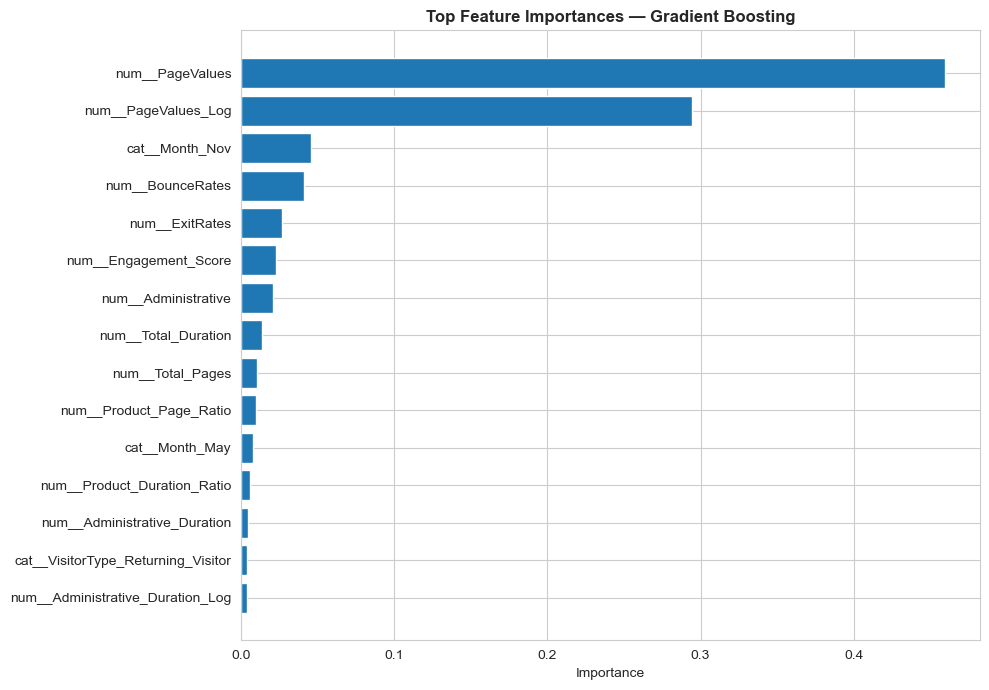

In [112]:
# ============================================================
# PLOT FEATURE IMPORTANCE (if available)
# ============================================================
if global_feature_importance is not None:
    plt.figure(figsize=(10, 7))

    plt.barh(
        global_feature_importance["feature"][::-1],
        global_feature_importance["importance"][::-1]
    )

    plt.title(f"Top Feature Importances — {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

## Step 2 — Build a Grounded Session Context

Every fact passed to the AI assistant comes from this function. It contains only the model's real prediction/probability and the session's real feature values — nothing fabricated.

In [113]:
# ============================================================
# SESSION CONTEXT BUILDER
# The single source of truth for everything the LLM is allowed
# to know about a session. No products, orders, or customer
# history are added because none exist in this dataset.
# ============================================================

def build_session_context(index, X_source, model=best_model, y_source=None):
    """
    Build a grounded context dict for one real session in X_source.

    Parameters
    ----------
    index : int
        Positional index of the session within X_source.
    X_source : pd.DataFrame
        Feature set to pull the session from (e.g. X_test).
    model : fitted sklearn Pipeline
        Used to compute the real purchase probability.
    y_source : pd.Series, optional
        If provided, includes the real ground-truth outcome for comparison.
    """
    session_features = X_source.iloc[[index]]
    probability = float(model.predict_proba(session_features)[0, 1])
    predicted_label = "Purchase" if probability >= 0.5 else "No Purchase"

    context = {
        "session_index": int(index),
        "purchase_probability": probability,
        "predicted_outcome": predicted_label,
        "session_features": session_features.iloc[0].to_dict(),
    }

    if y_source is not None:
        actual = int(y_source.iloc[index])
        context["actual_outcome"] = "Purchase" if actual == 1 else "No Purchase"

    if global_feature_importance is not None:
        context["top_global_features"] = global_feature_importance.to_dict("records")

    return context


# Quick sanity check
sample_context = build_session_context(0, X_test, y_source=y_test)
print("Session context keys:", list(sample_context.keys()))
print("Predicted outcome   :", sample_context["predicted_outcome"])
print("Purchase probability:", f"{sample_context['purchase_probability']:.2%}")

Session context keys: ['session_index', 'purchase_probability', 'predicted_outcome', 'session_features', 'actual_outcome', 'top_global_features']
Predicted outcome   : No Purchase
Purchase probability: 5.36%


## Step 3 — AI Purchase Intelligence Prompt Template

The prompt asks Gemini for a nine-section analysis — prediction summary, explanation, behavior analysis, purchase intent, conversion barriers, marketing insights, conversion opportunities, a prioritized action plan, and a validation recommendation — while explicitly staying grounded in the provided facts and forbidding invented products, recommendations, purchase history, feature-importance numbers, or probability-change guarantees.


In [114]:
# ============================================================
# AI PURCHASE INTELLIGENCE PROMPT TEMPLATE
# Explains the prediction AND produces a grounded, prioritized
# conversion action plan. Every claim must trace back to a fact
# actually present in session_context — no invented products,
# transactions, customer history, feature-importance numbers, or
# probability-change guarantees.
# ============================================================

def create_business_insight_prompt(session_context):
    """
    Build a strictly grounded prompt for the AI Purchase Intelligence
    Assistant. Only facts present in `session_context` may be used, and
    every recommendation in sections 7-8 must trace back to a specific
    signal named earlier in the response.
    """
    features_text = "\n".join(
        f"- {key}: {value}" for key, value in session_context["session_features"].items()
    )

    top_features_text = "Not available for this model type."
    if session_context.get("top_global_features"):
        top_features_text = "\n".join(
            f"- {row['feature']}: importance={row['importance']:.4f}"
            for row in session_context["top_global_features"][:10]
        )

    actual_line = ""
    if session_context.get("actual_outcome"):
        actual_line = f"Actual outcome (ground truth): {session_context['actual_outcome']}\n"

    prompt = f"""You are an AI Purchase Intelligence Assistant embedded in a purchase-intention
prediction dashboard. You analyze ONE real website session, explain the model's
prediction in plain, business-friendly language, and provide a grounded,
prioritized action plan for improving the customer's likelihood of converting.

=== MODEL OUTPUT (real, from the trained classifier) ===
Predicted outcome: {session_context['predicted_outcome']}
Purchase probability: {session_context['purchase_probability']:.2%}
{actual_line}
=== SESSION FEATURES (real, from the dataset — the ONLY facts about this session) ===
{features_text}

=== GLOBALLY IMPORTANT FEATURES FOR THIS MODEL ===
{top_features_text}

Using ONLY the information above, write a structured analysis with EXACTLY
these nine section headers (markdown, numbered):

1. Prediction Summary
   - State the predicted outcome, purchase probability, and actual outcome
     when available.

2. Why This Prediction Happened
   - Explain the strongest evidence from the actual model/session context
     above. Only use evidence actually available in the context.

3. Customer / Session Behavior
   - Analyze browsing behavior, engagement, page activity, duration,
     bounce/exit behavior, visitor type, traffic/source information, and
     any other relevant features — but only ones that actually exist in
     the context above. Do not invent additional information.

4. Purchase Intent Analysis
   - Classify the observed intent as high, moderate, or low purchase
     intent, and explain why using only the session features and
     prediction above.

5. Conversion Barriers
   - For No Purchase or low-probability sessions, identify possible
     barriers based on observed evidence only (e.g. weak conversion-
     oriented behavior, high browsing but low transactional signals,
     high exit behavior, low page value, weak engagement with
     conversion-related pages). Do not use generic barriers unless
     supported by the actual session. If the prediction is Purchase with
     a high probability, say plainly that no significant barriers are
     evident rather than inventing some.

6. Marketing Insights
   - Translate the model evidence into business insights. Clearly
     separate Model-Based Evidence (the prediction, probability, and
     actual feature values above) from Business Interpretation (your
     reasonable reading of what that behavior suggests) — never present
     interpretation as if it were a measured model fact.

7. Conversion Improvement Opportunities
   - Suggest practical actions connected to the actual session evidence:
     e.g. clearer CTA placement, reducing checkout friction, clearer
     product information, stronger trust signals, clearer shipping/
     delivery information, better navigation, targeted assistance,
     relevant incentives, retargeting, improving the transition from
     browsing to conversion. Every suggestion must be connected to the
     actual session evidence, not generic advice.

8. Prioritized Action Plan
   - Group actions into High Priority (directly address the strongest
     observed barriers), Medium Priority (improve engagement or reduce
     friction), and Optional (additional optimization ideas).
   - For each action, use exactly this structure:
     **Action:** <what the business should do>
     **Why:** <the specific observed signal that supports this>
     **Expected Goal:** <what conversion problem this aims to improve>
     **Priority:** High / Medium / Optional
     **Evidence:** <the actual feature/session evidence behind it>
   - Follow this reasoning chain for every action: Observed Evidence ->
     Interpretation -> Conversion Barrier/Opportunity -> Recommended Action.

9. Validation Recommendation
   - Explain how the business should validate the suggested actions:
     A/B testing, conversion-rate monitoring, controlled experiments,
     comparing future model predictions, or funnel metrics. Make clear
     these are recommendations to be validated, not guaranteed outcomes.

Strict rules:
- Do NOT invent, assume, or mention any specific product, product ID,
  product name, order, or purchase history — none exists in the data above.
- Do NOT claim the customer purchased anything unless "Predicted outcome" or
  "Actual outcome" explicitly says so.
- Do NOT claim a recommendation will definitely increase the probability by
  a specific amount (never say something like "this will raise the
  probability from 20% to 70%"). Use wording such as "may improve
  conversion likelihood" or "could reduce this conversion barrier" —
  actual impact must be validated through future predictions or
  experimentation, per section 9.
- If feature importance is not explicitly provided above, do not mention
  specific importance percentages.
- Base every statement strictly on the session features and model output
  given above; do not fabricate additional customer facts, conversion
  statistics, or seasonal/business claims that aren't supported by the
  data shown. Phrase any unsupported-but-plausible claim as a hypothesis
  or opportunity, not a fact.
- Do NOT recommend specific products, product IDs, cross-sell items, or
  reorder suggestions — this assistant analyzes purchase intent and
  business/conversion actions, not product recommendations.
- Write for a marketing/analytics stakeholder, not a data scientist —
  clear, concise, and actionable.
"""
    return prompt


# Preview the prompt for the sample session
print(create_business_insight_prompt(sample_context))


You are an AI Purchase Intelligence Assistant embedded in a purchase-intention
prediction dashboard. You analyze ONE real website session, explain the model's
prediction in plain, business-friendly language, and provide a grounded,
prioritized action plan for improving the customer's likelihood of converting.

=== MODEL OUTPUT (real, from the trained classifier) ===
Predicted outcome: No Purchase
Purchase probability: 5.36%
Actual outcome (ground truth): No Purchase

=== SESSION FEATURES (real, from the dataset — the ONLY facts about this session) ===
- Administrative: 0
- Administrative_Duration: 0.0
- Informational: 0
- Informational_Duration: 0.0
- ProductRelated: 12
- ProductRelated_Duration: 482.5
- BounceRates: 0.02
- ExitRates: 0.04
- PageValues: 0.0
- SpecialDay: 0.0
- Month: Nov
- OperatingSystems: 1
- Browser: 2
- Region: 1
- TrafficType: 10
- VisitorType: Returning_Visitor
- Weekend: False
- Total_Pages: 12
- Total_Duration: 482.5
- Product_Page_Ratio: 0.9230769230769231
- P

## Step 4 — Gemini API Setup

The API key is **never hard-coded**. It is read from an environment variable (works locally and on most deployment platforms) with a Google Colab secrets fallback, so the same cell works unmodified in both environments.

In [117]:
!pip install -q "google-auth==2.49.0"

In [119]:
def get_gemini_api_key():
    """
    Resolve the Gemini API key, in order:
      1. Environment variable GEMINI_API_KEY (local runs, servers, CI/CD).
      2. Google Colab secrets (Tools > Secrets > GEMINI_API_KEY), if running
         inside Colab.
      3. An interactive, hidden prompt as a last-resort fallback so the
         notebook still runs standalone if neither of the above is set.
    """
    api_key = os.environ.get("GEMINI_API_KEY")
    if api_key:
        return api_key

    try:
        from google.colab import userdata  # only importable inside Colab
        api_key = userdata.get("GEMINI_API_KEY")
        if api_key:
            return api_key
    except Exception:
        pass

    from getpass import getpass
    print("GEMINI_API_KEY not found in environment variables or Colab secrets.")
    return getpass("Enter your Gemini API key (input hidden): ")


GEMINI_API_KEY = get_gemini_api_key()
client = genai.Client(api_key=GEMINI_API_KEY)
GEMINI_MODEL = os.environ.get("GEMINI_MODEL", "gemini-2.5-flash")  # matches the Streamlit app's default

print("Gemini client initialized." if GEMINI_API_KEY else "WARNING: no API key provided.")

GEMINI_API_KEY not found in environment variables or Colab secrets.
Gemini client initialized.


## Step 5 — AI Insight Generation Function

In [120]:
# ============================================================
# SINGLE, CANONICAL LLM CALL FUNCTION
# ============================================================

import time
from google.genai.errors import ClientError


def generate_ai_insight(prompt, model_name=None, max_output_tokens=3000, max_retries=2):
    """
    Send a prompt to the Gemini API and return the text response.

    Disables "thinking" (thinking_budget=0): Gemini 2.5 models spend part
    of max_output_tokens on invisible reasoning tokens before writing the
    visible answer, which can silently truncate a long, multi-section
    instruction-following prompt like the purchase-insight report before
    it finishes. Disabling thinking reserves the full token budget for
    the visible response.

    Retries once or twice on 429 RESOURCE_EXHAUSTED (a transient
    per-minute rate limit), waiting the delay Google suggests in the
    error. If the quota is actually exhausted for the day (not just a
    momentary rate spike), retrying won't help — the error is re-raised
    with a clear message after `max_retries` attempts instead of hanging
    or retrying forever.
    """
    if not GEMINI_API_KEY:
        raise RuntimeError(
            "Gemini API key not configured — set the GEMINI_API_KEY "
            "environment variable before calling this function."
        )

    config = types.GenerateContentConfig(
        max_output_tokens=max_output_tokens,
        thinking_config=types.ThinkingConfig(thinking_budget=0),
    )

    attempt = 0
    while True:
        try:
            response = client.models.generate_content(
                model=model_name or GEMINI_MODEL,
                contents=prompt,
                config=config,
            )
            break
        except ClientError as exc:
            is_rate_limit = getattr(exc, "code", None) == 429
            if not is_rate_limit or attempt >= max_retries:
                if is_rate_limit:
                    raise RuntimeError(
                        "Gemini API quota exceeded and retries were exhausted. "
                        "This is usually a free-tier daily request cap (see the "
                        "original error for the exact limit) — wait for it to reset, "
                        "reduce how often you re-run generation cells, or enable "
                        "billing on the project for higher limits."
                    ) from exc
                raise
            wait_seconds = 15 * (attempt + 1)  # simple backoff; good enough for a notebook
            print(f"Rate limited (attempt {attempt + 1}/{max_retries}) — waiting {wait_seconds}s before retrying...")
            time.sleep(wait_seconds)
            attempt += 1

    text = (response.text or "").strip()
    if not text:
        return "*(The assistant returned an empty response.)*"

    try:
        finish_reason = response.candidates[0].finish_reason
    except (AttributeError, IndexError):
        finish_reason = None

    if finish_reason is not None and str(finish_reason).endswith("MAX_TOKENS"):
        text += (
            "\n\n---\n_This response was cut off by the output token limit before it "
            "finished. Try again, or increase `max_output_tokens`._"
        )

    return text


## Step 6 — Full Pipeline: Prediction → Context → AI Business Insight

In [121]:
# ============================================================
# COMPLETE PIPELINE: ML PREDICTION -> GROUNDED CONTEXT -> AI INSIGHT
# ============================================================

def generate_purchase_insight(index, X_source, y_source=None, model=best_model):
    """
    End-to-end: real prediction -> grounded session context -> AI business
    insight. Returns both the raw model output and the AI-generated
    analysis so the UI can display them separately.
    """
    context = build_session_context(index, X_source, model=model, y_source=y_source)
    prompt = create_business_insight_prompt(context)
    ai_insight = generate_ai_insight(prompt)

    return {
        "session_index": context["session_index"],
        "purchase_probability": context["purchase_probability"],
        "predicted_outcome": context["predicted_outcome"],
        "actual_outcome": context.get("actual_outcome"),
        "session_context": context,
        "ai_insight": ai_insight,
    }

### Demo — Generate an AI Business Insight for a Real Test Session

In [122]:
GEMINI_MODEL = os.environ.get("GEMINI_MODEL", "gemini-3.6-flash")
# ============================================================
# DEMO
# ============================================================
sample_index = 0

insight_result = generate_purchase_insight(sample_index, X_test, y_source=y_test)

print("=" * 70)
print("AI PURCHASE INSIGHT REPORT")
print("=" * 70)
print(f"\nSession Index        : {insight_result['session_index']}")
print(f"Purchase Probability : {insight_result['purchase_probability']:.2%}")
print(f"Predicted Outcome    : {insight_result['predicted_outcome']}")
if insight_result["actual_outcome"] is not None:
    print(f"Actual Outcome       : {insight_result['actual_outcome']}")
print()
print(insight_result["ai_insight"])

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


AI PURCHASE INSIGHT REPORT

Session Index        : 0
Purchase Probability : 5.36%
Predicted Outcome    : No Purchase
Actual Outcome       : No Purchase

### 1. Prediction Summary

* **Predicted Outcome:** No Purchase
* **Purchase Probability:** 5.36%
* **Actual Outcome:** No Purchase

---

### 2. Why This Prediction Happened

The low purchase probability (5.36%) driven by the model is heavily influenced by the globally dominant features and specific session characteristics:

* **Zero Page Value (`PageValues` = 0.0, `PageValues_Log` = 0.0):** The model relies heavily on `PageValues` (global importance = 0.4595) and `PageValues_Log` (global importance = 0.2945). A value of 0.0 indicates that the user did not visit any pages directly associated with prior conversion or revenue completion before this prediction point.
* **Month of Session (`Month` = Nov):** The session occurred in November (`Month_Nov` global importance = 0.0457). While November is a major shopping month globally, within t

## Step 7 — Conversational Follow-Up Assistant

Lets a business user ask free-form follow-up questions about a specific session's prediction. Every turn stays grounded in the same session context — the assistant is instructed to say a fact isn't available rather than invent one (e.g. about a specific product).

In [123]:
# ============================================================
# CONVERSATIONAL FOLLOW-UP ASSISTANT
# ============================================================

def ask_insight_assistant(session_context, conversation_history, user_question):
    """
    Continue a conversation about a specific session's prediction.

    Parameters
    ----------
    session_context : dict
        Output of build_session_context() — the grounding facts.
    conversation_history : list[dict]
        Running list of {"role": "user"/"model", "text": str} turns.
        Mutated in place with the new question + answer.
    user_question : str
        The stakeholder's free-form question.
    """
    history_text = "\n".join(
        f"{turn['role'].upper()}: {turn['text']}" for turn in conversation_history
    ) or "(this is the first question)"

    grounding = create_business_insight_prompt(session_context)

    prompt = f"""{grounding}

=== CONVERSATION SO FAR ===
{history_text}

=== NEW USER QUESTION ===
{user_question}

Answer the user's question conversationally in a few sentences, staying
strictly grounded in the session features and model output above. If the
question asks about something not covered by the data (e.g. a specific
product or past order), say plainly that this information isn't available
in the current session data rather than inventing an answer.
"""

    reply = generate_ai_insight(prompt)
    conversation_history.append({"role": "user", "text": user_question})
    conversation_history.append({"role": "model", "text": reply})
    return reply

#test

### Demo — Conversational Follow-Up

In [125]:
# ============================================================
# DEMO: multi-turn conversation about the same session
# ============================================================
demo_context = build_session_context(sample_index, X_test, y_source=y_test)
conversation = []

question_1 = "What is the single most important behavioral signal behind this prediction?"
answer_1 = ask_insight_assistant(demo_context, conversation, question_1)
print(f"Q: {question_1}\n\nA: {answer_1}\n")

question_2 = "What is one concrete action the marketing team could take to improve conversion for sessions like this one?"
answer_2 = ask_insight_assistant(demo_context, conversation, question_2)
print(f"Q: {question_2}\n\nA: {answer_2}")

Q: What is the single most important behavioral signal behind this prediction?

A: The single most important behavioral signal behind this prediction is the **PageValues score of 0.0** (log value 0.0). Globally, `PageValues` and `PageValues_Log` are by far the model's top drivers of purchase predictions (accounting for over 75% of global model importance combined), and a zero value strongly signals that the user did not visit any pages prior to exit that historically contribute to a completed transaction. 

While the user engaged significantly with browsing content—spending 482.5 seconds across 12 product-related pages in November—this lack of target page value, combined with zero engagement on administrative or informational pages, led the model to assign a very low purchase probability of **5.36%**.

***

### 1. Prediction Summary
- **Predicted Outcome:** No Purchase
- **Purchase Probability:** 5.36%
- **Actual Outcome:** No Purchase

---

### 2. Why This Prediction Happened
The mode

In [126]:
# Test the SmartCart LLM with a realistic purchase prediction context

test_prompt = """
You are the SmartCart Purchase Intelligence Assistant.

Analyze the following machine learning prediction:

Prediction: Purchase
Purchase probability: 87.4%

Session behavior:
- PageValues: 42.7
- ProductRelated: 35
- ProductRelated_Duration: 1280 seconds
- BounceRates: 0.01
- ExitRates: 0.03
- VisitorType: Returning_Visitor
- Weekend: True
- Month: Nov

Your response must:
1. Explain why the model may have predicted a purchase.
2. Analyze the customer's/session's purchase-intent signals.
3. Give useful marketing insights.
4. Suggest practical conversion optimization actions.
5. Do NOT invent products, product names, orders, purchase history, or recommendations.
6. Clearly distinguish between model-based evidence and business interpretation.

Keep the answer concise and business-oriented.
"""

response = generate_ai_insight(test_prompt)

print(response)

### 1. Model Prediction Analysis
* **Prediction:** Purchase
* **Model Confidence:** High (87.4% probability)

**Model-Based Evidence:**
The primary feature driving this high-probability prediction is the **PageValues of 42.7**. In e-commerce intent models, a high PageValue indicates that the pages visited during this session frequently precede a completed transaction. Secondary contributing factors include a low **ExitRate (0.03)**, minimal **BounceRate (0.01)**, and substantial engagement (**35 ProductRelated pages** over **1,280 seconds**). The classification as a **Returning_Visitor** during a peak shopping period (**Nov**) further increases the baseline probability of conversion.

---

### 2. Purchase-Intent Signals
* **High Commercial Page Utility:** A PageValue of 42.7 shows the user is interacting with high-intent content (e.g., checkout pages, specific cart-addition flows, or high-converting product detail pages).
* **Deep Engagement:** Spending ~21.3 minutes (1,280 seconds) ac

In [127]:
result = generate_purchase_insight(
    index=0,
    X_source=X_test,
    y_source=y_test
)

print("Prediction:", result["predicted_outcome"])
print("Probability:", result["purchase_probability"])
print("Actual:", result["actual_outcome"])
print("\n--- AI INSIGHT ---\n")
print(result["ai_insight"])

Prediction: No Purchase
Probability: 0.05360419936458832
Actual: No Purchase

--- AI INSIGHT ---

### 1. Prediction Summary

* **Predicted Outcome:** No Purchase
* **Purchase Probability:** 5.36%
* **Actual Outcome:** No Purchase

---

### 2. Why This Prediction Happened

The model's strong prediction of **No Purchase** (5.36% likelihood) is driven primarily by the lack of high-value monetary signals combined with high browsing duration without administrative action:

* **Zero Page Value (`PageValues` = 0.0, `PageValues_Log` = 0.0):** Globally, `PageValues` and its log transformation account for over 75% of the model's feature importance (0.4595 and 0.2945, respectively). In this session, the user visited zero pages that held historical transactional value, which is the strongest indicator of a non-converting session.
* **Lack of Administrative/Informational Progress (`Administrative` = 0, `Informational` = 0):** The user interacted exclusively with product-related pages, entirely bypa